# Activity 1. ETL - Metro CDMX

Carga y análisis general de la base de afluencia del Metro CDMX.

## 1. Cargar la base de datos

El archivo encontrado en esta carpeta se llama `afluenciastc_desglosado_06_2026.csv`. También se deja como candidato el nombre mencionado originalmente por si después agregas ese archivo al proyecto.

In [177]:
from pathlib import Path

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

candidatos_csv = [
    Path('afluenciasrc_desglosado_06_08_2026.csv'),
    Path('afluenciastc_desglosado_06_2026.csv'),
]

ruta_csv = next((ruta for ruta in candidatos_csv if ruta.exists()), None)

if ruta_csv is None:
    raise FileNotFoundError(
        'No se encontró el CSV esperado. Revisa que esté en la misma carpeta del notebook.'
    )

df = pd.read_csv(ruta_csv)

print(f'Archivo cargado: {ruta_csv}')
print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]:,}')
df.head()

Archivo cargado: afluenciastc_desglosado_06_2026.csv
Filas: 1,174,095
Columnas: 7


,fecha,mes,anio,linea,estacion,tipo_pago,afluencia
0,2021-01-01,Enero,2021,LÃ­nea 1,Balbuena,Boleto,1848
1,2021-01-01,Enero,2021,LÃ­nea 1,Balbuena,Prepago,790
2,2021-01-01,Enero,2021,LÃ­nea 1,Balbuena,Gratuidad,325
3,2021-01-01,Enero,2021,LÃ­nea 1,Balderas,Boleto,1103
4,2021-01-01,Enero,2021,LÃ­nea 1,Balderas,Prepago,922


## 2. Revisión general

Se revisan duplicados exactos, datos nulos, tipos de datos y una descripción rápida de las columnas numéricas.

In [178]:
resumen_general = pd.DataFrame({
    'tipo_dato': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'nulos_%': (df.isna().mean() * 100).round(2),
    'valores_unicos': df.nunique(dropna=True),
})

duplicados_exactos = df.duplicated().sum()

print(f'Duplicados exactos: {duplicados_exactos:,}')
resumen_general

Duplicados exactos: 0


,tipo_dato,nulos,nulos_%,valores_unicos
fecha,object,0,0.0,2007
mes,object,0,0.0,12
anio,int64,0,0.0,6
linea,object,0,0.0,24
estacion,object,0,0.0,168
tipo_pago,object,0,0.0,3
afluencia,int64,0,0.0,47239


In [179]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha,1174095,2007,2021-01-01,585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mes,1174095,12,Enero,108810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anio,1174095.0,NaN,NaN,NaN,2023.271051,1.599164,2021.0,2022.0,2023.0,2025.0,2026.0
linea,1174095,24,Linea 2,81072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estacion,1174095,168,PantitlÃ¡n,24084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_pago,1174095,3,Boleto,391365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
afluencia,1174095.0,NaN,NaN,NaN,5093.031054,8680.769342,0.0,22.0,2052.0,6009.0,119577.0


## 3. Formatos de columnas

`fecha` viene como texto al leer el CSV, por eso conviene convertirla a tipo fecha. También se verifica que `afluencia` sea numérica.

In [180]:
df_limpio = df.copy()

df_limpio['fecha'] = pd.to_datetime(df_limpio['fecha'], errors='coerce')
df_limpio['afluencia'] = pd.to_numeric(df_limpio['afluencia'], errors='coerce')

print('Tipos después de convertir fecha y afluencia:')
display(df_limpio.dtypes)

print('Fechas inválidas después de convertir:', df_limpio['fecha'].isna().sum())
print('Afluencias inválidas después de convertir:', df_limpio['afluencia'].isna().sum())
print('Rango de fechas:', df_limpio['fecha'].min(), 'a', df_limpio['fecha'].max())

Tipos después de convertir fecha y afluencia:


fecha        datetime64[ns]
mes                  object
anio                  int64
linea                object
estacion             object
tipo_pago            object
afluencia             int64
dtype: object

Fechas inválidas después de convertir: 0
Afluencias inválidas después de convertir: 0
Rango de fechas: 2021-01-01 00:00:00 a 2026-06-30 00:00:00


## 4. Valores raros por acentos

La columna `linea` trae valores con problemas de codificación, por ejemplo `LĂ­nea 1`, y también versiones sin acento como `Linea 1`. Primero se detectan esos casos y luego se normalizan.

In [181]:
columnas_texto = df_limpio.select_dtypes(include='object').columns
patron_texto_raro = r'[\u00c3\u00c2\u0102\ufffd]'

reporte_texto_raro = []

for columna in columnas_texto:
    mascara = df_limpio[columna].astype(str).str.contains(patron_texto_raro, regex=True, na=False)
    reporte_texto_raro.append({
        'columna': columna,
        'filas_con_texto_raro': int(mascara.sum()),
        'ejemplos': sorted(df_limpio.loc[mascara, columna].dropna().unique())[:10],
    })

pd.DataFrame(reporte_texto_raro)

,columna,filas_con_texto_raro,ejemplos
0,mes,0,[]
1,linea,515385,"[LÃ­nea 1, LÃ­nea 12, LÃ­nea 2, LÃ­nea 3, LÃ­n..."
2,estacion,372657,"[AgrÃ­cola Oriental, Aquiles SerdÃ¡n, AragÃ³n,..."
3,tipo_pago,0,[]


In [182]:
print('Valores originales en linea:')
display(pd.Series(sorted(df_limpio['linea'].dropna().unique()), name='linea_original'))

print('Conteo original por linea:')
df_limpio['linea'].value_counts().sort_index()

Valores originales en linea:


0       Linea 1
1      Linea 12
2       Linea 2
3       Linea 3
4       Linea 4
5       Linea 5
6       Linea 6
7       Linea 7
8       Linea 8
9       Linea 9
10      Linea A
11      Linea B
12     LÃ­nea 1
13    LÃ­nea 12
14     LÃ­nea 2
15     LÃ­nea 3
16     LÃ­nea 4
17     LÃ­nea 5
18     LÃ­nea 6
19     LÃ­nea 7
20     LÃ­nea 8
21     LÃ­nea 9
22     LÃ­nea A
23     LÃ­nea B
Name: linea_original, dtype: object

Conteo original por linea:


linea
Linea 1      67560
Linea 12     67560
Linea 2      81072
Linea 3      70938
Linea 4      33780
Linea 5      43914
Linea 6      37158
Linea 7      47292
Linea 8      64182
Linea 9      40536
Linea A      33780
Linea B      70938
LÃ­nea 1     52860
LÃ­nea 12    52860
LÃ­nea 2     63432
LÃ­nea 3     55503
LÃ­nea 4     26430
LÃ­nea 5     34359
LÃ­nea 6     29073
LÃ­nea 7     37002
LÃ­nea 8     50217
LÃ­nea 9     31716
LÃ­nea A     26430
LÃ­nea B     55503
Name: count, dtype: int64

## 5. Limpieza básica de texto

Esta función intenta corregir texto mal decodificado y después unifica `Linea` con `Línea` para que cada línea del Metro quede con un solo nombre.

In [183]:
def corregir_mojibake(valor):
    if not isinstance(valor, str):
        return valor

    texto = valor
    for _ in range(3):
        try:
            corregido = texto.encode('latin1').decode('utf-8')
        except UnicodeError:
            break

        if corregido == texto:
            break
        texto = corregido

    return texto

for columna in columnas_texto:
    df_limpio[columna] = df_limpio[columna].map(corregir_mojibake)

df_limpio['linea'] = df_limpio['linea'].str.replace(r'^Linea', 'L\u00ednea', regex=True)

homologacion_estaciones = {
    'G\u00f3mez Farias': 'G\u00f3mez Far\u00edas',
    'Pe\u00f1\u00f3n viejo': 'Pe\u00f1\u00f3n Viejo',
}

df_limpio['estacion'] = df_limpio['estacion'].replace(homologacion_estaciones)

print('Valores limpios en linea:')
display(pd.Series(sorted(df_limpio['linea'].dropna().unique()), name='linea_limpia'))

print('Estaciones homologadas:')
display(homologacion_estaciones)

print('Duplicados después de limpieza:', df_limpio.duplicated().sum())
print('Nulos después de limpieza:')
display(df_limpio.isna().sum())

Valores limpios en linea:


0      Línea 1
1     Línea 12
2      Línea 2
3      Línea 3
4      Línea 4
5      Línea 5
6      Línea 6
7      Línea 7
8      Línea 8
9      Línea 9
10     Línea A
11     Línea B
Name: linea_limpia, dtype: object

Estaciones homologadas:


{'Gómez Farias': 'Gómez Farías', 'Peñón viejo': 'Peñón Viejo'}

Duplicados después de limpieza: 0
Nulos después de limpieza:


fecha        0
mes          0
anio         0
linea        0
estacion     0
tipo_pago    0
afluencia    0
dtype: int64

## 6. Breve análisis general

Con la base revisada localmente:

- La base tiene **1,174,095 filas** y **7 columnas**.
- No se encontraron **duplicados exactos**.
- No se encontraron **datos nulos** en las columnas originales.
- `fecha` debe convertirse de texto a fecha; `anio` y `afluencia` ya se leen como enteros.
- `linea` tiene valores duplicados conceptualmente por codificación y acentos: aparecen versiones como `Linea 1`, `LĂ­nea 1` y, después de limpiar, deben quedar como `Línea 1`.
- La base cubre fechas de **2021-01-01** a **2026-06-30**.
- `tipo_pago` tiene tres categorías: `Boleto`, `Prepago` y `Gratuidad`.

In [184]:
afluencia_por_linea = (
    df_limpio.groupby('linea', as_index=False)['afluencia']
    .sum()
    .sort_values('afluencia', ascending=False)
)

afluencia_por_linea

,linea,afluencia
2,Línea 2,1010415832
3,Línea 3,874393188
11,Línea B,651346177
8,Línea 8,626929496
0,Línea 1,567957743
9,Línea 9,464468892
7,Línea 7,414983183
10,Línea A,391443350
1,Línea 12,351126802
5,Línea 5,303703904


## 7. Revisión de cambios en nombres de estaciones

Una forma sencilla de revisar si cambiaron nombres de estaciones es comparar el catálogo de estaciones de cada línea a través del tiempo. Si una línea tiene siempre las mismas estaciones, entonces el catálogo debería repetirse en cada periodo.

Aquí lo revisamos de dos formas:

- Conteo de estaciones por `linea` y `anio`.
- Comparación exacta del conjunto de estaciones por `linea` y `anio` contra el catálogo completo observado para esa línea.

In [185]:
conteo_estaciones_anio = (
    df_limpio.groupby(['linea', 'anio'])['estacion']
    .nunique()
    .reset_index(name='n_estaciones')
)

conteo_estaciones_anio.head(20)

,linea,anio,n_estaciones
0,Línea 1,2021,20
1,Línea 1,2022,20
2,Línea 1,2023,20
3,Línea 1,2024,20
4,Línea 1,2025,20
5,Línea 1,2026,20
6,Línea 12,2021,20
7,Línea 12,2022,20
8,Línea 12,2023,20
9,Línea 12,2024,20


In [186]:
variacion_estaciones_anio = (
    conteo_estaciones_anio.groupby('linea')['n_estaciones']
    .agg(
        min_estaciones='min',
        max_estaciones='max',
        valores_distintos='nunique',
    )
    .reset_index()
)

lineas_con_cambio_conteo = variacion_estaciones_anio[
    variacion_estaciones_anio['valores_distintos'] > 1
]

print(f'Líneas con cambio en número de estaciones por año: {len(lineas_con_cambio_conteo)}')
lineas_con_cambio_conteo

Líneas con cambio en número de estaciones por año: 0


,linea,min_estaciones,max_estaciones,valores_distintos


El conteo ayuda, pero no es suficiente: podría haber cambiado un nombre y seguir existiendo el mismo número de estaciones. Por eso también comparamos el conjunto exacto de nombres.

In [187]:
catalogo_estaciones_linea = (
    df_limpio.groupby('linea')['estacion']
    .agg(lambda valores: set(valores.dropna()))
)

reporte_cambios_estaciones = []

for (linea, anio), datos_periodo in df_limpio.groupby(['linea', 'anio']):
    estaciones_catalogo = catalogo_estaciones_linea.loc[linea]
    estaciones_periodo = set(datos_periodo['estacion'].dropna())

    faltantes = sorted(estaciones_catalogo - estaciones_periodo)
    adicionales = sorted(estaciones_periodo - estaciones_catalogo)

    if faltantes or adicionales:
        reporte_cambios_estaciones.append({
            'linea': linea,
            'anio': anio,
            'n_faltantes_vs_catalogo': len(faltantes),
            'faltantes_vs_catalogo': faltantes,
            'n_adicionales_vs_catalogo': len(adicionales),
            'adicionales_vs_catalogo': adicionales,
        })

reporte_cambios_estaciones = pd.DataFrame(reporte_cambios_estaciones)

print(f'Periodos con diferencias en el catálogo de estaciones: {len(reporte_cambios_estaciones)}')
reporte_cambios_estaciones

Periodos con diferencias en el catálogo de estaciones: 0


""


También podemos hacer la misma revisión por mes. Esto es más estricto porque detecta si alguna estación desaparece temporalmente del registro mensual.

In [188]:
df_limpio['periodo_mes'] = df_limpio['fecha'].dt.to_period('M').astype(str)

conteo_estaciones_mes = (
    df_limpio.groupby(['linea', 'periodo_mes'])['estacion']
    .nunique()
    .reset_index(name='n_estaciones')
)

variacion_estaciones_mes = (
    conteo_estaciones_mes.groupby('linea')['n_estaciones']
    .agg(
        min_estaciones='min',
        max_estaciones='max',
        valores_distintos='nunique',
    )
    .reset_index()
)

lineas_con_cambio_mensual = variacion_estaciones_mes[
    variacion_estaciones_mes['valores_distintos'] > 1
]

print(f'Líneas con cambio en número de estaciones por mes: {len(lineas_con_cambio_mensual)}')
lineas_con_cambio_mensual

Líneas con cambio en número de estaciones por mes: 0


,linea,min_estaciones,max_estaciones,valores_distintos


Ahora revisamos variantes de nombres. Para esto normalizamos temporalmente los nombres quitando acentos y pasando todo a minúsculas. Si dos nombres diferentes quedan iguales al normalizarse, probablemente son la misma estación escrita de dos maneras distintas.

In [189]:
import unicodedata

def normalizar_texto_comparacion(texto):
    if not isinstance(texto, str):
        return texto

    texto = texto.strip().lower()
    texto = ''.join(
        caracter
        for caracter in unicodedata.normalize('NFD', texto)
        if unicodedata.category(caracter) != 'Mn'
    )
    return ' '.join(texto.split())

variantes_estacion = df_limpio.copy()
variantes_estacion['estacion_normalizada'] = variantes_estacion['estacion'].map(normalizar_texto_comparacion)

posibles_cambios_nombre = (
    variantes_estacion.groupby(['linea', 'estacion_normalizada'])['estacion']
    .agg(lambda valores: sorted(set(valores.dropna())))
    .reset_index(name='variantes_nombre')
)

posibles_cambios_nombre['n_variantes'] = posibles_cambios_nombre['variantes_nombre'].str.len()
posibles_cambios_nombre = posibles_cambios_nombre[
    posibles_cambios_nombre['n_variantes'] > 1
].sort_values(['linea', 'estacion_normalizada'])

posibles_cambios_nombre

,linea,estacion_normalizada,variantes_nombre,n_variantes


**Conclusión de esta revisión:** las variantes `Gómez Farias` / `Gómez Farías` y `Peñón viejo` / `Peñón Viejo` ya fueron homologadas en `df_limpio`. Si la tabla anterior queda vacía, significa que ya no hay nombres de estaciones equivalentes escritos de dos formas distintas.

## 8. Llave primaria natural

La **llave primaria natural** es la combinación de columnas que debería identificar de forma única cada fila por el significado real de la tabla, sin crear un ID artificial.

En esta base, cada fila representa la afluencia de una combinación específica de:

- `fecha`
- `linea`
- `estacion`
- `tipo_pago`

Por eso, la llave natural propuesta es `fecha + linea + estacion + tipo_pago`. Si esa llave se cumple, no debería haber dos filas con la misma fecha, línea, estación y tipo de pago.

In [190]:
llave_natural = ['fecha', 'linea', 'estacion', 'tipo_pago']

duplicados_llave_natural = df_limpio.duplicated(subset=llave_natural).sum()

resumen_llave_natural = pd.DataFrame({
    'llave_natural': [' + '.join(llave_natural)],
    'filas_totales': [len(df_limpio)],
    'combinaciones_unicas': [df_limpio[llave_natural].drop_duplicates().shape[0]],
    'duplicados_por_llave': [duplicados_llave_natural],
})

resumen_llave_natural

,llave_natural,filas_totales,combinaciones_unicas,duplicados_por_llave
0,fecha + linea + estacion + tipo_pago,1174095,1174095,0


In [191]:
if duplicados_llave_natural > 0:
    display(
        df_limpio[df_limpio.duplicated(subset=llave_natural, keep=False)]
        .sort_values(llave_natural)
        .head(20)
    )
else:
    print('La llave natural se cumple: no hay filas repetidas para fecha + linea + estacion + tipo_pago.')

La llave natural se cumple: no hay filas repetidas para fecha + linea + estacion + tipo_pago.


## 9. Análisis de valores cero en `afluencia`

La base no tiene nulos, pero sí tiene muchos registros con `afluencia = 0`. No todos los ceros significan lo mismo. En esta sección vamos a revisar en qué líneas aparecen, graficarlos y separar dos casos importantes:

- **Cero total por estación-día:** la suma de `Boleto`, `Prepago` y `Gratuidad` es 0. Esto puede indicar cierre, suspensión, ausencia de operación o medición no comparable.
- **Cero parcial por tipo de pago:** una forma de pago está en 0, pero la estación sí tuvo afluencia total positiva ese día. Esto parece más relacionado con el producto de pago que con cierre de la estación.

In [192]:
import matplotlib.pyplot as plt

df_ceros = df_limpio.copy()
df_ceros['es_cero'] = df_ceros['afluencia'].eq(0)
df_ceros['periodo_mes'] = df_ceros['fecha'].dt.to_period('M').astype(str)

resumen_ceros_linea = (
    df_ceros.groupby('linea')
    .agg(
        registros=('afluencia', 'size'),
        ceros=('es_cero', 'sum'),
        total_afluencia=('afluencia', 'sum'),
    )
    .reset_index()
)

resumen_ceros_linea['pct_ceros'] = (
    resumen_ceros_linea['ceros'] / resumen_ceros_linea['registros'] * 100
).round(2)

print(f"Total de registros con afluencia 0: {df_ceros['es_cero'].sum():,}")
print(f"Porcentaje total de ceros: {df_ceros['es_cero'].mean() * 100:.2f}%")

resumen_ceros_linea.sort_values('ceros', ascending=False)

Total de registros con afluencia 0: 285,412
Porcentaje total de ceros: 24.31%


,linea,registros,ceros,total_afluencia,pct_ceros
1,Línea 12,120420,71474,351126802,59.35
0,Línea 1,120420,49519,567957743,41.12
2,Línea 2,144504,27287,1010415832,18.88
3,Línea 3,126441,21389,874393188,16.92
11,Línea B,126441,20767,651346177,16.42
8,Línea 8,114399,18887,626929496,16.51
7,Línea 7,84294,16516,414983183,19.59
9,Línea 9,72252,14033,464468892,19.42
5,Línea 5,78273,13356,303703904,17.06
6,Línea 6,66231,11691,195239321,17.65


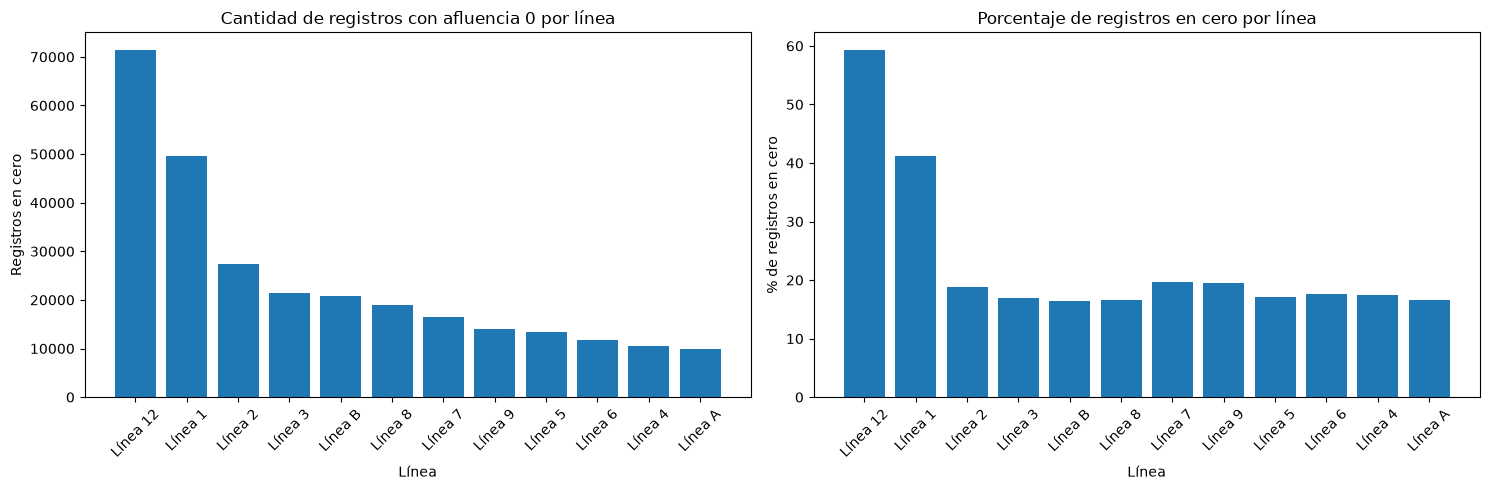

In [193]:
resumen_ceros_grafica = resumen_ceros_linea.sort_values('ceros', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(resumen_ceros_grafica['linea'], resumen_ceros_grafica['ceros'])
axes[0].set_title('Cantidad de registros con afluencia 0 por línea')
axes[0].set_xlabel('Línea')
axes[0].set_ylabel('Registros en cero')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(resumen_ceros_grafica['linea'], resumen_ceros_grafica['pct_ceros'])
axes[1].set_title('Porcentaje de registros en cero por línea')
axes[1].set_xlabel('Línea')
axes[1].set_ylabel('% de registros en cero')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Ahora se separa el problema por `tipo_pago`, porque muchos ceros pueden venir de un producto de pago que ya no se usa o que no aplica igual en todos los periodos.

In [194]:
resumen_ceros_linea_pago = (
    df_ceros.groupby(['linea', 'tipo_pago'])
    .agg(
        registros=('afluencia', 'size'),
        ceros=('es_cero', 'sum'),
    )
    .reset_index()
)

resumen_ceros_linea_pago['pct_ceros'] = (
    resumen_ceros_linea_pago['ceros'] / resumen_ceros_linea_pago['registros'] * 100
).round(2)

resumen_ceros_linea_pago.sort_values('ceros', ascending=False).head(20)

,linea,tipo_pago,registros,ceros,pct_ceros
3,Línea 12,Boleto,40140,40140,100.00
0,Línea 1,Boleto,40140,26332,65.60
6,Línea 2,Boleto,48168,24602,51.08
33,Línea B,Boleto,42147,20627,48.94
9,Línea 3,Boleto,42147,20179,47.88
24,Línea 8,Boleto,38133,18607,48.80
21,Línea 7,Boleto,28098,16069,57.19
4,Línea 12,Gratuidad,40140,15748,39.23
5,Línea 12,Prepago,40140,15586,38.83
15,Línea 5,Boleto,26091,13194,50.57


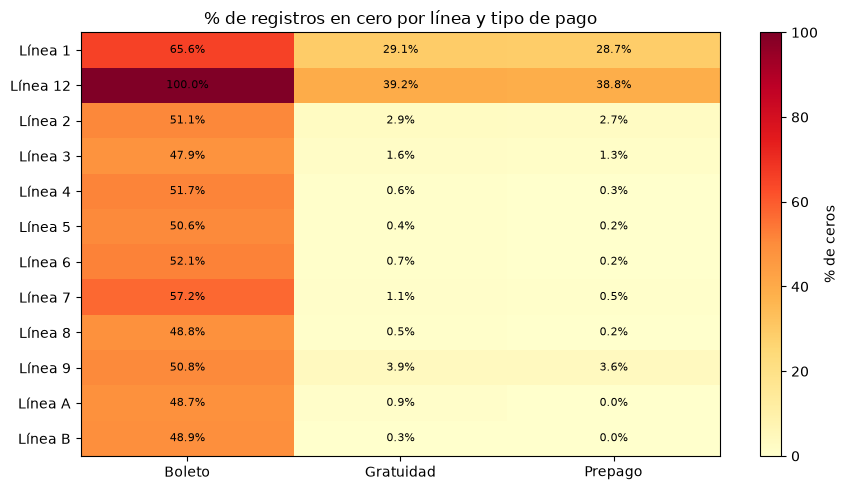

In [195]:
tabla_pct_ceros_pago = resumen_ceros_linea_pago.pivot(
    index='linea', columns='tipo_pago', values='pct_ceros'
).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
imagen = ax.imshow(tabla_pct_ceros_pago, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(tabla_pct_ceros_pago.columns)))
ax.set_xticklabels(tabla_pct_ceros_pago.columns)
ax.set_yticks(range(len(tabla_pct_ceros_pago.index)))
ax.set_yticklabels(tabla_pct_ceros_pago.index)
ax.set_title('% de registros en cero por línea y tipo de pago')

for i, linea in enumerate(tabla_pct_ceros_pago.index):
    for j, tipo_pago in enumerate(tabla_pct_ceros_pago.columns):
        valor = tabla_pct_ceros_pago.loc[linea, tipo_pago]
        ax.text(j, i, f'{valor:.1f}%', ha='center', va='center', fontsize=8)

fig.colorbar(imagen, ax=ax, label='% de ceros')
plt.tight_layout()
plt.show()

Ahora revisamos si el cero fue de toda la estación en ese día o solo de un tipo de pago. Para eso se agrupa por `fecha`, `linea` y `estacion`.

In [196]:
estacion_dia = (
    df_ceros.groupby(['fecha', 'linea', 'estacion'])
    .agg(
        afluencia_total_dia=('afluencia', 'sum'),
        tipos_pago_cero=('es_cero', 'sum'),
        tipos_pago=('tipo_pago', 'nunique'),
    )
    .reset_index()
)

estacion_dia['dia_total_cero'] = estacion_dia['afluencia_total_dia'].eq(0)
estacion_dia['dia_parcial_cero'] = (
    estacion_dia['tipos_pago_cero'].gt(0) & estacion_dia['afluencia_total_dia'].gt(0)
)

resumen_ceros_estacion_dia = (
    estacion_dia.groupby('linea')
    .agg(
        estacion_dias=('fecha', 'size'),
        dias_total_cero=('dia_total_cero', 'sum'),
        dias_parcial_cero=('dia_parcial_cero', 'sum'),
    )
    .reset_index()
)

resumen_ceros_estacion_dia['pct_dias_total_cero'] = (
    resumen_ceros_estacion_dia['dias_total_cero']
    / resumen_ceros_estacion_dia['estacion_dias']
    * 100
).round(2)

resumen_ceros_estacion_dia.sort_values('dias_total_cero', ascending=False)

,linea,estacion_dias,dias_total_cero,dias_parcial_cero,pct_dias_total_cero
1,Línea 12,40140,15570,24570,38.79
0,Línea 1,40140,11381,15231,28.35
2,Línea 2,48168,1178,23639,2.45
9,Línea 9,24084,826,11501,3.43
3,Línea 3,42147,526,19785,1.25
7,Línea 7,28098,141,16064,0.50
5,Línea 5,26091,39,13226,0.15
6,Línea 6,22077,34,11568,0.15
4,Línea 4,20070,32,10433,0.16
11,Línea B,42147,12,20723,0.03


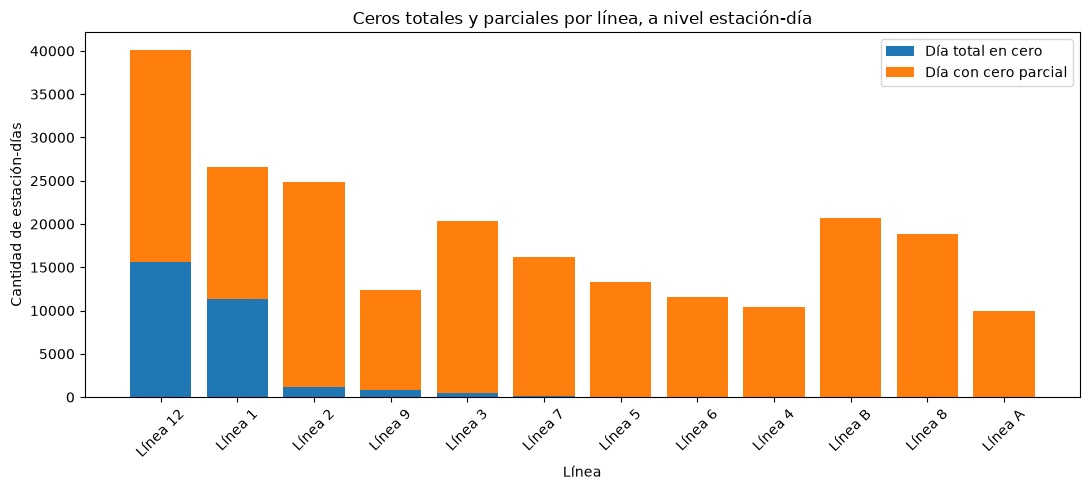

In [197]:
resumen_ceros_estacion_dia_grafica = resumen_ceros_estacion_dia.sort_values(
    'dias_total_cero', ascending=False
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    resumen_ceros_estacion_dia_grafica['linea'],
    resumen_ceros_estacion_dia_grafica['dias_total_cero'],
    label='Día total en cero',
)
ax.bar(
    resumen_ceros_estacion_dia_grafica['linea'],
    resumen_ceros_estacion_dia_grafica['dias_parcial_cero'],
    bottom=resumen_ceros_estacion_dia_grafica['dias_total_cero'],
    label='Día con cero parcial',
)

ax.set_title('Ceros totales y parciales por línea, a nivel estación-día')
ax.set_xlabel('Línea')
ax.set_ylabel('Cantidad de estación-días')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

Primer criterio de tratamiento:

- Si `afluencia_total_dia == 0` para una estación en una fecha, se marca como `cero_total_estacion_dia`. Para modelar afluencia real, ese valor es sospechoso y se crea `afluencia_modelo = NaN`.
- Si la estación tuvo afluencia total positiva, pero un tipo de pago está en 0, se marca como `cero_parcial_tipo_pago` y se conserva como 0, porque parece un cero real del producto de pago.

No borramos filas todavía; solo dejamos banderas para poder comparar después el modelo con y sin estas decisiones.

In [198]:
df_limpio = df_limpio.merge(
    estacion_dia[['fecha', 'linea', 'estacion', 'afluencia_total_dia', 'dia_total_cero']],
    on=['fecha', 'linea', 'estacion'],
    how='left',
)

df_limpio['cero_total_estacion_dia'] = df_limpio['dia_total_cero']
df_limpio['cero_parcial_tipo_pago'] = (
    df_limpio['afluencia'].eq(0) & ~df_limpio['cero_total_estacion_dia']
)

df_limpio['afluencia_modelo'] = df_limpio['afluencia'].mask(
    df_limpio['cero_total_estacion_dia']
)

df_limpio = df_limpio.drop(columns=['dia_total_cero'])

resumen_tratamiento_ceros = pd.DataFrame({
    'registros': [len(df_limpio)],
    'ceros_originales': [df_limpio['afluencia'].eq(0).sum()],
    'registros_marcados_como_nan_para_modelo': [df_limpio['afluencia_modelo'].isna().sum()],
    'ceros_parciales_conservados': [df_limpio['cero_parcial_tipo_pago'].sum()],
})

resumen_tratamiento_ceros

,registros,ceros_originales,registros_marcados_como_nan_para_modelo,ceros_parciales_conservados
0,1174095,285412,89220,196192


**Conclusión preliminar:** los ceros no se concentran principalmente en `Línea A` y `Línea B`. En registros, las líneas con más ceros son `Línea 12` y `Línea 1`. `Línea A` y `Línea B` sí tienen muchos ceros en `Boleto`, pero casi no tienen días donde toda la estación sume cero. Por eso, para el modelo conviene tratar diferente los ceros totales de estación-día y los ceros parciales por tipo de pago.

## 10. Fechas y rachas de ceros totales

Para investigar si estos ceros coinciden con cierres o interrupciones reales, necesitamos listar fechas y detectar rachas consecutivas. Aquí se revisan dos niveles:

- **Línea-día:** qué porcentaje de estaciones de cada línea tuvo afluencia total 0 en cada fecha.
- **Estación-día:** qué estaciones tuvieron afluencia total 0 y por cuántos días seguidos.

In [199]:
linea_dia_ceros = (
    estacion_dia.groupby(['fecha', 'linea'])
    .agg(
        estaciones_registradas=('estacion', 'nunique'),
        estaciones_total_cero=('dia_total_cero', 'sum'),
        afluencia_total_linea=('afluencia_total_dia', 'sum'),
    )
    .reset_index()
)

linea_dia_ceros['pct_estaciones_total_cero'] = (
    linea_dia_ceros['estaciones_total_cero']
    / linea_dia_ceros['estaciones_registradas']
    * 100
).round(2)

linea_dia_ceros['linea_dia_total_cero'] = linea_dia_ceros['afluencia_total_linea'].eq(0)

fechas_linea_total_cero = linea_dia_ceros[
    linea_dia_ceros['linea_dia_total_cero']
].sort_values(['linea', 'fecha'])

print(f'Línea-días donde toda la línea suma 0: {len(fechas_linea_total_cero):,}')
fechas_linea_total_cero.head(30)

Línea-días donde toda la línea suma 0: 699


,fecha,linea,estaciones_registradas,estaciones_total_cero,afluencia_total_linea,pct_estaciones_total_cero,linea_dia_total_cero
96,2021-01-09,Línea 1,20,20,0,100.0,True
108,2021-01-10,Línea 1,20,20,0,100.0,True
120,2021-01-11,Línea 1,20,20,0,100.0,True
132,2021-01-12,Línea 1,20,20,0,100.0,True
144,2021-01-13,Línea 1,20,20,0,100.0,True
156,2021-01-14,Línea 1,20,20,0,100.0,True
168,2021-01-15,Línea 1,20,20,0,100.0,True
180,2021-01-16,Línea 1,20,20,0,100.0,True
192,2021-01-17,Línea 1,20,20,0,100.0,True
204,2021-01-18,Línea 1,20,20,0,100.0,True


In [200]:
dias_mas_afectados = linea_dia_ceros[
    linea_dia_ceros['estaciones_total_cero'] > 0
].sort_values(
    ['pct_estaciones_total_cero', 'estaciones_total_cero'],
    ascending=False,
)

dias_mas_afectados.head(40)

,fecha,linea,estaciones_registradas,estaciones_total_cero,afluencia_total_linea,pct_estaciones_total_cero,linea_dia_total_cero
98,2021-01-09,Línea 2,24,24,0,100.0,True
110,2021-01-10,Línea 2,24,24,0,100.0,True
122,2021-01-11,Línea 2,24,24,0,100.0,True
134,2021-01-12,Línea 2,24,24,0,100.0,True
146,2021-01-13,Línea 2,24,24,0,100.0,True
158,2021-01-14,Línea 2,24,24,0,100.0,True
170,2021-01-15,Línea 2,24,24,0,100.0,True
182,2021-01-16,Línea 2,24,24,0,100.0,True
194,2021-01-17,Línea 2,24,24,0,100.0,True
206,2021-01-18,Línea 2,24,24,0,100.0,True


La tabla anterior ayuda a buscar fechas puntuales. Para encontrar interrupciones largas, detectamos rachas consecutivas de ceros totales por estación.

In [201]:
def detectar_rachas_consecutivas(datos, columnas_grupo, columna_fecha='fecha'):
    datos = datos.sort_values(columnas_grupo + [columna_fecha]).copy()

    datos['nueva_racha'] = (
        datos.groupby(columnas_grupo)[columna_fecha]
        .diff()
        .ne(pd.Timedelta(days=1))
    )

    datos['id_racha'] = datos.groupby(columnas_grupo)['nueva_racha'].cumsum()

    rachas = (
        datos.groupby(columnas_grupo + ['id_racha'])
        .agg(
            fecha_inicio=(columna_fecha, 'min'),
            fecha_fin=(columna_fecha, 'max'),
            dias=(columna_fecha, 'size'),
        )
        .reset_index()
        .drop(columns='id_racha')
    )

    rachas['semanas_aprox'] = (rachas['dias'] / 7).round(1)
    rachas['meses_aprox'] = (rachas['dias'] / 30.44).round(1)

    return rachas.sort_values('dias', ascending=False)

ceros_totales_estacion_dia = estacion_dia[
    estacion_dia['dia_total_cero']
].copy()

rachas_cero_estacion = detectar_rachas_consecutivas(
    ceros_totales_estacion_dia,
    columnas_grupo=['linea', 'estacion'],
)

rachas_cero_estacion.head(30)

C:\Users\GJLG\AppData\Local\Temp\ipykernel_18644\1535778226.py:7: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  .ne(pd.Timedelta(days=1))


,linea,estacion,fecha_inicio,fecha_fin,dias,semanas_aprox,meses_aprox
86,Línea 12,Tlaltenco,2021-05-04,2024-01-17,989,141.3,32.5
93,Línea 12,Zapotitlán,2021-05-04,2024-01-16,988,141.1,32.5
68,Línea 12,Nopalera,2021-05-04,2024-01-14,986,140.9,32.4
72,Línea 12,Olivos,2021-05-04,2024-01-14,986,140.9,32.4
89,Línea 12,Tláhuac,2021-05-04,2024-01-11,983,140.4,32.3
79,Línea 12,Tezonco,2021-05-04,2024-01-09,981,140.1,32.2
65,Línea 12,Lomas Estrella,2021-05-04,2023-07-15,803,114.7,26.4
78,Línea 12,San Andrés Tomatlán,2021-05-04,2023-07-15,803,114.7,26.4
59,Línea 12,Calle 11,2021-05-04,2023-07-15,803,114.7,26.4
60,Línea 12,Culhuacán,2021-05-04,2023-07-15,803,114.7,26.4


In [202]:
rachas_largas_cero_estacion = rachas_cero_estacion[
    rachas_cero_estacion['dias'] >= 7
].copy()

resumen_rachas_largas_linea = (
    rachas_largas_cero_estacion.groupby('linea')
    .agg(
        rachas_largas=('estacion', 'size'),
        estaciones_afectadas=('estacion', 'nunique'),
        max_dias_seguidos=('dias', 'max'),
        promedio_dias=('dias', 'mean'),
    )
    .reset_index()
)

resumen_rachas_largas_linea['promedio_dias'] = resumen_rachas_largas_linea['promedio_dias'].round(1)

resumen_rachas_largas_linea.sort_values('max_dias_seguidos', ascending=False)

,linea,rachas_largas,estaciones_afectadas,max_dias_seguidos,promedio_dias
1,Línea 12,21,20,989,739.2
0,Línea 1,42,20,797,270.4
5,Línea 9,6,3,268,137.3
4,Línea 7,1,1,141,141.0
2,Línea 2,33,24,84,31.5
3,Línea 3,22,21,37,23.6


In [203]:
linea_interes = 'Línea 12'

rachas_cero_estacion[
    rachas_cero_estacion['linea'].eq(linea_interes)
].head(40)

,linea,estacion,fecha_inicio,fecha_fin,dias,semanas_aprox,meses_aprox
86,Línea 12,Tlaltenco,2021-05-04,2024-01-17,989,141.3,32.5
93,Línea 12,Zapotitlán,2021-05-04,2024-01-16,988,141.1,32.5
68,Línea 12,Nopalera,2021-05-04,2024-01-14,986,140.9,32.4
72,Línea 12,Olivos,2021-05-04,2024-01-14,986,140.9,32.4
89,Línea 12,Tláhuac,2021-05-04,2024-01-11,983,140.4,32.3
79,Línea 12,Tezonco,2021-05-04,2024-01-09,981,140.1,32.2
65,Línea 12,Lomas Estrella,2021-05-04,2023-07-15,803,114.7,26.4
78,Línea 12,San Andrés Tomatlán,2021-05-04,2023-07-15,803,114.7,26.4
59,Línea 12,Calle 11,2021-05-04,2023-07-15,803,114.7,26.4
60,Línea 12,Culhuacán,2021-05-04,2023-07-15,803,114.7,26.4


También graficamos el porcentaje diario de estaciones en cero por línea. Los picos o bloques largos cerca de 100% son buenos candidatos para investigar como interrupciones estructurales.

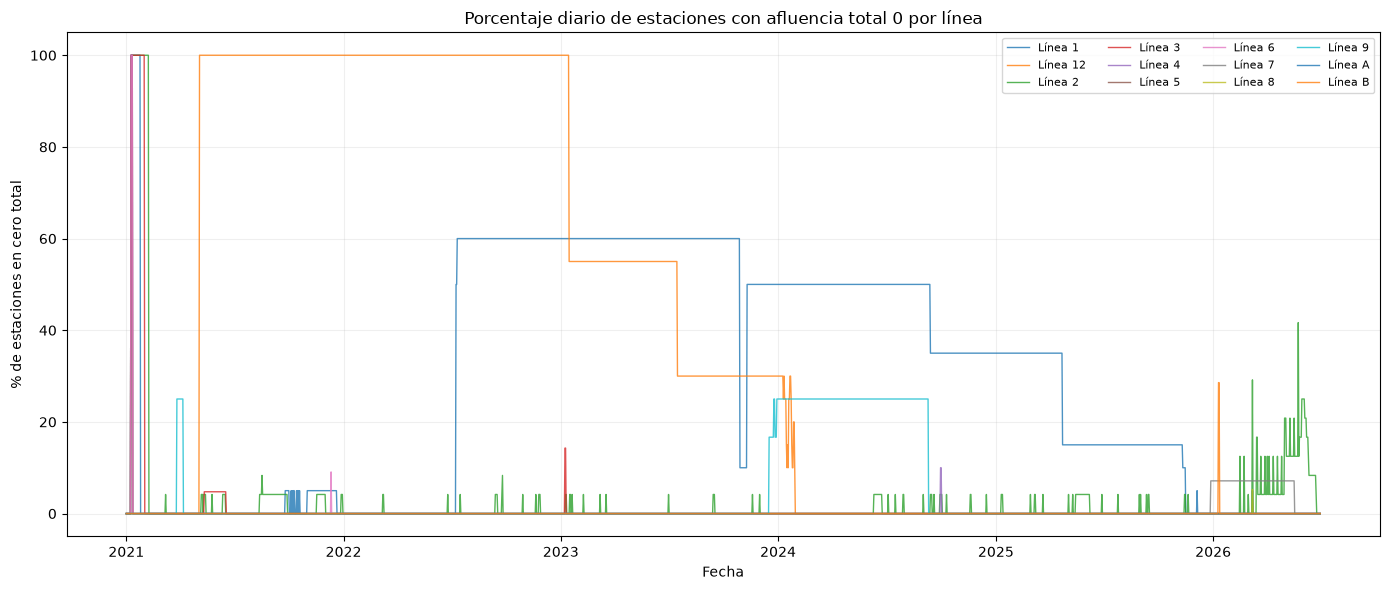

In [204]:
fig, ax = plt.subplots(figsize=(14, 6))

for linea, datos_linea in linea_dia_ceros.groupby('linea'):
    ax.plot(
        datos_linea['fecha'],
        datos_linea['pct_estaciones_total_cero'],
        linewidth=1,
        alpha=0.8,
        label=linea,
    )

ax.set_title('Porcentaje diario de estaciones con afluencia total 0 por línea')
ax.set_xlabel('Fecha')
ax.set_ylabel('% de estaciones en cero total')
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Lectura para el siguiente paso:** las rachas largas de `dia_total_cero` son candidatas a `structural breaks`. En especial, conviene contrastar las fechas de `Línea 12` y `Línea 1` contra noticias o comunicados de cierres/reaperturas, porque son las líneas con mayor afectación en ceros totales.

## 11. Contraste con eventos reales del Metro CDMX

Con las rachas largas detectadas, ahora se contrastan los datos contra eventos reales. Esto es importante para justificar si un cero debe excluirse, marcarse con bandera o modelarse.

Fuentes consultadas:

- Gobierno CDMX reportó el colapso de la estructura elevada de Línea 12 el **3 de mayo de 2021**, entre Olivos y San Lorenzo Tezonco.
- Gobierno CDMX reportó reapertura de Línea 12 por etapas: tramo subterráneo Mixcoac-Atlalilco el **15 de enero de 2023**, cinco estaciones elevadas Culhuacán-Periférico Oriente el **15 de julio de 2023**, y reapertura total con Tezonco-Tláhuac el **30 de enero de 2024**.
- Línea 1 tuvo cierres por modernización: Pantitlán-Salto del Agua desde **11 de julio de 2022**, reapertura Pantitlán-Isabel la Católica el **29 de octubre de 2023**, y cierre del tramo Salto del Agua-Observatorio desde la noche del **9 de noviembre de 2023**.
- Línea 9 cerró Pantitlán, Puebla y Ciudad Deportiva por renivelación desde **17 de diciembre de 2023** y reabrió el **10 de septiembre de 2024**.

In [205]:
eventos_estructurales = pd.DataFrame([
    {
        'evento': 'Colapso y cierre de Línea 12',
        'linea': 'Línea 12',
        'fecha_inicio': '2021-05-04',
        'fecha_fin': '2023-01-14',
        'estaciones_evento': 'Todas / reapertura pendiente',
        'decision_etl': 'Marcar como structural break; ceros totales como ausentes para modelo',
    },
    {
        'evento': 'Reapertura tramo subterráneo L12',
        'linea': 'Línea 12',
        'fecha_inicio': '2023-01-15',
        'fecha_fin': '2023-07-14',
        'estaciones_evento': 'Mixcoac a Atlalilco operando; tramo elevado cerrado',
        'decision_etl': 'Marcar tramo elevado cerrado; conservar operación del tramo abierto',
    },
    {
        'evento': 'Reapertura parcial tramo elevado L12',
        'linea': 'Línea 12',
        'fecha_inicio': '2023-07-15',
        'fecha_fin': '2024-01-29',
        'estaciones_evento': 'Culhuacán a Periférico Oriente operando; Tezonco a Tláhuac cerrado',
        'decision_etl': 'Marcar estaciones aún cerradas como structural break',
    },
    {
        'evento': 'Reapertura total L12',
        'linea': 'Línea 12',
        'fecha_inicio': '2024-01-30',
        'fecha_fin': '2026-06-30',
        'estaciones_evento': 'Servicio restablecido en las 20 estaciones',
        'decision_etl': 'Periodo posterior comparable, salvo anomalías puntuales',
    },
    {
        'evento': 'Modernización L1 etapa 1',
        'linea': 'Línea 1',
        'fecha_inicio': '2022-07-11',
        'fecha_fin': '2023-10-28',
        'estaciones_evento': 'Pantitlán a Salto del Agua cerrado',
        'decision_etl': 'Marcar como structural break; ceros totales como ausentes para modelo',
    },
    {
        'evento': 'Modernización L1 etapa 2',
        'linea': 'Línea 1',
        'fecha_inicio': '2023-11-10',
        'fecha_fin': '2026-06-30',
        'estaciones_evento': 'Salto del Agua a Observatorio cerrado en el periodo de la base',
        'decision_etl': 'Marcar como structural break; revisar reaperturas parciales después',
    },
    {
        'evento': 'Renivelación tramo elevado L9',
        'linea': 'Línea 9',
        'fecha_inicio': '2023-12-17',
        'fecha_fin': '2024-09-09',
        'estaciones_evento': 'Pantitlán, Puebla y Ciudad Deportiva cerradas',
        'decision_etl': 'Marcar estaciones cerradas como structural break',
    },
])

eventos_estructurales['fecha_inicio'] = pd.to_datetime(eventos_estructurales['fecha_inicio'])
eventos_estructurales['fecha_fin'] = pd.to_datetime(eventos_estructurales['fecha_fin'])

eventos_estructurales

,evento,linea,fecha_inicio,fecha_fin,estaciones_evento,decision_etl
0,Colapso y cierre de Línea 12,Línea 12,2021-05-04,2023-01-14,Todas / reapertura pendiente,Marcar como structural break; ceros totales co...
1,Reapertura tramo subterráneo L12,Línea 12,2023-01-15,2023-07-14,Mixcoac a Atlalilco operando; tramo elevado ce...,Marcar tramo elevado cerrado; conservar operac...
2,Reapertura parcial tramo elevado L12,Línea 12,2023-07-15,2024-01-29,Culhuacán a Periférico Oriente operando; Tezon...,Marcar estaciones aún cerradas como structural...
3,Reapertura total L12,Línea 12,2024-01-30,2026-06-30,Servicio restablecido en las 20 estaciones,"Periodo posterior comparable, salvo anomalías ..."
4,Modernización L1 etapa 1,Línea 1,2022-07-11,2023-10-28,Pantitlán a Salto del Agua cerrado,Marcar como structural break; ceros totales co...
5,Modernización L1 etapa 2,Línea 1,2023-11-10,2026-06-30,Salto del Agua a Observatorio cerrado en el pe...,Marcar como structural break; revisar reapertu...
6,Renivelación tramo elevado L9,Línea 9,2023-12-17,2024-09-09,"Pantitlán, Puebla y Ciudad Deportiva cerradas",Marcar estaciones cerradas como structural break


In [206]:
comparacion_rachas_eventos = []

for _, racha in rachas_cero_estacion.iterrows():
    eventos_linea = eventos_estructurales[
        eventos_estructurales['linea'].eq(racha['linea'])
    ]

    for _, evento in eventos_linea.iterrows():
        inicio_overlap = max(racha['fecha_inicio'], evento['fecha_inicio'])
        fin_overlap = min(racha['fecha_fin'], evento['fecha_fin'])
        dias_overlap = (fin_overlap - inicio_overlap).days + 1

        if dias_overlap > 0:
            comparacion_rachas_eventos.append({
                'linea': racha['linea'],
                'estacion': racha['estacion'],
                'racha_inicio': racha['fecha_inicio'],
                'racha_fin': racha['fecha_fin'],
                'dias_racha': racha['dias'],
                'evento': evento['evento'],
                'evento_inicio': evento['fecha_inicio'],
                'evento_fin': evento['fecha_fin'],
                'dias_overlap': dias_overlap,
                'pct_racha_explicada': round(dias_overlap / racha['dias'] * 100, 2),
            })

comparacion_rachas_eventos = pd.DataFrame(comparacion_rachas_eventos)

comparacion_rachas_eventos.sort_values(
    ['dias_overlap', 'pct_racha_explicada'], ascending=False
).head(40)

,linea,estacion,racha_inicio,racha_fin,dias_racha,evento,evento_inicio,evento_fin,dias_overlap,pct_racha_explicada
37,Línea 1,Observatorio,2023-11-10,2025-11-15,737,Modernización L1 etapa 2,2023-11-10,2026-06-30,737,100.00
38,Línea 1,Juanacatlán,2023-11-10,2025-11-15,737,Modernización L1 etapa 2,2023-11-10,2026-06-30,737,100.00
39,Línea 1,Tacubaya,2023-11-10,2025-11-10,732,Modernización L1 etapa 2,2023-11-10,2026-06-30,732,100.00
40,Línea 12,Ermita,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00
41,Línea 12,Eje Central,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00
42,Línea 12,Atlalilco,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00
43,Línea 12,Mixcoac,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00
44,Línea 12,Hospital 20 de Noviembre,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00
45,Línea 12,Zapata,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00
46,Línea 12,Insurgentes Sur,2021-05-04,2023-01-14,621,Colapso y cierre de Línea 12,2021-05-04,2023-01-14,621,100.00


In [207]:
df_limpio['structural_break_metro'] = False
df_limpio['evento_estructural'] = pd.NA

for _, evento in eventos_estructurales.iterrows():
    mascara_evento = (
        df_limpio['linea'].eq(evento['linea'])
        & df_limpio['fecha'].between(evento['fecha_inicio'], evento['fecha_fin'])
    )

    df_limpio.loc[mascara_evento, 'structural_break_metro'] = True
    df_limpio.loc[mascara_evento, 'evento_estructural'] = evento['evento']

df_limpio['cero_total_sin_evento'] = (
    df_limpio['cero_total_estacion_dia']
    & ~df_limpio['structural_break_metro']
)

resumen_eventos_estructurales = (
    df_limpio.groupby(['linea', 'evento_estructural'], dropna=False)
    .agg(
        registros=('afluencia', 'size'),
        ceros=('afluencia', lambda s: s.eq(0).sum()),
        nulos_para_modelo=('afluencia_modelo', lambda s: s.isna().sum()),
    )
    .reset_index()
)

resumen_eventos_estructurales[
    resumen_eventos_estructurales['evento_estructural'].notna()
].sort_values(['linea', 'evento_estructural'])

,linea,evento_estructural,registros,ceros,nulos_para_modelo
0,Línea 1,Modernización L1 etapa 1,28500,17413,17100
1,Línea 1,Modernización L1 etapa 2,57840,29789,15756
3,Línea 12,Colapso y cierre de Línea 12,37260,37260,37260
4,Línea 12,Reapertura parcial tramo elevado L12,11940,6332,3477
5,Línea 12,Reapertura total L12,52980,17660,0
6,Línea 12,Reapertura tramo subterráneo L12,10860,7602,5973
15,Línea 9,Renivelación tramo elevado L9,9648,4734,2379


Los ceros totales fuera de eventos estructurales conocidos se conservan en la base y se documentan con `cero_total_sin_evento`. No se eliminan todavía porque son evidencia de calidad de datos; para modelado se excluyen mediante `afluencia_modelo`, igual que los otros ceros totales.

In [208]:
resumen_ceros_sin_evento = pd.DataFrame({
    'ceros_originales': [df_limpio['afluencia'].eq(0).sum()],
    'ceros_en_eventos_estructurales': [(
        df_limpio['afluencia'].eq(0) & df_limpio['structural_break_metro']
    ).sum()],
    'ceros_fuera_de_eventos': [(
        df_limpio['afluencia'].eq(0) & ~df_limpio['structural_break_metro']
    ).sum()],
    'ceros_totales_sin_evento': [df_limpio['cero_total_sin_evento'].sum()],
    'ceros_parciales_sin_evento': [(
        df_limpio['cero_parcial_tipo_pago'] & ~df_limpio['structural_break_metro']
    ).sum()],
})

resumen_ceros_sin_evento

,ceros_originales,ceros_en_eventos_estructurales,ceros_fuera_de_eventos,ceros_totales_sin_evento,ceros_parciales_sin_evento
0,285412,120790,164622,7275,157347


In [209]:
ceros_totales_sin_evento_por_linea = (
    df_limpio[df_limpio['cero_total_sin_evento']]
    .groupby(['linea', 'estacion'])
    .size()
    .reset_index(name='registros_cero_total_sin_evento')
    .sort_values('registros_cero_total_sin_evento', ascending=False)
)

ceros_totales_sin_evento_por_linea.head(30)

,linea,estacion,registros_cero_total_sin_evento
43,Línea 2,Zócalo/Tenochtitlan,687
99,Línea 7,Auditorio,423
36,Línea 2,San Antonio Abad,351
7,Línea 1,Insurgentes,249
22,Línea 2,Chabacano,240
34,Línea 2,Portales,228
29,Línea 2,Nativitas,210
47,Línea 3,Coyoacán,180
40,Línea 2,Viaducto,159
20,Línea 2,Allende,99


**Decisión ETL para structural breaks:** los cierres confirmados no se deben interpretar como demanda cero. Se conservan en la base original, pero para modelado se recomienda usar `afluencia_modelo` y las banderas `cero_total_estacion_dia` y `structural_break_metro`. Esto permite hacer el experimento pedido en el PDF: comparar el modelo con y sin las decisiones de structural breaks.

## 12. Validación contra catálogo oficial de estaciones

Como parte de la auditoría categórica, se compara el catálogo `linea-estacion` observado en la base contra el catálogo oficial del Metro CDMX. La referencia principal son las páginas oficiales de cada línea del STC Metro y el conjunto de Datos Abiertos de CDMX de líneas y estaciones.

Esta revisión ayuda a detectar estaciones mal asignadas a una línea, nombres antiguos, errores de acento o estaciones que aparecen en la base pero no corresponden a la red oficial.

In [210]:
catalogo_oficial_metro = {
    'Línea 1': ['Observatorio', 'Tacubaya', 'Juanacatlán', 'Chapultepec', 'Sevilla', 'Insurgentes', 'Cuauhtémoc', 'Balderas', 'Salto del Agua', 'Isabel la Católica', 'Pino Suárez', 'Merced', 'Candelaria', 'San Lázaro', 'Moctezuma', 'Balbuena', 'Boulevard Puerto Aéreo', 'Gómez Farías', 'Zaragoza', 'Pantitlán'],
    'Línea 2': ['Cuatro Caminos', 'Panteones', 'Tacuba', 'Cuitláhuac', 'Popotla', 'Colegio Militar', 'Normal', 'San Cosme', 'Revolución', 'Hidalgo', 'Bellas Artes', 'Allende', 'Zócalo/Tenochtitlan', 'Pino Suárez', 'San Antonio Abad', 'Chabacano', 'Viaducto', 'Xola', 'Villa de Cortés', 'Nativitas', 'Portales', 'Ermita', 'General Anaya', 'Tasqueña'],
    'Línea 3': ['Indios Verdes', 'Deportivo 18 de Marzo', 'Potrero', 'La Raza', 'Tlatelolco', 'Guerrero', 'Hidalgo', 'Juárez', 'Balderas', 'Niños Héroes', 'Hospital General', 'Centro Médico', 'Etiopía/Plaza de la Transparencia', 'Eugenia', 'División del Norte', 'Zapata', 'Coyoacán', 'Viveros/Derechos Humanos', 'Miguel Ángel de Quevedo', 'Copilco', 'Universidad'],
    'Línea 4': ['Martín Carrera', 'Talismán', 'Bondojito', 'Consulado', 'Canal del Norte', 'Morelos', 'Candelaria', 'Fray Servando', 'Jamaica', 'Santa Anita'],
    'Línea 5': ['Pantitlán', 'Hangares', 'Terminal Aérea', 'Oceanía', 'Aragón', 'Eduardo Molina', 'Consulado', 'Valle Gómez', 'Misterios', 'La Raza', 'Autobuses del Norte', 'Instituto del Petróleo', 'Politécnico'],
    'Línea 6': ['El Rosario', 'Tezozómoc', 'UAM-Azcapotzalco', 'Ferrería/Arena Ciudad de México', 'Norte 45', 'Vallejo', 'Instituto del Petróleo', 'Lindavista', 'Deportivo 18 de Marzo', 'La Villa/Basílica', 'Martín Carrera'],
    'Línea 7': ['El Rosario', 'Aquiles Serdán', 'Camarones', 'Refinería', 'Tacuba', 'San Joaquín', 'Polanco', 'Auditorio', 'Constituyentes', 'Tacubaya', 'San Pedro de los Pinos', 'San Antonio', 'Mixcoac', 'Barranca del Muerto'],
    'Línea 8': ['Garibaldi/Lagunilla', 'Bellas Artes', 'San Juan de Letrán', 'Salto del Agua', 'Doctores', 'Obrera', 'Chabacano', 'La Viga', 'Santa Anita', 'Coyuya', 'Iztacalco', 'Apatlaco', 'Aculco', 'Escuadrón 201', 'Atlalilco', 'Iztapalapa', 'Cerro de la Estrella', 'UAM-I', 'Constitución de 1917'],
    'Línea 9': ['Pantitlán', 'Puebla', 'Ciudad Deportiva', 'Velódromo', 'Mixiuhca', 'Jamaica', 'Chabacano', 'Lázaro Cárdenas', 'Centro Médico', 'Chilpancingo', 'Patriotismo', 'Tacubaya'],
    'Línea A': ['Pantitlán', 'Agrícola Oriental', 'Canal de San Juan', 'Tepalcates', 'Guelatao', 'Peñón Viejo', 'Acatitla', 'Santa Marta', 'Los Reyes', 'La Paz'],
    'Línea B': ['Ciudad Azteca', 'Plaza Aragón', 'Olímpica', 'Ecatepec', 'Múzquiz', 'Río de los Remedios', 'Impulsora', 'Nezahualcóyotl', 'Villa de Aragón', 'Bosque de Aragón', 'Deportivo Oceanía', 'Oceanía', 'Romero Rubio', 'Ricardo Flores Magón', 'San Lázaro', 'Morelos', 'Tepito', 'Lagunilla', 'Garibaldi/Lagunilla', 'Guerrero', 'Buenavista'],
    'Línea 12': ['Mixcoac', 'Insurgentes Sur', 'Hospital 20 de Noviembre', 'Zapata', 'Parque de los Venados', 'Eje Central', 'Ermita', 'Mexicaltzingo', 'Atlalilco', 'Culhuacán', 'San Andrés Tomatlán', 'Lomas Estrella', 'Calle 11', 'Periférico Oriente', 'Tezonco', 'Olivos', 'Nopalera', 'Zapotitlán', 'Tlaltenco', 'Tláhuac'],
}

catalogo_oficial = pd.DataFrame(
    [(linea, estacion) for linea, estaciones in catalogo_oficial_metro.items() for estacion in estaciones],
    columns=['linea', 'estacion_oficial'],
)

catalogo_base = df_limpio[['linea', 'estacion']].drop_duplicates().copy()

catalogo_oficial['estacion_norm'] = catalogo_oficial['estacion_oficial'].map(normalizar_texto_comparacion)
catalogo_base['estacion_norm'] = catalogo_base['estacion'].map(normalizar_texto_comparacion)

comparacion_catalogo_oficial = catalogo_base.merge(
    catalogo_oficial,
    on=['linea', 'estacion_norm'],
    how='outer',
    indicator=True,
)

resumen_comparacion_catalogo = pd.DataFrame({
    'pares_linea_estacion_base': [len(catalogo_base)],
    'pares_linea_estacion_oficial': [len(catalogo_oficial)],
    'coinciden': [(comparacion_catalogo_oficial['_merge'] == 'both').sum()],
    'solo_en_base': [(comparacion_catalogo_oficial['_merge'] == 'left_only').sum()],
    'solo_en_catalogo_oficial': [(comparacion_catalogo_oficial['_merge'] == 'right_only').sum()],
})

resumen_comparacion_catalogo

,pares_linea_estacion_base,pares_linea_estacion_oficial,coinciden,solo_en_base,solo_en_catalogo_oficial
0,195,195,195,0,0


In [211]:
diferencias_catalogo = comparacion_catalogo_oficial[
    comparacion_catalogo_oficial['_merge'] != 'both'
].sort_values(['linea', '_merge', 'estacion', 'estacion_oficial'])

diferencias_catalogo

,linea,estacion,estacion_norm,estacion_oficial,_merge


**Conclusión de catálogo:** si `solo_en_base` y `solo_en_catalogo_oficial` son 0, entonces todas las estaciones observadas en la base corresponden a la línea oficial del Metro CDMX. Si aparecen diferencias, se deben revisar como posibles errores de escritura, nombres oficiales distintos o estaciones asignadas a una línea incorrecta.

## 13. Análisis por tipo de pago

Ahora analizamos cómo se distribuye la afluencia por `tipo_pago`. Para evitar que los cierres o ausencias de operación distorsionen el análisis, usamos `afluencia_modelo`, que ya excluye los ceros totales de estación-día. Los ceros parciales por tipo de pago se conservan porque pueden representar cambios reales en el uso del producto de pago.

In [212]:
df_pago = df_limpio.dropna(subset=['afluencia_modelo']).copy()

resumen_tipo_pago_total = (
    df_pago.groupby('tipo_pago')
    .agg(
        afluencia_total=('afluencia_modelo', 'sum'),
        registros=('afluencia_modelo', 'size'),
        promedio_por_registro=('afluencia_modelo', 'mean'),
    )
    .reset_index()
    .sort_values('afluencia_total', ascending=False)
)

resumen_tipo_pago_total['pct_afluencia'] = (
    resumen_tipo_pago_total['afluencia_total']
    / resumen_tipo_pago_total['afluencia_total'].sum()
    * 100
).round(2)

resumen_tipo_pago_total

,tipo_pago,afluencia_total,registros,promedio_por_registro,pct_afluencia
2,Prepago,4.425865e+09,361625,12238.824373,74.01
1,Gratuidad,7.835358e+08,361625,2166.707974,13.10
0,Boleto,7.703017e+08,361625,2130.111746,12.88


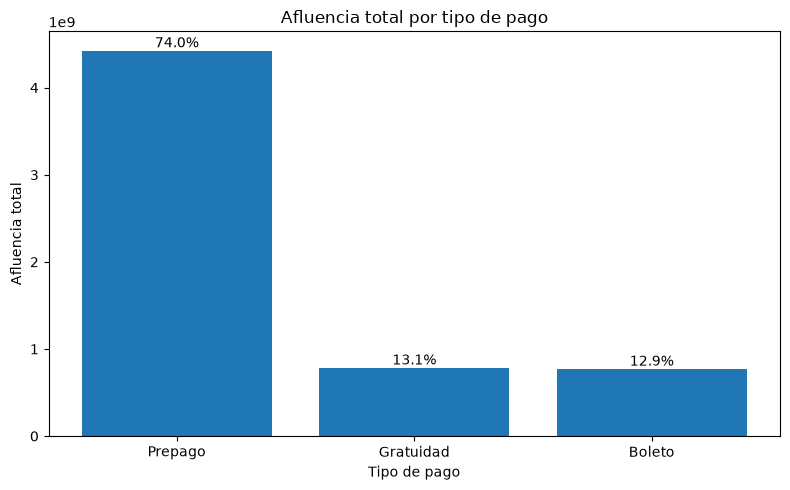

In [213]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    resumen_tipo_pago_total['tipo_pago'],
    resumen_tipo_pago_total['afluencia_total'],
)

ax.set_title('Afluencia total por tipo de pago')
ax.set_xlabel('Tipo de pago')
ax.set_ylabel('Afluencia total')

for i, fila in resumen_tipo_pago_total.reset_index(drop=True).iterrows():
    ax.text(
        i,
        fila['afluencia_total'],
        f"{fila['pct_afluencia']:.1f}%",
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

Ahora revisamos la distribución por línea. Para comparar líneas de tamaño distinto, conviene usar una gráfica de barras apiladas al 100%, porque muestra la proporción de cada tipo de pago dentro de cada línea.

In [214]:
afluencia_pago_linea = (
    df_pago.groupby(['linea', 'tipo_pago'])['afluencia_modelo']
    .sum()
    .reset_index()
)

tabla_pago_linea = afluencia_pago_linea.pivot(
    index='linea', columns='tipo_pago', values='afluencia_modelo'
).fillna(0)

orden_lineas_pago = tabla_pago_linea.sum(axis=1).sort_values(ascending=False).index
tabla_pago_linea = tabla_pago_linea.loc[orden_lineas_pago]

tabla_pago_linea_pct = tabla_pago_linea.div(tabla_pago_linea.sum(axis=1), axis=0) * 100

tabla_pago_linea_pct.round(2)

tipo_pago,Boleto,Gratuidad,Prepago
linea,,,
Línea 2,13.06,13.26,73.69
Línea 3,13.25,12.89,73.86
Línea B,13.74,13.79,72.47
Línea 8,12.44,13.92,73.64
Línea 1,16.78,15.67,67.55
Línea 9,13.34,10.59,76.06
Línea 7,9.24,11.02,79.74
Línea A,15.66,11.87,72.47
Línea 12,0.00,13.51,86.49


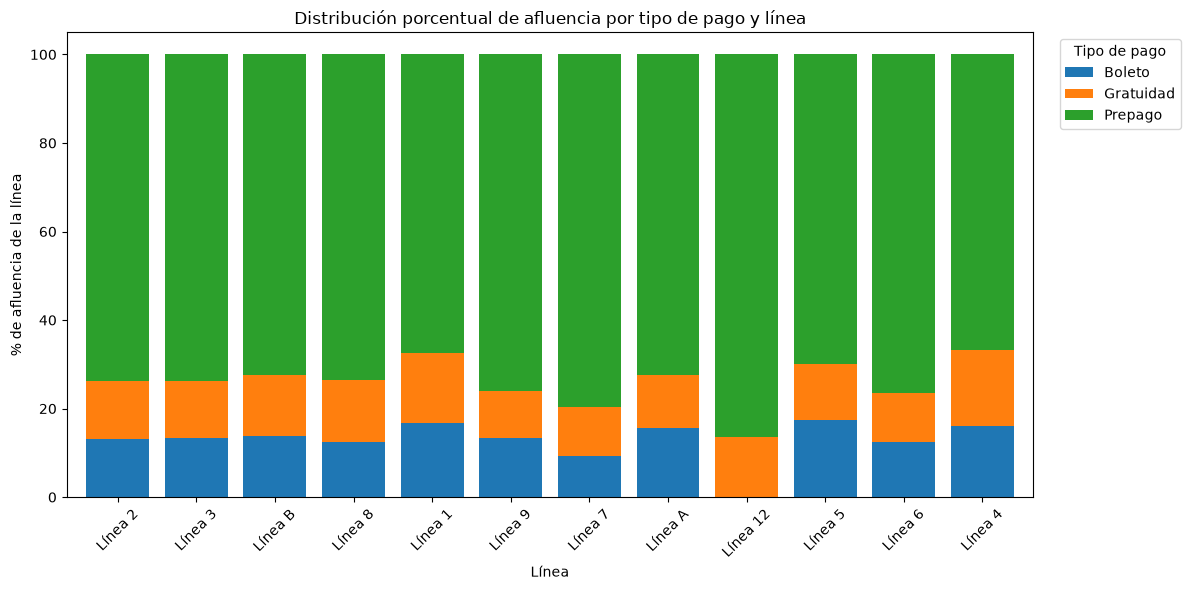

In [215]:
fig, ax = plt.subplots(figsize=(12, 6))

tabla_pago_linea_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.8,
)

ax.set_title('Distribución porcentual de afluencia por tipo de pago y línea')
ax.set_xlabel('Línea')
ax.set_ylabel('% de afluencia de la línea')
ax.legend(title='Tipo de pago', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Para estaciones no conviene graficar las 195 combinaciones `línea-estación` en una sola barra porque se vuelve ilegible. En su lugar usamos tres vistas:

- Tabla con el tipo de pago dominante por estación.
- Gráfica de las 30 estaciones con mayor afluencia.
- Boxplot de proporciones por tipo de pago para ver la distribución general entre estaciones.

In [216]:
afluencia_pago_estacion = (
    df_pago.groupby(['linea', 'estacion', 'tipo_pago'])['afluencia_modelo']
    .sum()
    .reset_index()
)

tabla_pago_estacion = afluencia_pago_estacion.pivot_table(
    index=['linea', 'estacion'],
    columns='tipo_pago',
    values='afluencia_modelo',
    fill_value=0,
)

tabla_pago_estacion['afluencia_total'] = tabla_pago_estacion.sum(axis=1)

columnas_tipo_pago = [col for col in tabla_pago_estacion.columns if col != 'afluencia_total']
tabla_pago_estacion_pct = tabla_pago_estacion[columnas_tipo_pago].div(
    tabla_pago_estacion['afluencia_total'], axis=0
) * 100

tipo_pago_dominante_estacion = tabla_pago_estacion_pct.idxmax(axis=1)
pct_tipo_pago_dominante_estacion = tabla_pago_estacion_pct.max(axis=1).round(2)

resumen_pago_estacion = tabla_pago_estacion.reset_index()
resumen_pago_estacion['tipo_pago_dominante'] = tipo_pago_dominante_estacion.values
resumen_pago_estacion['pct_tipo_pago_dominante'] = pct_tipo_pago_dominante_estacion.values

resumen_pago_estacion.sort_values('afluencia_total', ascending=False).head(30)

tipo_pago,linea,estacion,Boleto,Gratuidad,Prepago,afluencia_total,tipo_pago_dominante,pct_tipo_pago_dominante
139,Línea 8,Constitución de 1917,12858590.0,20657936.0,136799497.0,170316023.0,Prepago,80.32
75,Línea 3,Indios Verdes,22533946.0,15199431.0,124679121.0,162412498.0,Prepago,76.77
44,Línea 2,Cuatro Caminos,2692944.0,11447213.0,123916969.0,138057126.0,Prepago,89.76
59,Línea 2,Tasqueña,21877823.0,4898965.0,73512047.0,100288835.0,Prepago,73.30
162,Línea 9,Tacubaya,13812548.0,8034968.0,73772409.0,95619925.0,Prepago,77.15
104,Línea 5,Pantitlán,19777841.0,9574627.0,65815859.0,95168327.0,Prepago,69.16
175,Línea B,Buenavista,8185844.0,8543840.0,73155648.0,89885332.0,Prepago,81.39
82,Línea 3,Universidad,10704929.0,8102702.0,70995862.0,89803493.0,Prepago,79.06
176,Línea B,Ciudad Azteca,6476133.0,11020747.0,58986500.0,76483380.0,Prepago,77.12
159,Línea 9,Pantitlán,13585810.0,6410270.0,55060828.0,75056908.0,Prepago,73.36


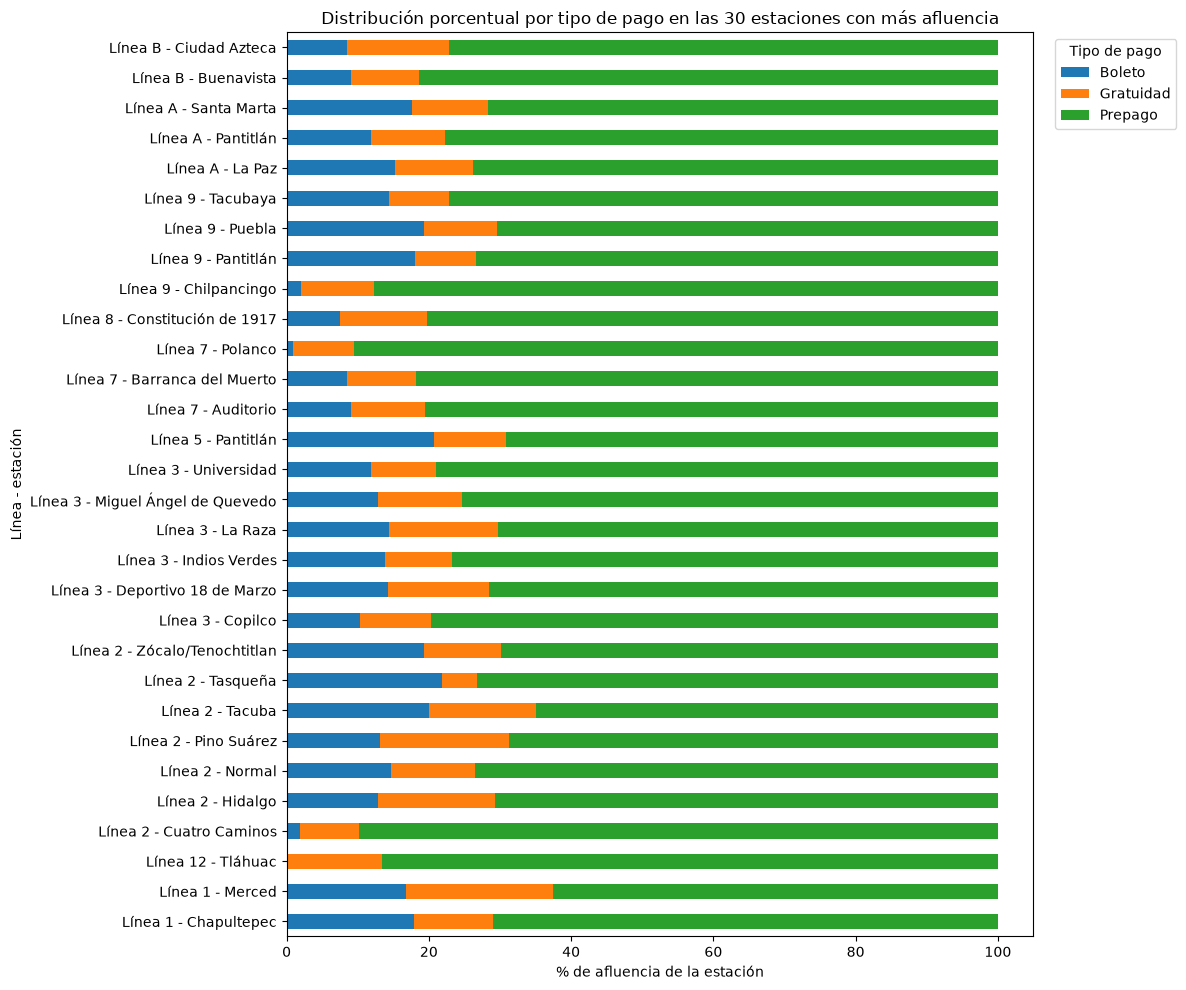

In [217]:
top_estaciones_pago = resumen_pago_estacion.sort_values(
    'afluencia_total', ascending=False
).head(30).copy()

top_estaciones_pago['linea_estacion'] = (
    top_estaciones_pago['linea'] + ' - ' + top_estaciones_pago['estacion']
)

top_estaciones_plot = top_estaciones_pago.set_index('linea_estacion')[columnas_tipo_pago]
top_estaciones_plot_pct = top_estaciones_plot.div(top_estaciones_plot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 10))
top_estaciones_plot_pct.sort_index().plot(kind='barh', stacked=True, ax=ax)

ax.set_title('Distribución porcentual por tipo de pago en las 30 estaciones con más afluencia')
ax.set_xlabel('% de afluencia de la estación')
ax.set_ylabel('Línea - estación')
ax.legend(title='Tipo de pago', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

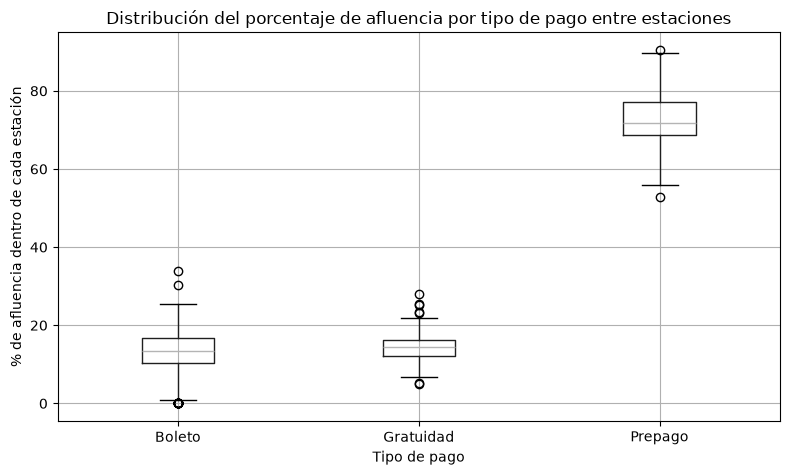

,count,mean,std,min,25%,50%,75%,max
tipo_pago,,,,,,,,
Boleto,195.0,12.84,6.12,0.00,10.34,13.49,16.70,33.84
Gratuidad,195.0,14.31,3.61,4.88,12.04,14.35,16.30,28.05
Prepago,195.0,72.85,7.38,52.72,68.68,71.78,77.24,90.46


In [218]:
proporciones_estacion_largo = (
    tabla_pago_estacion_pct.reset_index()
    .melt(
        id_vars=['linea', 'estacion'],
        value_vars=columnas_tipo_pago,
        var_name='tipo_pago',
        value_name='pct_afluencia_estacion',
    )
)

fig, ax = plt.subplots(figsize=(8, 5))
proporciones_estacion_largo.boxplot(
    column='pct_afluencia_estacion',
    by='tipo_pago',
    ax=ax,
)

ax.set_title('Distribución del porcentaje de afluencia por tipo de pago entre estaciones')
ax.set_xlabel('Tipo de pago')
ax.set_ylabel('% de afluencia dentro de cada estación')
plt.suptitle('')

plt.tight_layout()
plt.show()

proporciones_estacion_largo.groupby('tipo_pago')['pct_afluencia_estacion'].describe().round(2)

**Lectura inicial:** estas gráficas permiten ver si el modelo podría aprender patrones reales de demanda o solo diferencias contables entre productos de pago. Después de construir features de calendario, podremos revisar correlaciones con día de semana, mes, vacaciones/festivos y eventos estructurales.

## 14. Features de calendario: día de semana, fin de semana y mes

Construimos variables de calendario para analizar cuándo se usa más el Metro. Estas variables también servirán después como features para los modelos de regresión.

Para no mezclar cierres con demanda real, los agregados usan `afluencia_modelo`, que excluye los ceros totales de estación-día.

In [219]:
dias_semana = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo',
}

orden_dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

df_limpio['dia_semana_num'] = df_limpio['fecha'].dt.dayofweek
df_limpio['dia_semana'] = df_limpio['dia_semana_num'].map(dias_semana)
df_limpio['es_fin_semana'] = df_limpio['dia_semana_num'].isin([5, 6])
df_limpio['numero_mes'] = df_limpio['fecha'].dt.month
df_limpio['nombre_mes'] = pd.Categorical(df_limpio['mes'], categories=orden_meses, ordered=True)
df_limpio['anio_mes'] = df_limpio['fecha'].dt.to_period('M').astype(str)

df_calendario = df_limpio.dropna(subset=['afluencia_modelo']).copy()

df_limpio[['fecha', 'dia_semana', 'es_fin_semana', 'nombre_mes', 'anio_mes']].head()

,fecha,dia_semana,es_fin_semana,nombre_mes,anio_mes
0,2021-01-01,Viernes,False,Enero,2021-01
1,2021-01-01,Viernes,False,Enero,2021-01
2,2021-01-01,Viernes,False,Enero,2021-01
3,2021-01-01,Viernes,False,Enero,2021-01
4,2021-01-01,Viernes,False,Enero,2021-01


Primero revisamos el patrón total por día de semana. Usamos promedio diario para comparar días, porque la cantidad de lunes, martes, etc. no siempre es idéntica en el periodo.

In [220]:
afluencia_diaria_total = (
    df_calendario.groupby('fecha')['afluencia_modelo']
    .sum()
    .reset_index(name='afluencia_diaria')
)

afluencia_diaria_total['dia_semana'] = afluencia_diaria_total['fecha'].dt.dayofweek.map(dias_semana)
afluencia_diaria_total['es_fin_semana'] = afluencia_diaria_total['fecha'].dt.dayofweek.isin([5, 6])
afluencia_diaria_total['nombre_mes'] = pd.Categorical(
    afluencia_diaria_total['fecha'].dt.month_name(locale=None),
    ordered=False,
)

resumen_dia_semana_total = (
    afluencia_diaria_total.groupby('dia_semana')['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reindex(orden_dias_semana)
    .reset_index()
)

resumen_dia_semana_total[['mean', 'median', 'min', 'max']] = resumen_dia_semana_total[['mean', 'median', 'min', 'max']].round(0)
resumen_dia_semana_total

,dia_semana,mean,median,min,max,count
0,Lunes,3113530.0,3285249.0,987685.0,4543854.0,287
1,Martes,3277705.0,3419004.0,1224639.0,4622523.0,287
2,Miércoles,3332085.0,3474392.0,1010058.0,4748450.0,286
3,Jueves,3307671.0,3476754.0,1016060.0,4737230.0,286
4,Viernes,3362145.0,3526874.0,723937.0,4890902.0,287
5,Sábado,2711036.0,2834934.0,940652.0,3950910.0,287
6,Domingo,1754162.0,1790854.0,524758.0,2583463.0,287


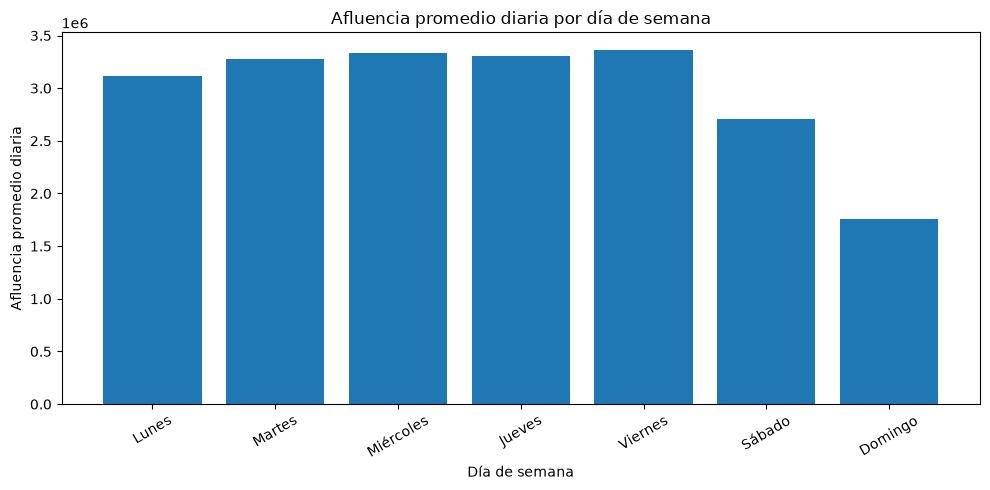

In [221]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(resumen_dia_semana_total['dia_semana'], resumen_dia_semana_total['mean'])
ax.set_title('Afluencia promedio diaria por día de semana')
ax.set_xlabel('Día de semana')
ax.set_ylabel('Afluencia promedio diaria')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [222]:
resumen_fin_semana = (
    afluencia_diaria_total.groupby('es_fin_semana')['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

resumen_fin_semana['tipo_dia'] = resumen_fin_semana['es_fin_semana'].map({False: 'Entre semana', True: 'Fin de semana'})
resumen_fin_semana[['mean', 'median', 'min', 'max']] = resumen_fin_semana[['mean', 'median', 'min', 'max']].round(0)

resumen_fin_semana[['tipo_dia', 'mean', 'median', 'min', 'max', 'count']]

,tipo_dia,mean,median,min,max,count
0,Entre semana,3278570.0,3426502.0,723937.0,4890902.0,1433
1,Fin de semana,2232599.0,2069524.0,524758.0,3950910.0,574


Ahora se revisa el patrón por línea y día de semana. Esto permite saber qué líneas son más usadas en cada tipo de día.

In [223]:
afluencia_linea_dia = (
    df_calendario.groupby(['fecha', 'linea'])['afluencia_modelo']
    .sum()
    .reset_index(name='afluencia_linea_dia')
)

afluencia_linea_dia['dia_semana'] = afluencia_linea_dia['fecha'].dt.dayofweek.map(dias_semana)

tabla_linea_dia_semana = (
    afluencia_linea_dia.groupby(['linea', 'dia_semana'])['afluencia_linea_dia']
    .mean()
    .reset_index()
    .pivot(index='linea', columns='dia_semana', values='afluencia_linea_dia')
    .reindex(columns=orden_dias_semana)
)

tabla_linea_dia_semana.round(0)

dia_semana,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
linea,,,,,,,
Línea 1,298961.0,302459.0,305691.0,301952.0,313480.0,280373.0,193714.0
Línea 12,272885.0,291260.0,291176.0,289492.0,292116.0,204634.0,132690.0
Línea 2,521543.0,551686.0,559618.0,557033.0,572482.0,503356.0,311481.0
Línea 3,466305.0,495985.0,502105.0,500680.0,507252.0,372188.0,240021.0
Línea 4,64155.0,67921.0,69122.0,68841.0,70278.0,63848.0,41835.0
Línea 5,161858.0,167916.0,168526.0,167131.0,168706.0,134138.0,92450.0
Línea 6,104279.0,113359.0,114000.0,112917.0,111253.0,76347.0,49716.0
Línea 7,220083.0,241651.0,244368.0,241739.0,240807.0,161377.0,97602.0
Línea 8,320754.0,341120.0,346429.0,345448.0,350337.0,295797.0,186951.0


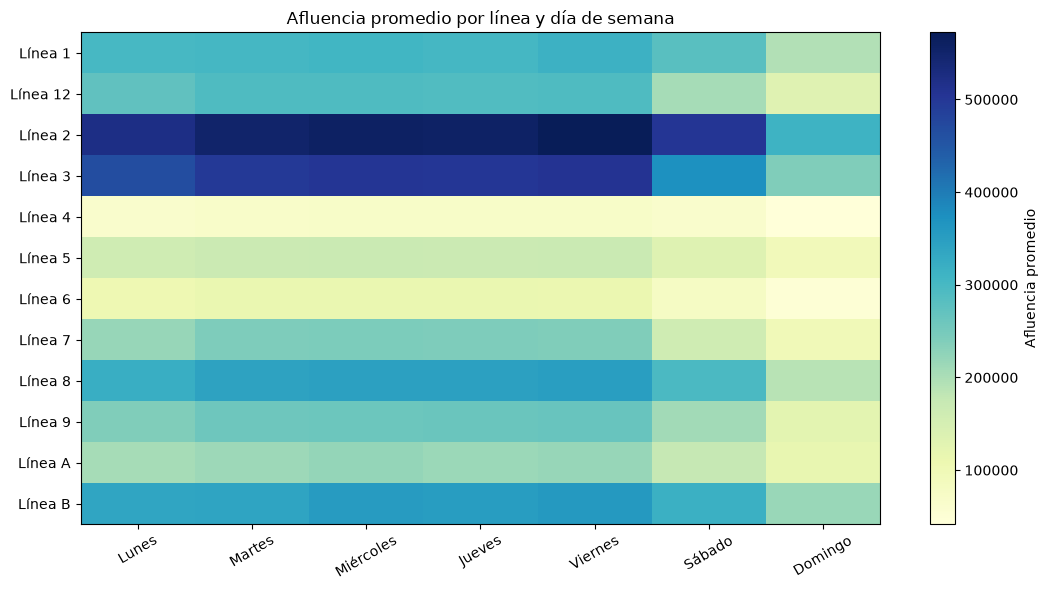

In [224]:
fig, ax = plt.subplots(figsize=(11, 6))
imagen = ax.imshow(tabla_linea_dia_semana, aspect='auto', cmap='YlGnBu')

ax.set_xticks(range(len(tabla_linea_dia_semana.columns)))
ax.set_xticklabels(tabla_linea_dia_semana.columns, rotation=30)
ax.set_yticks(range(len(tabla_linea_dia_semana.index)))
ax.set_yticklabels(tabla_linea_dia_semana.index)
ax.set_title('Afluencia promedio por línea y día de semana')

fig.colorbar(imagen, ax=ax, label='Afluencia promedio')
plt.tight_layout()
plt.show()

Para estaciones buscamos las combinaciones `línea-estación-día` con mayor afluencia promedio. Esta tabla ayuda a detectar qué estaciones son más concurridas y en qué día suelen tener más usuarios.

In [225]:
afluencia_estacion_dia = (
    df_calendario.groupby(['fecha', 'linea', 'estacion'])['afluencia_modelo']
    .sum()
    .reset_index(name='afluencia_estacion_dia')
)

afluencia_estacion_dia['dia_semana'] = afluencia_estacion_dia['fecha'].dt.dayofweek.map(dias_semana)

promedio_estacion_dia_semana = (
    afluencia_estacion_dia.groupby(['linea', 'estacion', 'dia_semana'])['afluencia_estacion_dia']
    .mean()
    .reset_index()
)

top_estacion_dia_semana = promedio_estacion_dia_semana.sort_values(
    'afluencia_estacion_dia', ascending=False
).head(30)

top_estacion_dia_semana

,linea,estacion,dia_semana,afluencia_estacion_dia
979,Línea 8,Constitución de 1917,Viernes,96313.487805
974,Línea 8,Constitución de 1917,Jueves,95589.520979
977,Línea 8,Constitución de 1917,Miércoles,95452.513986
976,Línea 8,Constitución de 1917,Martes,94744.083624
531,Línea 3,Indios Verdes,Viernes,91239.809859
975,Línea 8,Constitución de 1917,Lunes,89519.334495
529,Línea 3,Indios Verdes,Miércoles,89262.812721
526,Línea 3,Indios Verdes,Jueves,89005.095406
528,Línea 3,Indios Verdes,Martes,88591.250000
527,Línea 3,Indios Verdes,Lunes,87535.257951


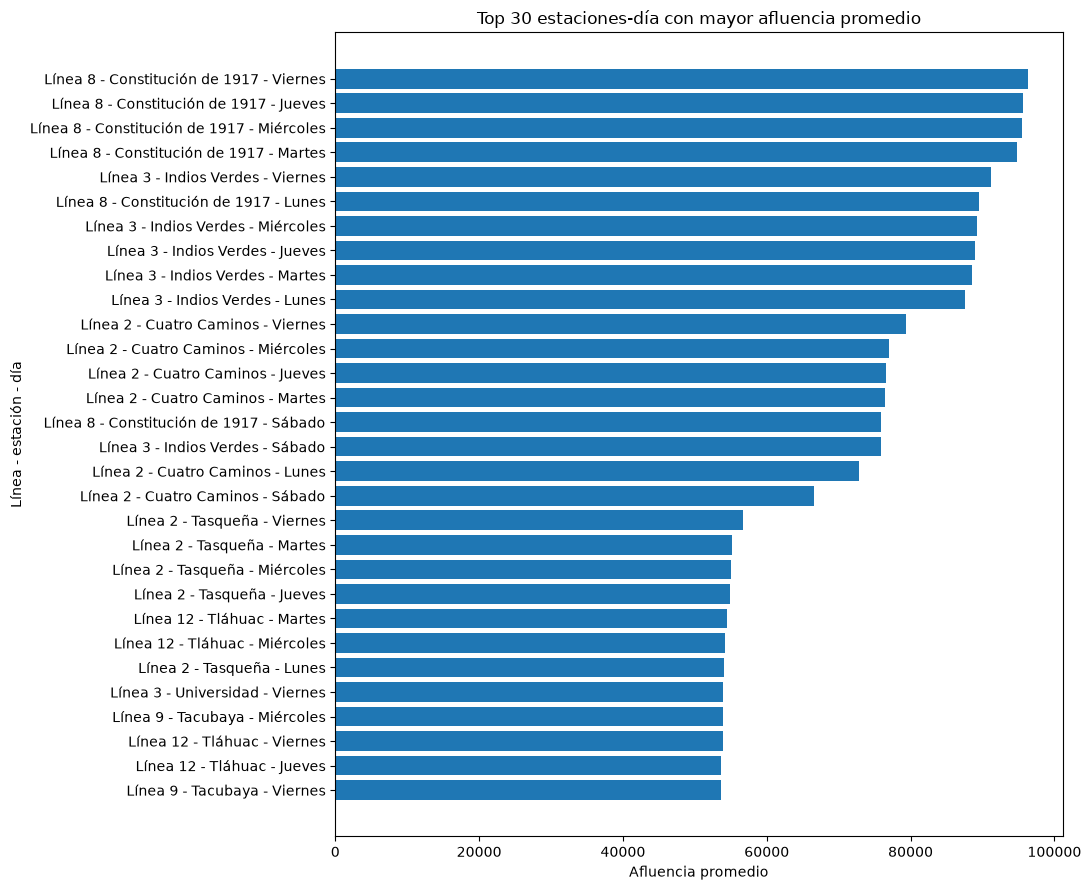

In [226]:
top_estacion_dia_semana_plot = top_estacion_dia_semana.copy()
top_estacion_dia_semana_plot['linea_estacion_dia'] = (
    top_estacion_dia_semana_plot['linea']
    + ' - '
    + top_estacion_dia_semana_plot['estacion']
    + ' - '
    + top_estacion_dia_semana_plot['dia_semana']
)

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(
    top_estacion_dia_semana_plot['linea_estacion_dia'][::-1],
    top_estacion_dia_semana_plot['afluencia_estacion_dia'][::-1],
)

ax.set_title('Top 30 estaciones-día con mayor afluencia promedio')
ax.set_xlabel('Afluencia promedio')
ax.set_ylabel('Línea - estación - día')

plt.tight_layout()
plt.show()

Finalmente revisamos el patrón mensual. Para evitar que un mes con más días parezca mayor solo por duración, se usa afluencia promedio diaria por mes.

In [227]:
afluencia_diaria_total['numero_mes'] = afluencia_diaria_total['fecha'].dt.month
afluencia_diaria_total['nombre_mes'] = pd.Categorical(
    afluencia_diaria_total['numero_mes'].map(dict(enumerate(orden_meses, start=1))),
    categories=orden_meses,
    ordered=True,
)

resumen_mes_total = (
    afluencia_diaria_total.groupby('nombre_mes', observed=True)['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

resumen_mes_total[['mean', 'median', 'min', 'max']] = resumen_mes_total[['mean', 'median', 'min', 'max']].round(0)
resumen_mes_total

,nombre_mes,mean,median,min,max,count
0,Enero,2605326.0,2816256.0,524758.0,3980541.0,186
1,Febrero,2925769.0,2946223.0,859507.0,4356049.0,169
2,Marzo,2990132.0,3090712.0,1237523.0,4166885.0,186
3,Abril,2927575.0,3096284.0,1065074.0,4128234.0,180
4,Mayo,3009049.0,3249784.0,1251847.0,4022543.0,186
5,Junio,3005165.0,3250025.0,1270034.0,4019173.0,180
6,Julio,2837263.0,2911214.0,1345255.0,3816761.0,155
7,Agosto,2983006.0,3179467.0,1318137.0,4127189.0,155
8,Septiembre,3063244.0,3304157.0,1245658.0,4224893.0,150
9,Octubre,3200731.0,3377922.0,1537577.0,4295849.0,155


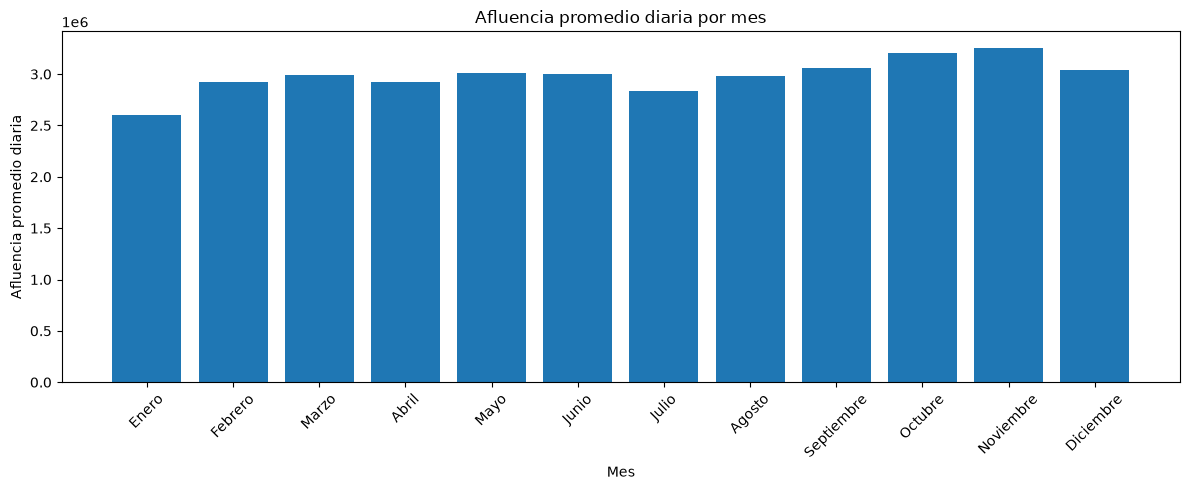

In [228]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(resumen_mes_total['nombre_mes'].astype(str), resumen_mes_total['mean'])
ax.set_title('Afluencia promedio diaria por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Afluencia promedio diaria')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Lectura inicial:** estas variables de calendario permiten comparar demanda por día de semana, fin de semana y mes. Después podemos usarlas como features del modelo y medir si realmente ayudan contra un baseline.

## 15. Media, mediana y total por estación

La media y la mediana cuentan cosas distintas:

- **Media:** promedio diario. Es útil para estimar volumen esperado, pero puede subir mucho si hay picos extremos.
- **Mediana:** día típico. Es menos sensible a picos, pero puede ocultar eventos de alta demanda.
- **Total:** volumen acumulado. Favorece estaciones con más días operando y periodos más completos.

Para este análisis, la mediana no reemplaza a la media: la usamos como contraste para saber si las estaciones top son consistentemente altas o si aparecen arriba por pocos días atípicos.

In [229]:
resumen_estacion_media_mediana = (
    afluencia_estacion_dia.groupby(['linea', 'estacion'])['afluencia_estacion_dia']
    .agg(
        dias_observados='count',
        total='sum',
        media='mean',
        mediana='median',
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        maximo='max',
    )
    .reset_index()
)

resumen_estacion_media_mediana['media_mediana_ratio'] = (
    resumen_estacion_media_mediana['media']
    / resumen_estacion_media_mediana['mediana'].replace(0, pd.NA)
)

columnas_redondear = ['total', 'media', 'mediana', 'p25', 'p75', 'maximo', 'media_mediana_ratio']
resumen_estacion_media_mediana[columnas_redondear] = resumen_estacion_media_mediana[columnas_redondear].round(2)

resumen_estacion_media_mediana.sort_values('media', ascending=False).head(20)

,linea,estacion,dias_observados,total,media,mediana,p25,p75,maximo,media_mediana_ratio
139,Línea 8,Constitución de 1917,2007,170316023.0,84861.00,90953.0,61671.50,106178.00,139988.0,0.93
75,Línea 3,Indios Verdes,1982,162412498.0,81943.74,85478.5,70446.75,97314.75,119489.0,0.96
44,Línea 2,Cuatro Caminos,1976,138057126.0,69866.97,62486.0,50942.25,97680.50,133127.0,1.12
59,Línea 2,Tasqueña,1974,100288835.0,50804.88,53011.0,41734.50,61348.00,87549.0,0.96
162,Línea 9,Tacubaya,2007,95619925.0,47643.21,49705.0,34472.50,62338.00,82573.0,0.96
104,Línea 5,Pantitlán,2004,95168327.0,47489.19,50113.5,41142.00,55735.25,72707.0,0.95
37,Línea 12,Tláhuac,1020,47848092.0,46909.89,51692.5,31681.75,62375.00,76086.0,0.91
82,Línea 3,Universidad,1984,89803493.0,45263.86,44129.5,28900.75,61494.00,86895.0,1.03
175,Línea B,Buenavista,2007,89885332.0,44785.92,47603.0,35574.00,54090.00,67325.0,0.94
159,Línea 9,Pantitlán,1728,75056908.0,43435.71,45542.0,36223.75,52122.00,67991.0,0.95


In [230]:
top_por_mediana = resumen_estacion_media_mediana.sort_values('mediana', ascending=False).head(20)
top_por_mediana

,linea,estacion,dias_observados,total,media,mediana,p25,p75,maximo,media_mediana_ratio
139,Línea 8,Constitución de 1917,2007,170316023.0,84861.00,90953.0,61671.50,106178.00,139988.0,0.93
75,Línea 3,Indios Verdes,1982,162412498.0,81943.74,85478.5,70446.75,97314.75,119489.0,0.96
44,Línea 2,Cuatro Caminos,1976,138057126.0,69866.97,62486.0,50942.25,97680.50,133127.0,1.12
59,Línea 2,Tasqueña,1974,100288835.0,50804.88,53011.0,41734.50,61348.00,87549.0,0.96
37,Línea 12,Tláhuac,1020,47848092.0,46909.89,51692.5,31681.75,62375.00,76086.0,0.91
104,Línea 5,Pantitlán,2004,95168327.0,47489.19,50113.5,41142.00,55735.25,72707.0,0.95
162,Línea 9,Tacubaya,2007,95619925.0,47643.21,49705.0,34472.50,62338.00,82573.0,0.96
175,Línea B,Buenavista,2007,89885332.0,44785.92,47603.0,35574.00,54090.00,67325.0,0.94
159,Línea 9,Pantitlán,1728,75056908.0,43435.71,45542.0,36223.75,52122.00,67991.0,0.95
82,Línea 3,Universidad,1984,89803493.0,45263.86,44129.5,28900.75,61494.00,86895.0,1.03


In [231]:
comparacion_top_media_mediana = resumen_estacion_media_mediana.copy()
comparacion_top_media_mediana['rank_media'] = comparacion_top_media_mediana['media'].rank(ascending=False, method='min')
comparacion_top_media_mediana['rank_mediana'] = comparacion_top_media_mediana['mediana'].rank(ascending=False, method='min')
comparacion_top_media_mediana['diferencia_rank'] = (
    comparacion_top_media_mediana['rank_mediana'] - comparacion_top_media_mediana['rank_media']
)

comparacion_top_media_mediana.sort_values('rank_media').head(30)[[
    'linea', 'estacion', 'dias_observados', 'media', 'mediana',
    'media_mediana_ratio', 'rank_media', 'rank_mediana', 'diferencia_rank'
]]

,linea,estacion,dias_observados,media,mediana,media_mediana_ratio,rank_media,rank_mediana,diferencia_rank
139,Línea 8,Constitución de 1917,2007,84861.00,90953.0,0.93,1.0,1.0,0.0
75,Línea 3,Indios Verdes,1982,81943.74,85478.5,0.96,2.0,2.0,0.0
44,Línea 2,Cuatro Caminos,1976,69866.97,62486.0,1.12,3.0,3.0,0.0
59,Línea 2,Tasqueña,1974,50804.88,53011.0,0.96,4.0,4.0,0.0
162,Línea 9,Tacubaya,2007,47643.21,49705.0,0.96,5.0,7.0,2.0
104,Línea 5,Pantitlán,2004,47489.19,50113.5,0.95,6.0,6.0,0.0
37,Línea 12,Tláhuac,1020,46909.89,51692.5,0.91,7.0,5.0,-2.0
82,Línea 3,Universidad,1984,45263.86,44129.5,1.03,8.0,10.0,2.0
175,Línea B,Buenavista,2007,44785.92,47603.0,0.94,9.0,8.0,-1.0
159,Línea 9,Pantitlán,1728,43435.71,45542.0,0.95,10.0,9.0,-1.0


In [232]:
estaciones_media_muy_superior_mediana = resumen_estacion_media_mediana[
    resumen_estacion_media_mediana['media_mediana_ratio'] >= 1.25
].sort_values('media_mediana_ratio', ascending=False)

estaciones_media_muy_superior_mediana.head(30)

,linea,estacion,dias_observados,total,media,mediana,p25,p75,maximo,media_mediana_ratio
163,Línea 9,Velódromo,2007,24499852.0,12207.2,7181.0,5490.0,9617.0,64689.0,1.7


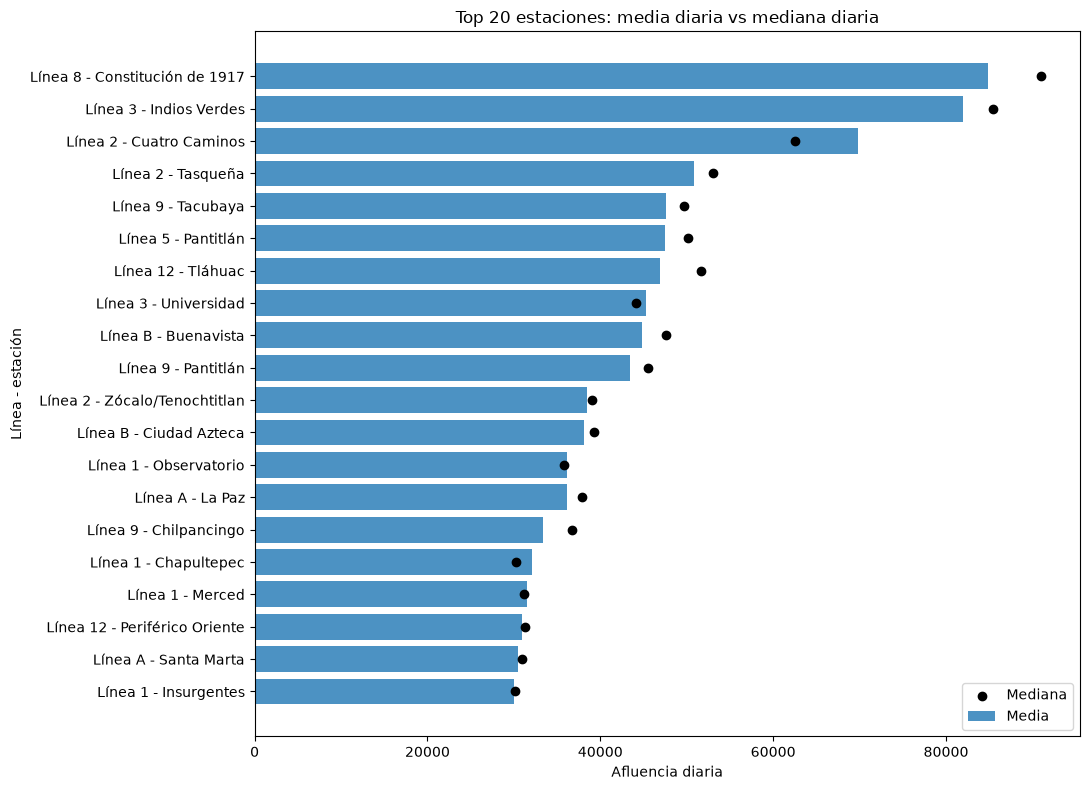

In [233]:
top_comparacion = resumen_estacion_media_mediana.sort_values('media', ascending=False).head(20).copy()
top_comparacion['linea_estacion'] = top_comparacion['linea'] + ' - ' + top_comparacion['estacion']

fig, ax = plt.subplots(figsize=(11, 8))

y = range(len(top_comparacion))
ax.barh(y, top_comparacion['media'], label='Media', alpha=0.8)
ax.scatter(top_comparacion['mediana'], y, color='black', label='Mediana', zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(top_comparacion['linea_estacion'])
ax.invert_yaxis()
ax.set_title('Top 20 estaciones: media diaria vs mediana diaria')
ax.set_xlabel('Afluencia diaria')
ax.set_ylabel('Línea - estación')
ax.legend()

plt.tight_layout()
plt.show()

**Interpretación:** si una estación aparece arriba tanto por media como por mediana, su alta demanda es consistente. Si la media es mucho mayor que la mediana, hay picos o días atípicos que elevan el promedio. Para demanda típica, la mediana es útil; para planeación de capacidad, también importan la media, el percentil 75 y el máximo.

## 16. Estaciones donde media y mediana difieren mucho

Ahora buscamos estaciones donde la media y la mediana cuentan historias distintas. Esto puede revelar:

- **Media mucho mayor que mediana:** pocos días muy altos elevan el promedio. Pueden ser eventos, partidos, conciertos o días especiales.
- **Mediana mucho mayor que media:** hay muchos días bajos que jalan el promedio hacia abajo. Pueden ser domingos, festivos, cierres parciales, periodos de recuperación o estacionalidad.

Esta revisión es exploratoria: identifica candidatos que después se pueden contrastar con eventos externos.

In [234]:
analisis_media_mediana = resumen_estacion_media_mediana.copy()
analisis_media_mediana['diferencia_media_mediana'] = (
    analisis_media_mediana['media'] - analisis_media_mediana['mediana']
)
analisis_media_mediana['diferencia_pct_vs_mediana'] = (
    analisis_media_mediana['diferencia_media_mediana']
    / analisis_media_mediana['mediana'].replace(0, pd.NA)
    * 100
).round(2)

media_mayor_que_mediana = analisis_media_mediana.sort_values(
    'diferencia_pct_vs_mediana', ascending=False
).head(20)

mediana_mayor_que_media = analisis_media_mediana.sort_values(
    'diferencia_pct_vs_mediana', ascending=True
).head(20)

media_mayor_que_mediana[[
    'linea', 'estacion', 'dias_observados', 'media', 'mediana',
    'diferencia_media_mediana', 'diferencia_pct_vs_mediana', 'p75', 'maximo'
]]

,linea,estacion,dias_observados,media,mediana,diferencia_media_mediana,diferencia_pct_vs_mediana,p75,maximo
163,Línea 9,Velódromo,2007,12207.20,7181.0,5026.20,69.99,9617.00,64689.0
64,Línea 3,Balderas,1984,13071.37,11150.0,1921.37,17.23,19484.00,36933.0
123,Línea 7,Constituyentes,2007,8345.80,7326.0,1019.80,13.92,11032.50,27889.0
155,Línea 9,Ciudad Deportiva,1739,5963.89,5321.0,642.89,12.08,6794.00,36865.0
44,Línea 2,Cuatro Caminos,1976,69866.97,62486.0,7380.97,11.81,97680.50,133127.0
1,Línea 1,Balderas,1681,17843.57,16136.0,1707.57,10.58,22017.00,44117.0
66,Línea 3,Copilco,1984,26975.04,24626.5,2348.54,9.54,39177.50,54870.0
148,Línea 8,Salto del Agua,2007,14576.70,13588.0,988.70,7.28,17121.00,35291.0
194,Línea B,Villa de Aragón,2007,11735.75,11033.0,702.75,6.37,16179.00,23712.0
126,Línea 7,Polanco,2007,26812.54,25210.0,1602.54,6.36,39805.50,59337.0


In [235]:
mediana_mayor_que_media[[
    'linea', 'estacion', 'dias_observados', 'media', 'mediana',
    'diferencia_media_mediana', 'diferencia_pct_vs_mediana', 'p25', 'maximo'
]]

,linea,estacion,dias_observados,media,mediana,diferencia_media_mediana,diferencia_pct_vs_mediana,p25,maximo
115,Línea 6,Norte 45,2004,5221.25,6045.5,-824.25,-13.63,4024.75,8978.0
25,Línea 12,Hospital 20 de Noviembre,1386,8654.23,9906.0,-1251.77,-12.64,5445.00,14397.0
111,Línea 6,Instituto del Petróleo,2004,2353.21,2637.5,-284.29,-10.78,1446.00,4490.0
118,Línea 6,Vallejo,2004,6409.92,7174.0,-764.08,-10.65,5282.50,10759.0
141,Línea 8,Doctores,2007,9741.15,10762.0,-1020.85,-9.49,7428.50,22023.0
154,Línea 9,Chilpancingo,2007,33343.72,36767.0,-3423.28,-9.31,26581.00,54064.0
37,Línea 12,Tláhuac,1020,46909.89,51692.5,-4782.61,-9.25,31681.75,76086.0
190,Línea B,Romero Rubio,2005,11877.27,13079.0,-1201.73,-9.19,9761.00,19166.0
74,Línea 3,Hospital General,1984,14462.93,15919.0,-1456.07,-9.15,8987.50,25248.0
9,Línea 1,Juanacatlán,1252,5776.02,6337.5,-561.48,-8.86,4023.50,10841.0


Creamos una función para analizar una estación específica. Devuelve:

- Resumen general.
- Perfil por día de semana.
- Perfil por mes.
- Fechas con mayor afluencia.
- Fechas con menor afluencia positiva.

Esto nos ayuda a inferir si la diferencia se debe a picos altos, días bajos recurrentes o patrones semanales.

In [236]:
def perfil_estacion(linea, estacion, n_fechas=10):
    datos = afluencia_estacion_dia[
        afluencia_estacion_dia['linea'].eq(linea)
        & afluencia_estacion_dia['estacion'].eq(estacion)
    ].copy()

    if datos.empty:
        raise ValueError(f'No hay datos para {linea} - {estacion}')

    datos['dia_semana'] = datos['fecha'].dt.dayofweek.map(dias_semana)
    datos['nombre_mes'] = pd.Categorical(
        datos['fecha'].dt.month.map(dict(enumerate(orden_meses, start=1))),
        categories=orden_meses,
        ordered=True,
    )

    resumen = datos['afluencia_estacion_dia'].agg(
        dias_observados='count',
        total='sum',
        media='mean',
        mediana='median',
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        maximo='max',
    ).to_frame().T.round(2)

    resumen['linea'] = linea
    resumen['estacion'] = estacion
    resumen['media_mediana_ratio'] = (
        resumen['media'] / resumen['mediana'].replace(0, pd.NA)
    ).round(2)

    perfil_dia = (
        datos.groupby('dia_semana')['afluencia_estacion_dia']
        .agg(['mean', 'median', 'min', 'max', 'count'])
        .reindex(orden_dias_semana)
        .round(0)
    )

    perfil_mes = (
        datos.groupby('nombre_mes', observed=True)['afluencia_estacion_dia']
        .agg(['mean', 'median', 'min', 'max', 'count'])
        .reindex(orden_meses)
        .round(0)
    )

    fechas_altas = datos.sort_values('afluencia_estacion_dia', ascending=False).head(n_fechas)
    fechas_bajas = datos[datos['afluencia_estacion_dia'].gt(0)].sort_values('afluencia_estacion_dia').head(n_fechas)

    return resumen, perfil_dia, perfil_mes, fechas_altas, fechas_bajas

resumen_velodromo, perfil_dia_velodromo, perfil_mes_velodromo, fechas_altas_velodromo, fechas_bajas_velodromo = perfil_estacion(
    'Línea 9', 'Velódromo'
)

resumen_velodromo

,dias_observados,total,media,mediana,p25,p75,maximo,linea,estacion,media_mediana_ratio
afluencia_estacion_dia,2007.0,24499852.0,12207.2,7181.0,5490.0,9617.0,64689.0,Línea 9,Velódromo,1.7


In [237]:
perfil_dia_velodromo

,mean,median,min,max,count
dia_semana,,,,,
Lunes,11922.0,6587.0,1583.0,55661.0,287
Martes,13317.0,7283.0,1764.0,61909.0,287
Miércoles,13245.0,7588.0,1495.0,63934.0,286
Jueves,13626.0,7991.0,1592.0,63972.0,286
Viernes,13981.0,8139.0,566.0,64689.0,287
Sábado,11901.0,7181.0,1323.0,50406.0,287
Domingo,7467.0,4274.0,1042.0,28042.0,287


In [238]:
fechas_altas_velodromo[['fecha', 'linea', 'estacion', 'dia_semana', 'afluencia_estacion_dia']]

,fecha,linea,estacion,dia_semana,afluencia_estacion_dia
195754,2024-02-02,Línea 9,Velódromo,Viernes,64689.0
232500,2024-08-22,Línea 9,Velódromo,Jueves,63972.0
232318,2024-08-21,Línea 9,Velódromo,Miércoles,63934.0
232136,2024-08-20,Línea 9,Velódromo,Martes,61909.0
232682,2024-08-23,Línea 9,Velódromo,Viernes,61672.0
199576,2024-02-23,Línea 9,Velódromo,Viernes,60303.0
206674,2024-04-02,Línea 9,Velódromo,Martes,58929.0
214864,2024-05-17,Línea 9,Velódromo,Viernes,58684.0
197028,2024-02-09,Línea 9,Velódromo,Viernes,58385.0
217412,2024-05-31,Línea 9,Velódromo,Viernes,58264.0


En `Velódromo`, la media es mucho mayor que la mediana. Eso sugiere que la estación tiene días pico que no representan el comportamiento típico. Por su ubicación, es una candidata natural para revisar eventos masivos cercanos, pero esa explicación debe validarse con una fuente externa antes de afirmarla en el reporte.

In [239]:
estaciones_a_revisar = pd.concat([
    media_mayor_que_mediana.head(5),
    mediana_mayor_que_media.head(5),
], ignore_index=True)[['linea', 'estacion']].drop_duplicates()

perfiles_estaciones_revisar = []

for _, fila in estaciones_a_revisar.iterrows():
    resumen, perfil_dia, perfil_mes, fechas_altas, fechas_bajas = perfil_estacion(
        fila['linea'], fila['estacion'], n_fechas=5
    )
    perfiles_estaciones_revisar.append(resumen)

perfiles_estaciones_revisar = pd.concat(perfiles_estaciones_revisar, ignore_index=True)
perfiles_estaciones_revisar[[
    'linea', 'estacion', 'dias_observados', 'media', 'mediana',
    'media_mediana_ratio', 'p25', 'p75', 'maximo'
]].sort_values('media_mediana_ratio', ascending=False)

,linea,estacion,dias_observados,media,mediana,media_mediana_ratio,p25,p75,maximo
0,Línea 9,Velódromo,2007.0,12207.20,7181.0,1.70,5490.00,9617.00,64689.0
1,Línea 3,Balderas,1984.0,13071.37,11150.0,1.17,5275.75,19484.00,36933.0
2,Línea 7,Constituyentes,2007.0,8345.80,7326.0,1.14,4402.00,11032.50,27889.0
3,Línea 9,Ciudad Deportiva,1739.0,5963.89,5321.0,1.12,4091.50,6794.00,36865.0
4,Línea 2,Cuatro Caminos,1976.0,69866.97,62486.0,1.12,50942.25,97680.50,133127.0
9,Línea 8,Doctores,2007.0,9741.15,10762.0,0.91,7428.50,12234.50,22023.0
8,Línea 6,Vallejo,2004.0,6409.92,7174.0,0.89,5282.50,8050.00,10759.0
7,Línea 6,Instituto del Petróleo,2004.0,2353.21,2637.5,0.89,1446.00,3311.00,4490.0
6,Línea 12,Hospital 20 de Noviembre,1386.0,8654.23,9906.0,0.87,5445.00,11828.75,14397.0
5,Línea 6,Norte 45,2004.0,5221.25,6045.5,0.86,4024.75,6769.00,8978.0


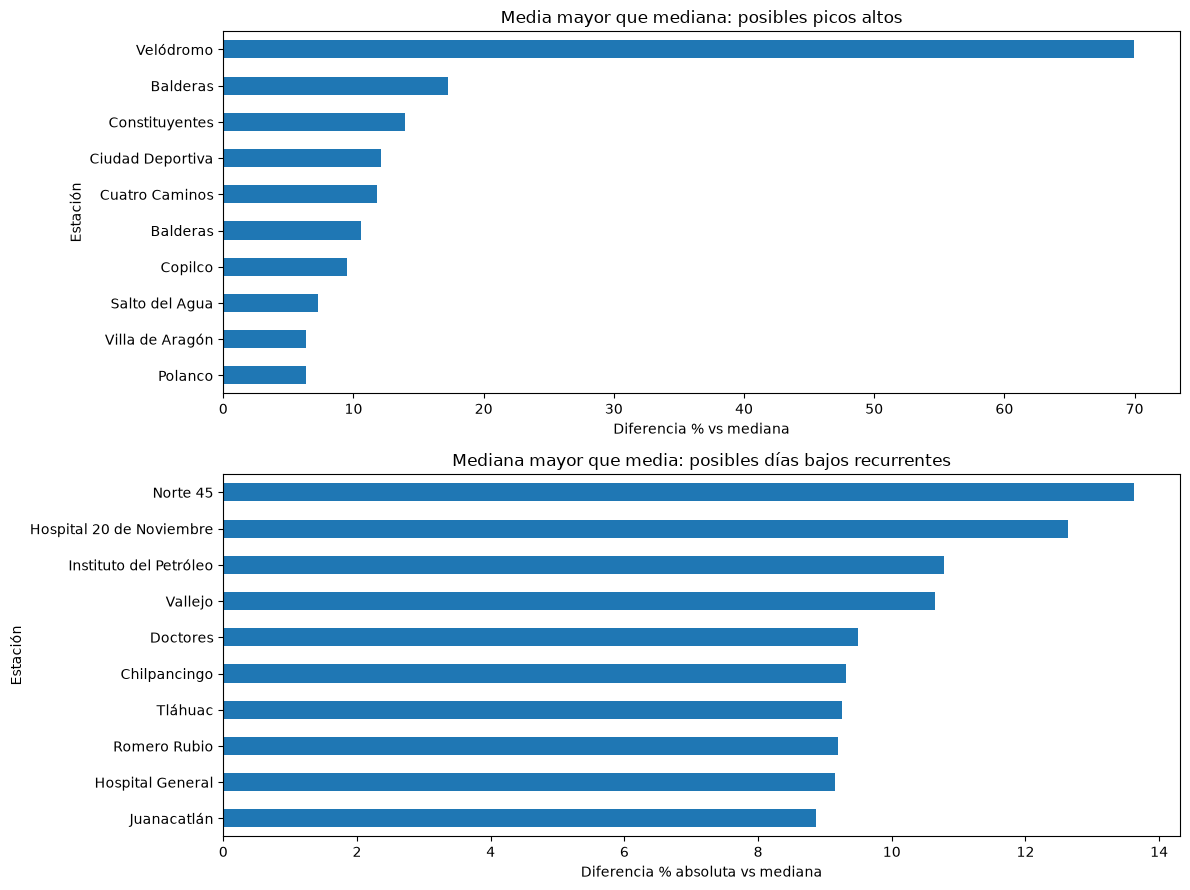

In [240]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

media_mayor_que_mediana.head(10).sort_values('diferencia_pct_vs_mediana').plot(
    kind='barh',
    x='estacion',
    y='diferencia_pct_vs_mediana',
    ax=axes[0],
    legend=False,
)
axes[0].set_title('Media mayor que mediana: posibles picos altos')
axes[0].set_xlabel('Diferencia % vs mediana')
axes[0].set_ylabel('Estación')

mediana_mayor_que_media.head(10).assign(
    diferencia_abs_pct=lambda d: d['diferencia_pct_vs_mediana'].abs()
).sort_values('diferencia_abs_pct').plot(
    kind='barh',
    x='estacion',
    y='diferencia_abs_pct',
    ax=axes[1],
    legend=False,
)
axes[1].set_title('Mediana mayor que media: posibles días bajos recurrentes')
axes[1].set_xlabel('Diferencia % absoluta vs mediana')
axes[1].set_ylabel('Estación')

plt.tight_layout()
plt.show()

**Lectura inicial:** `Velódromo` es el caso más claro de media mayor que mediana, por lo que probablemente tiene picos de demanda en fechas específicas. En cambio, estaciones donde la mediana supera mucho a la media parecen tener varios días bajos que reducen el promedio. Para explicar causalmente esos patrones se requiere cruzar con eventos externos, festivos, calendario escolar o eventos cercanos.

## 17. Festivos de México y afluencia

El PDF pide unir festivos mexicanos. En esta sección se construye una tabla de días festivos oficiales para 2021-2026 y se cruza contra la afluencia.

La idea es revisar tres cosas:

- Si los festivos tienen menor o mayor afluencia que un día normal.
- Si los picos de afluencia coinciden con festivos.
- Si las estaciones donde media y mediana difieren mucho tienen patrones relacionados con festivos.

In [241]:
def primer_lunes(anio, mes):
    fechas = pd.date_range(f'{anio}-{mes:02d}-01', periods=7, freq='D')
    return fechas[fechas.dayofweek == 0][0]

def tercer_lunes(anio, mes):
    fechas = pd.date_range(f'{anio}-{mes:02d}-01', periods=21, freq='D')
    return fechas[fechas.dayofweek == 0][2]

festivos_mexico = []

for anio in range(df_limpio['fecha'].dt.year.min(), df_limpio['fecha'].dt.year.max() + 1):
    festivos_mexico.extend([
        {'fecha': pd.Timestamp(f'{anio}-01-01'), 'festivo': 'Año Nuevo'},
        {'fecha': primer_lunes(anio, 2), 'festivo': 'Constitución Mexicana'},
        {'fecha': tercer_lunes(anio, 3), 'festivo': 'Natalicio Benito Juárez'},
        {'fecha': pd.Timestamp(f'{anio}-05-01'), 'festivo': 'Día del Trabajo'},
        {'fecha': pd.Timestamp(f'{anio}-09-16'), 'festivo': 'Independencia de México'},
        {'fecha': tercer_lunes(anio, 11), 'festivo': 'Revolución Mexicana'},
        {'fecha': pd.Timestamp(f'{anio}-12-25'), 'festivo': 'Navidad'},
    ])

festivos_mexico = pd.DataFrame(festivos_mexico)
festivos_mexico = festivos_mexico[
    festivos_mexico['fecha'].between(df_limpio['fecha'].min(), df_limpio['fecha'].max())
].sort_values('fecha')

festivos_mexico.head(15)

,fecha,festivo
0,2021-01-01,Año Nuevo
1,2021-02-01,Constitución Mexicana
2,2021-03-15,Natalicio Benito Juárez
3,2021-05-01,Día del Trabajo
4,2021-09-16,Independencia de México
5,2021-11-15,Revolución Mexicana
6,2021-12-25,Navidad
7,2022-01-01,Año Nuevo
8,2022-02-07,Constitución Mexicana
9,2022-03-21,Natalicio Benito Juárez


In [242]:
df_limpio = df_limpio.merge(festivos_mexico, on='fecha', how='left')
df_limpio['es_festivo'] = df_limpio['festivo'].notna()
df_limpio['festivo'] = df_limpio['festivo'].fillna('No festivo')

df_calendario = df_limpio.dropna(subset=['afluencia_modelo']).copy()

afluencia_diaria_total_festivos = (
    df_calendario.groupby(['fecha', 'es_festivo', 'festivo'])['afluencia_modelo']
    .sum()
    .reset_index(name='afluencia_diaria')
)

afluencia_diaria_total_festivos['dia_semana'] = afluencia_diaria_total_festivos['fecha'].dt.dayofweek.map(dias_semana)

resumen_festivo_total = (
    afluencia_diaria_total_festivos.groupby('es_festivo')['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

resumen_festivo_total['tipo_dia'] = resumen_festivo_total['es_festivo'].map({False: 'No festivo', True: 'Festivo'})
resumen_festivo_total[['mean', 'median', 'min', 'max']] = resumen_festivo_total[['mean', 'median', 'min', 'max']].round(0)

resumen_festivo_total[['tipo_dia', 'mean', 'median', 'min', 'max', 'count']]

,tipo_dia,mean,median,min,max,count
0,No festivo,3006494.0,3158466.0,524758.0,4890902.0,1968
1,Festivo,1613385.0,1794984.0,723937.0,2694580.0,39


In [243]:
resumen_por_festivo = (
    afluencia_diaria_total_festivos[afluencia_diaria_total_festivos['es_festivo']]
    .groupby('festivo')['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

resumen_por_festivo[['mean', 'median', 'min', 'max']] = resumen_por_festivo[['mean', 'median', 'min', 'max']].round(0)
resumen_por_festivo

,festivo,mean,median,min,max,count
0,Revolución Mexicana,2119956.0,1939114.0,1897016.0,2694580.0,5
1,Día del Trabajo,2042528.0,2071492.0,1784306.0,2368167.0,6
2,Natalicio Benito Juárez,1817030.0,1825914.0,1476790.0,2002770.0,6
3,Constitución Mexicana,1733812.0,1834776.0,1092202.0,1965346.0,6
4,Independencia de México,1498376.0,1511416.0,1245658.0,1667392.0,5
5,Navidad,1077049.0,1085554.0,1022377.0,1135706.0,5
6,Año Nuevo,980818.0,1013059.0,723937.0,1111885.0,6


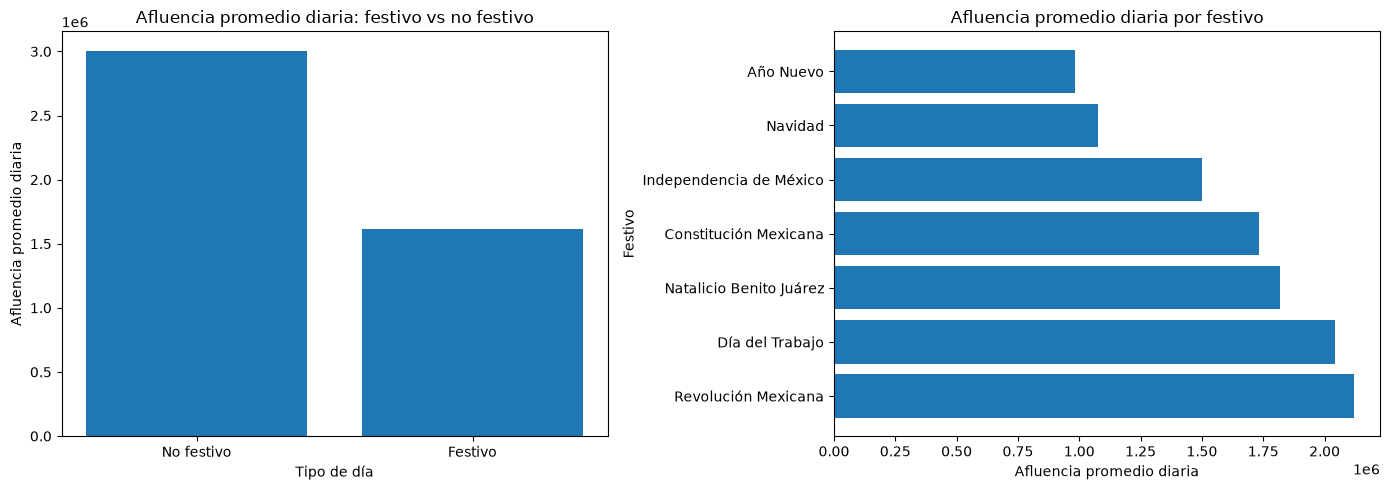

In [244]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(resumen_festivo_total['tipo_dia'], resumen_festivo_total['mean'])
axes[0].set_title('Afluencia promedio diaria: festivo vs no festivo')
axes[0].set_xlabel('Tipo de día')
axes[0].set_ylabel('Afluencia promedio diaria')

axes[1].barh(resumen_por_festivo['festivo'], resumen_por_festivo['mean'])
axes[1].set_title('Afluencia promedio diaria por festivo')
axes[1].set_xlabel('Afluencia promedio diaria')
axes[1].set_ylabel('Festivo')

plt.tight_layout()
plt.show()

Ahora revisamos si los días con mayor afluencia total coinciden con festivos. Si los picos no son festivos, pueden deberse más a días laborales, regreso a actividades, eventos locales o patrones de movilidad ordinaria.

In [245]:
top_dias_afluencia_total = afluencia_diaria_total_festivos.sort_values(
    'afluencia_diaria', ascending=False
).head(30)

top_dias_baja_afluencia_total = afluencia_diaria_total_festivos.sort_values(
    'afluencia_diaria', ascending=True
).head(30)

top_dias_afluencia_total

,fecha,es_festivo,festivo,afluencia_diaria,dia_semana
1792,2025-11-28,False,No festivo,4890902.0,Viernes
1778,2025-11-14,False,No festivo,4890645.0,Viernes
1785,2025-11-21,False,No festivo,4756221.0,Viernes
1783,2025-11-19,False,No festivo,4748450.0,Miércoles
1776,2025-11-12,False,No festivo,4746750.0,Miércoles
1777,2025-11-13,False,No festivo,4737230.0,Jueves
1769,2025-11-05,False,No festivo,4716631.0,Miércoles
1790,2025-11-26,False,No festivo,4710848.0,Miércoles
1771,2025-11-07,False,No festivo,4703468.0,Viernes
1770,2025-11-06,False,No festivo,4665274.0,Jueves


In [246]:
top_dias_baja_afluencia_total

,fecha,es_festivo,festivo,afluencia_diaria,dia_semana
9,2021-01-10,False,No festivo,524758.0,Domingo
16,2021-01-17,False,No festivo,632192.0,Domingo
23,2021-01-24,False,No festivo,636673.0,Domingo
0,2021-01-01,True,Año Nuevo,723937.0,Viernes
30,2021-01-31,False,No festivo,789161.0,Domingo
37,2021-02-07,False,No festivo,859507.0,Domingo
8,2021-01-09,False,No festivo,940652.0,Sábado
1095,2024-01-01,True,Año Nuevo,987685.0,Lunes
1461,2025-01-01,True,Año Nuevo,1010058.0,Miércoles
1826,2026-01-01,True,Año Nuevo,1016060.0,Jueves


También analizamos estaciones atípicas contra festivos: las que tienen media mucho mayor que mediana y las que tienen mediana mucho mayor que media.

In [247]:
estaciones_extremas_media_mediana = pd.concat([
    media_mayor_que_mediana.head(10).assign(tipo_diferencia='Media mayor que mediana'),
    mediana_mayor_que_media.head(10).assign(tipo_diferencia='Mediana mayor que media'),
], ignore_index=True)[['linea', 'estacion', 'tipo_diferencia']].drop_duplicates()

afluencia_estacion_dia_festivos = afluencia_estacion_dia.merge(
    festivos_mexico,
    on='fecha',
    how='left',
)
afluencia_estacion_dia_festivos['es_festivo'] = afluencia_estacion_dia_festivos['festivo'].notna()
afluencia_estacion_dia_festivos['festivo'] = afluencia_estacion_dia_festivos['festivo'].fillna('No festivo')

afluencia_estacion_dia_festivos = afluencia_estacion_dia_festivos.merge(
    estaciones_extremas_media_mediana,
    on=['linea', 'estacion'],
    how='inner',
)

comparacion_festivos_estaciones_extremas = (
    afluencia_estacion_dia_festivos.groupby(['tipo_diferencia', 'linea', 'estacion', 'es_festivo'])['afluencia_estacion_dia']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

comparacion_festivos_estaciones_extremas['tipo_dia'] = comparacion_festivos_estaciones_extremas['es_festivo'].map({False: 'No festivo', True: 'Festivo'})
comparacion_festivos_estaciones_extremas[['mean', 'median', 'min', 'max']] = comparacion_festivos_estaciones_extremas[['mean', 'median', 'min', 'max']].round(0)

comparacion_festivos_estaciones_extremas.sort_values(['tipo_diferencia', 'linea', 'estacion', 'es_festivo'])

,tipo_diferencia,linea,estacion,es_festivo,mean,median,min,max,count,tipo_dia
0,Media mayor que mediana,Línea 1,Balderas,False,18047.0,16288.0,2841.0,44117.0,1648,No festivo
1,Media mayor que mediana,Línea 1,Balderas,True,7681.0,6384.0,2676.0,19784.0,33,Festivo
2,Media mayor que mediana,Línea 2,Cuatro Caminos,False,70501.0,63148.0,161.0,133127.0,1938,No festivo
3,Media mayor que mediana,Línea 2,Cuatro Caminos,True,37548.0,33106.0,14346.0,72430.0,38,Festivo
4,Media mayor que mediana,Línea 3,Balderas,False,13196.0,11274.0,554.0,36933.0,1945,No festivo
5,Media mayor que mediana,Línea 3,Balderas,True,6857.0,4554.0,658.0,22637.0,39,Festivo
6,Media mayor que mediana,Línea 3,Copilco,False,27319.0,25026.0,2890.0,54870.0,1945,No festivo
7,Media mayor que mediana,Línea 3,Copilco,True,9798.0,9732.0,4307.0,17325.0,39,Festivo
8,Media mayor que mediana,Línea 7,Constituyentes,False,8432.0,7432.0,792.0,27889.0,1968,No festivo
9,Media mayor que mediana,Línea 7,Constituyentes,True,4014.0,3661.0,455.0,9074.0,39,Festivo


In [248]:
fechas_altas_extremas = (
    afluencia_estacion_dia_festivos.sort_values('afluencia_estacion_dia', ascending=False)
    .groupby(['tipo_diferencia', 'linea', 'estacion'])
    .head(5)
    .sort_values(['tipo_diferencia', 'linea', 'estacion', 'afluencia_estacion_dia'], ascending=[True, True, True, False])
)

fechas_altas_extremas[['tipo_diferencia', 'fecha', 'linea', 'estacion', 'afluencia_estacion_dia', 'es_festivo', 'festivo']]

,tipo_diferencia,fecha,linea,estacion,afluencia_estacion_dia,es_festivo,festivo
12672,Media mayor que mediana,2022-12-01,Línea 1,Balderas,44117.0,False,No festivo
18745,Media mayor que mediana,2023-10-19,Línea 1,Balderas,38733.0,False,No festivo
17947,Media mayor que mediana,2023-09-07,Línea 1,Balderas,38372.0,False,No festivo
15401,Media mayor que mediana,2023-04-26,Línea 1,Balderas,37826.0,False,No festivo
14090,Media mayor que mediana,2023-02-16,Línea 1,Balderas,37731.0,False,No festivo
32499,Media mayor que mediana,2025-11-14,Línea 2,Cuatro Caminos,133127.0,False,No festivo
32778,Media mayor que mediana,2025-11-28,Línea 2,Cuatro Caminos,131327.0,False,No festivo
32638,Media mayor que mediana,2025-11-21,Línea 2,Cuatro Caminos,129439.0,False,No festivo
32366,Media mayor que mediana,2025-11-07,Línea 2,Cuatro Caminos,129012.0,False,No festivo
32480,Media mayor que mediana,2025-11-13,Línea 2,Cuatro Caminos,127415.0,False,No festivo


**Lectura inicial:** los festivos suelen tener menor afluencia que los días no festivos. Si los picos de estaciones atípicas no caen en festivos, entonces probablemente se deben a eventos locales, patrones laborales/escolares o demanda ordinaria en días específicos. Esto ayuda a separar efectos de calendario nacional de efectos locales de cada estación.

## 18. Clima diario en CDMX

El PDF pide unir clima diario y auditar si aporta información. Para hacerlo de forma reproducible se usa la API histórica de Open-Meteo, que permite descargar variables diarias sin API key.

Referencia: Open-Meteo Historical Weather API, endpoint `/v1/archive`, con variables diarias como temperatura media, precipitación, horas de lluvia y viento.

Coordenadas usadas para CDMX centro: latitud `19.4326`, longitud `-99.1332`.

In [249]:
from http.client import IncompleteRead
from urllib.error import URLError
from urllib.parse import urlencode
from urllib.request import urlopen
import json
import time

ruta_clima = ruta_csv.parent / 'clima_cdmx_open_meteo_2021_2026.csv'

variables_clima = [
    'temperature_2m_mean',
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum',
    'rain_sum',
    'precipitation_hours',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'weather_code',
]

def descargar_json_con_reintentos(url, reintentos=5, espera_segundos=3):
    for intento in range(1, reintentos + 1):
        try:
            with urlopen(url, timeout=60) as respuesta:
                contenido = respuesta.read()
            return json.loads(contenido.decode('utf-8'))
        except (IncompleteRead, URLError, TimeoutError, ConnectionError) as error:
            if intento == reintentos:
                raise RuntimeError(
                    'No se pudo descargar el clima después de varios intentos. '
                    'Vuelve a ejecutar esta celda o revisa tu conexión.'
                ) from error

            print(f'Intento {intento} falló al descargar clima: {error}. Reintentando...')
            time.sleep(espera_segundos)


if ruta_clima.exists():
    clima_cdmx = pd.read_csv(ruta_clima)
else:
    parametros = {
        'latitude': 19.4326,
        'longitude': -99.1332,
        'start_date': df_limpio['fecha'].min().strftime('%Y-%m-%d'),
        'end_date': df_limpio['fecha'].max().strftime('%Y-%m-%d'),
        'daily': ','.join(variables_clima),
        'timezone': 'America/Mexico_City',
    }

    url_clima = 'https://archive-api.open-meteo.com/v1/archive?' + urlencode(parametros)

    datos_clima = descargar_json_con_reintentos(url_clima)

    clima_cdmx = pd.DataFrame(datos_clima['daily'])
    clima_cdmx.to_csv(ruta_clima, index=False)

clima_cdmx['fecha'] = pd.to_datetime(clima_cdmx['time'])
clima_cdmx = clima_cdmx.drop(columns=['time'])

print(f'Filas de clima diario: {len(clima_cdmx):,}')
clima_cdmx.head()

Filas de clima diario: 2,007


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,weather_code,fecha
0,12.1,24.4,1.2,0.0,0.0,0.0,22.0,40.7,2,2021-01-01
1,12.8,24.1,3.7,0.0,0.0,0.0,22.3,38.9,0,2021-01-02
2,13.5,24.3,3.0,0.0,0.0,0.0,24.0,40.3,3,2021-01-03
3,14.9,23.0,6.6,0.0,0.0,0.0,20.1,29.5,1,2021-01-04
4,14.3,22.7,6.9,0.0,0.0,0.0,20.0,32.0,2,2021-01-05


In [250]:
columnas_clima = [col for col in clima_cdmx.columns if col != 'fecha']

df_limpio = df_limpio.drop(columns=columnas_clima, errors='ignore')
df_limpio = df_limpio.merge(clima_cdmx, on='fecha', how='left')

df_limpio['llovio'] = df_limpio['precipitation_sum'].gt(0)
df_limpio['lluvia_fuerte'] = df_limpio['precipitation_sum'].ge(10)

resumen_union_clima = pd.DataFrame({
    'filas_df_limpio': [len(df_limpio)],
    'fechas_unicas_df_limpio': [df_limpio['fecha'].nunique()],
    'fechas_unicas_clima': [clima_cdmx['fecha'].nunique()],
    'filas_sin_clima': [df_limpio[columnas_clima].isna().any(axis=1).sum()],
})

resumen_union_clima

,filas_df_limpio,fechas_unicas_df_limpio,fechas_unicas_clima,filas_sin_clima
0,1174095,2007,2007,0


Primero revisamos si el clima se relaciona con la afluencia total diaria. Esto no prueba causalidad, pero ayuda a decidir si vale la pena conservar estas variables para el modelo.

In [251]:
afluencia_diaria_clima = (
    df_limpio.dropna(subset=['afluencia_modelo'])
    .groupby('fecha')
    .agg(
        afluencia_diaria=('afluencia_modelo', 'sum'),
        temperature_2m_mean=('temperature_2m_mean', 'first'),
        temperature_2m_max=('temperature_2m_max', 'first'),
        temperature_2m_min=('temperature_2m_min', 'first'),
        precipitation_sum=('precipitation_sum', 'first'),
        rain_sum=('rain_sum', 'first'),
        precipitation_hours=('precipitation_hours', 'first'),
        wind_speed_10m_max=('wind_speed_10m_max', 'first'),
        wind_gusts_10m_max=('wind_gusts_10m_max', 'first'),
        es_festivo=('es_festivo', 'first'),
        es_fin_semana=('es_fin_semana', 'first'),
    )
    .reset_index()
)

afluencia_diaria_clima['llovio'] = afluencia_diaria_clima['precipitation_sum'].gt(0)
afluencia_diaria_clima['lluvia_fuerte'] = afluencia_diaria_clima['precipitation_sum'].ge(10)

correlacion_clima_afluencia = (
    afluencia_diaria_clima[
        ['afluencia_diaria'] + variables_clima[:-1]
    ]
    .corr(numeric_only=True)['afluencia_diaria']
    .drop('afluencia_diaria')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)

correlacion_clima_afluencia.columns = ['variable_clima', 'correlacion_con_afluencia_diaria']
correlacion_clima_afluencia

,variable_clima,correlacion_con_afluencia_diaria
0,wind_speed_10m_max,-0.171486
1,temperature_2m_min,0.126578
2,temperature_2m_mean,0.111831
3,temperature_2m_max,0.059048
4,precipitation_hours,-0.014586
5,precipitation_sum,-0.013601
6,rain_sum,-0.013601
7,wind_gusts_10m_max,-0.001118


In [252]:
resumen_lluvia_afluencia = (
    afluencia_diaria_clima.groupby('llovio')['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

resumen_lluvia_afluencia['tipo_dia'] = resumen_lluvia_afluencia['llovio'].map({False: 'Sin lluvia', True: 'Con lluvia'})
resumen_lluvia_afluencia[['mean', 'median', 'min', 'max']] = resumen_lluvia_afluencia[['mean', 'median', 'min', 'max']].round(0)

resumen_lluvia_afluencia[['tipo_dia', 'mean', 'median', 'min', 'max', 'count']]

,tipo_dia,mean,median,min,max,count
0,Sin lluvia,2993868.0,3135094.0,524758.0,4890645.0,866
1,Con lluvia,2968460.0,3110813.0,632192.0,4890902.0,1141


In [253]:
resumen_lluvia_fuerte_afluencia = (
    afluencia_diaria_clima.groupby('lluvia_fuerte')['afluencia_diaria']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

resumen_lluvia_fuerte_afluencia['tipo_dia'] = resumen_lluvia_fuerte_afluencia['lluvia_fuerte'].map({False: 'Sin lluvia fuerte', True: 'Lluvia >= 10 mm'})
resumen_lluvia_fuerte_afluencia[['mean', 'median', 'min', 'max']] = resumen_lluvia_fuerte_afluencia[['mean', 'median', 'min', 'max']].round(0)

resumen_lluvia_fuerte_afluencia[['tipo_dia', 'mean', 'median', 'min', 'max', 'count']]

,tipo_dia,mean,median,min,max,count
0,Sin lluvia fuerte,2975367.0,3114791.0,524758.0,4890902.0,1773
1,Lluvia >= 10 mm,3010153.0,3207992.0,1245658.0,4217101.0,234


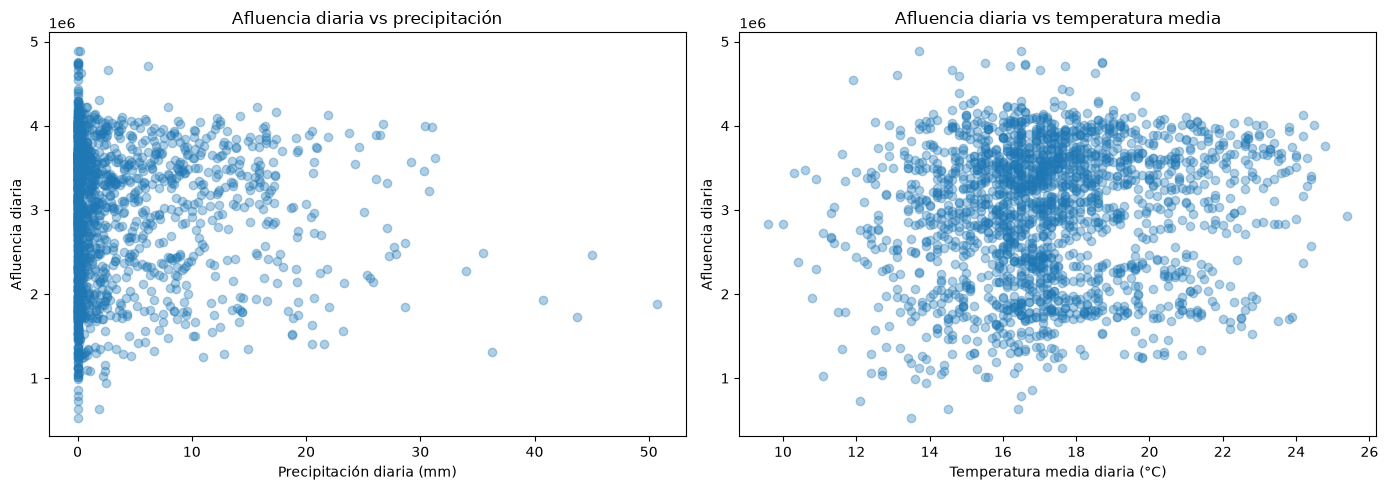

In [254]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    afluencia_diaria_clima['precipitation_sum'],
    afluencia_diaria_clima['afluencia_diaria'],
    alpha=0.35,
)
axes[0].set_title('Afluencia diaria vs precipitación')
axes[0].set_xlabel('Precipitación diaria (mm)')
axes[0].set_ylabel('Afluencia diaria')

axes[1].scatter(
    afluencia_diaria_clima['temperature_2m_mean'],
    afluencia_diaria_clima['afluencia_diaria'],
    alpha=0.35,
)
axes[1].set_title('Afluencia diaria vs temperatura media')
axes[1].set_xlabel('Temperatura media diaria (°C)')
axes[1].set_ylabel('Afluencia diaria')

plt.tight_layout()
plt.show()

Finalmente revisamos si las estaciones atípicas de media/mediana también tienen picos en días de lluvia. Esto ayuda a distinguir entre picos por clima y picos por eventos locales.

In [255]:
afluencia_estacion_dia_clima = afluencia_estacion_dia.merge(
    clima_cdmx,
    on='fecha',
    how='left',
)
afluencia_estacion_dia_clima['llovio'] = afluencia_estacion_dia_clima['precipitation_sum'].gt(0)
afluencia_estacion_dia_clima['lluvia_fuerte'] = afluencia_estacion_dia_clima['precipitation_sum'].ge(10)

afluencia_estacion_dia_clima_extremas = afluencia_estacion_dia_clima.merge(
    estaciones_extremas_media_mediana,
    on=['linea', 'estacion'],
    how='inner',
)

comparacion_clima_estaciones_extremas = (
    afluencia_estacion_dia_clima_extremas.groupby(['tipo_diferencia', 'linea', 'estacion', 'lluvia_fuerte'])['afluencia_estacion_dia']
    .agg(['mean', 'median', 'min', 'max', 'count'])
    .reset_index()
)

comparacion_clima_estaciones_extremas['tipo_lluvia'] = comparacion_clima_estaciones_extremas['lluvia_fuerte'].map({False: 'Sin lluvia fuerte', True: 'Lluvia >= 10 mm'})
comparacion_clima_estaciones_extremas[['mean', 'median', 'min', 'max']] = comparacion_clima_estaciones_extremas[['mean', 'median', 'min', 'max']].round(0)

comparacion_clima_estaciones_extremas.sort_values(['tipo_diferencia', 'linea', 'estacion', 'lluvia_fuerte'])

,tipo_diferencia,linea,estacion,lluvia_fuerte,mean,median,min,max,count,tipo_lluvia
0,Media mayor que mediana,Línea 1,Balderas,False,17952.0,16175.0,2676.0,44117.0,1483,Sin lluvia fuerte
1,Media mayor que mediana,Línea 1,Balderas,True,17029.0,16092.0,2841.0,36870.0,198,Lluvia >= 10 mm
2,Media mayor que mediana,Línea 2,Cuatro Caminos,False,69405.0,62288.0,161.0,133127.0,1742,Sin lluvia fuerte
3,Media mayor que mediana,Línea 2,Cuatro Caminos,True,73308.0,65154.0,898.0,116213.0,234,Lluvia >= 10 mm
4,Media mayor que mediana,Línea 3,Balderas,False,13172.0,11273.0,554.0,36933.0,1750,Sin lluvia fuerte
5,Media mayor que mediana,Línea 3,Balderas,True,12316.0,10847.0,870.0,36448.0,234,Lluvia >= 10 mm
6,Media mayor que mediana,Línea 3,Copilco,False,27102.0,24728.0,2890.0,54870.0,1750,Sin lluvia fuerte
7,Media mayor que mediana,Línea 3,Copilco,True,26029.0,23725.0,5657.0,53550.0,234,Lluvia >= 10 mm
8,Media mayor que mediana,Línea 7,Constituyentes,False,8367.0,7314.0,455.0,27889.0,1773,Sin lluvia fuerte
9,Media mayor que mediana,Línea 7,Constituyentes,True,8189.0,7723.0,1203.0,16005.0,234,Lluvia >= 10 mm


In [256]:
top_dias_lluvia = afluencia_diaria_clima.sort_values('precipitation_sum', ascending=False).head(20)
top_dias_lluvia[['fecha', 'afluencia_diaria', 'precipitation_sum', 'precipitation_hours', 'temperature_2m_mean', 'es_festivo', 'es_fin_semana']]

,fecha,afluencia_diaria,precipitation_sum,precipitation_hours,temperature_2m_mean,es_festivo,es_fin_semana
1640,2025-06-29,1885660.0,50.7,18.0,16.4,False,True
249,2021-09-07,2458585.0,45.0,20.0,15.8,False,False
1276,2024-06-30,1731107.0,43.7,16.0,16.9,False,True
232,2021-08-21,1923853.0,40.7,19.0,15.7,False,True
163,2021-06-13,1314255.0,36.3,21.0,16.4,False,True
248,2021-09-06,2481541.0,35.5,22.0,15.9,False,False
153,2021-06-03,2276156.0,34.0,16.0,16.6,False,False
1323,2024-08-16,3616957.0,31.3,10.0,16.8,False,False
1741,2025-10-08,3990030.0,31.0,18.0,14.6,False,False
1277,2024-07-01,3220346.0,30.8,17.0,16.6,False,False


**Lectura inicial:** si las correlaciones con clima son bajas, eso no significa que el clima sea inútil: puede aportar en modelos no lineales o en interacción con día de semana, festivos y línea. Para el reporte se debe documentar si la señal es fuerte, débil o principalmente indirecta.

## 19. Dataset transformado y decisión sobre ceros

Varias columnas creadas durante el ETL sirven para **auditoría** y otras para **modelado**.

Decisión sobre los ceros:

- Los ceros parciales por `tipo_pago` se conservan como 0 porque la estación sí tuvo afluencia ese día.
- Los ceros totales de estación-día no se interpretan como demanda baja. Se consideran valores no comparables o ausentes para modelado.
- No se borran del dataset transformado, porque son evidencia de calidad de datos y sirven para el experimento de structural breaks.
- Para entrenar modelos se usa `afluencia_modelo`, donde esos ceros totales ya quedaron como `NaN`, y se crea una versión modelable sin esos registros.

Esto permite tener dos capas: una base transformada completa y una base lista para modelado.

In [257]:
columnas_transformadas = [
    # Llave y columnas originales limpias
    'fecha', 'mes', 'anio', 'linea', 'estacion', 'tipo_pago', 'afluencia',

    # Target transformado por decisiones ETL
    'afluencia_modelo',

    # Banderas de calidad / structural breaks
    'afluencia_total_dia',
    'cero_total_estacion_dia',
    'cero_parcial_tipo_pago',
    'cero_total_sin_evento',
    'structural_break_metro',
    'evento_estructural',

    # Features calendario
    'dia_semana_num',
    'dia_semana',
    'es_fin_semana',
    'numero_mes',
    'nombre_mes',
    'anio_mes',
    'es_festivo',
    'festivo',

    # Features clima
    'temperature_2m_mean',
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum',
    'rain_sum',
    'precipitation_hours',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'weather_code',
    'llovio',
    'lluvia_fuerte',
]

columnas_transformadas = [col for col in columnas_transformadas if col in df_limpio.columns]

df_transformado = df_limpio[columnas_transformadas].copy()
df_modelo_desglosado = df_transformado.dropna(subset=['afluencia_modelo']).copy()

resumen_dataset_transformado = pd.DataFrame({
    'dataset': ['df_transformado', 'df_modelo_desglosado'],
    'descripcion': [
        'Base completa con auditoría y decisiones ETL',
        'Base sin ceros totales no modelables, lista para modelar por tipo_pago',
    ],
    'filas': [len(df_transformado), len(df_modelo_desglosado)],
    'columnas': [df_transformado.shape[1], df_modelo_desglosado.shape[1]],
    'nulos_afluencia_modelo': [
        df_transformado['afluencia_modelo'].isna().sum(),
        df_modelo_desglosado['afluencia_modelo'].isna().sum(),
    ],
})

resumen_dataset_transformado

,dataset,descripcion,filas,columnas,nulos_afluencia_modelo
0,df_transformado,Base completa con auditoría y decisiones ETL,1174095,33,89220
1,df_modelo_desglosado,"Base sin ceros totales no modelables, lista pa...",1084875,33,0


Además del dataset desglosado por `tipo_pago`, creamos una versión agregada por estación-día. Esta versión predice demanda total de la estación y evita que el modelo aprenda solo la distribución contable entre tipos de pago.

In [258]:
columnas_agregacion = [
    'fecha', 'linea', 'estacion',
    'dia_semana_num', 'dia_semana', 'es_fin_semana', 'numero_mes', 'nombre_mes', 'anio_mes',
    'es_festivo', 'festivo',
    'structural_break_metro', 'evento_estructural', 'cero_total_estacion_dia', 'cero_total_sin_evento',
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'rain_sum', 'precipitation_hours',
    'wind_speed_10m_max', 'wind_gusts_10m_max', 'weather_code', 'llovio', 'lluvia_fuerte',
]
columnas_agregacion = [col for col in columnas_agregacion if col in df_modelo_desglosado.columns]

df_modelo_desglosado_para_agregar = df_modelo_desglosado.copy()

if 'evento_estructural' in df_modelo_desglosado_para_agregar.columns:
    df_modelo_desglosado_para_agregar['evento_estructural'] = (
        df_modelo_desglosado_para_agregar['evento_estructural'].fillna('Sin evento')
    )

if 'nombre_mes' in df_modelo_desglosado_para_agregar.columns:
    df_modelo_desglosado_para_agregar['nombre_mes'] = df_modelo_desglosado_para_agregar['nombre_mes'].astype(str)

df_modelo_agregado_estacion = (
    df_modelo_desglosado_para_agregar.pivot_table(
        index=columnas_agregacion,
        columns='tipo_pago',
        values='afluencia_modelo',
        aggfunc='sum',
        fill_value=0,
        observed=True,
    )
    .reset_index()
)

df_modelo_agregado_estacion.columns.name = None
df_modelo_agregado_estacion = df_modelo_agregado_estacion.rename(columns={
    'Boleto': 'afluencia_boleto',
    'Prepago': 'afluencia_prepago',
    'Gratuidad': 'afluencia_gratuidad',
})

for columna_pago in ['afluencia_boleto', 'afluencia_prepago', 'afluencia_gratuidad']:
    if columna_pago not in df_modelo_agregado_estacion.columns:
        df_modelo_agregado_estacion[columna_pago] = 0

df_modelo_agregado_estacion['afluencia_total_modelo'] = df_modelo_agregado_estacion[
    ['afluencia_boleto', 'afluencia_prepago', 'afluencia_gratuidad']
].sum(axis=1)

resumen_modelo_agregado = pd.DataFrame({
    'dataset': ['df_modelo_agregado_estacion'],
    'descripcion': ['Base agregada por fecha + linea + estacion'],
    'filas': [len(df_modelo_agregado_estacion)],
    'columnas': [df_modelo_agregado_estacion.shape[1]],
    'target': ['afluencia_total_modelo'],
})

resumen_modelo_agregado

,dataset,descripcion,filas,columnas,target
0,df_modelo_agregado_estacion,Base agregada por fecha + linea + estacion,361625,30,afluencia_total_modelo


Guardamos los datasets transformados. El PDF pide reportar el tamaño antes y después.

In [259]:
ruta_transformado = ruta_csv.parent / 'metro_cdmx_transformado.csv'
ruta_modelo_desglosado = ruta_csv.parent / 'metro_cdmx_modelo_desglosado.csv'
ruta_modelo_agregado = ruta_csv.parent / 'metro_cdmx_modelo_agregado_estacion.csv'

df_transformado.to_csv(ruta_transformado, index=False)
df_modelo_desglosado.to_csv(ruta_modelo_desglosado, index=False)
df_modelo_agregado_estacion.to_csv(ruta_modelo_agregado, index=False)

tamanios_archivos = pd.DataFrame([
    {
        'archivo': ruta_csv.name,
        'tipo': 'Original',
        'filas': len(df),
        'columnas': df.shape[1],
        'tamano_mb': ruta_csv.stat().st_size / (1024 ** 2),
    },
    {
        'archivo': ruta_transformado.name,
        'tipo': 'Transformado completo',
        'filas': len(df_transformado),
        'columnas': df_transformado.shape[1],
        'tamano_mb': ruta_transformado.stat().st_size / (1024 ** 2),
    },
    {
        'archivo': ruta_modelo_desglosado.name,
        'tipo': 'Modelado desglosado',
        'filas': len(df_modelo_desglosado),
        'columnas': df_modelo_desglosado.shape[1],
        'tamano_mb': ruta_modelo_desglosado.stat().st_size / (1024 ** 2),
    },
    {
        'archivo': ruta_modelo_agregado.name,
        'tipo': 'Modelado agregado estación-día',
        'filas': len(df_modelo_agregado_estacion),
        'columnas': df_modelo_agregado_estacion.shape[1],
        'tamano_mb': ruta_modelo_agregado.stat().st_size / (1024 ** 2),
    },
])

tamanios_archivos['tamano_mb'] = tamanios_archivos['tamano_mb'].round(2)
tamanios_archivos

,archivo,tipo,filas,columnas,tamano_mb
0,afluenciastc_desglosado_06_2026.csv,Original,1174095,7,65.69
1,metro_cdmx_transformado.csv,Transformado completo,1174095,33,224.32
2,metro_cdmx_modelo_desglosado.csv,Modelado desglosado,1084875,33,206.49
3,metro_cdmx_modelo_agregado_estacion.csv,Modelado agregado estación-día,361625,30,66.37


**Decisión para los datos con ceros totales:** no se eliminan del archivo transformado completo. Se conservan con banderas para documentación y experimentos. Para modelado, quedan excluidos de `df_modelo_desglosado` y `df_modelo_agregado_estacion` porque `afluencia_modelo` los convirtió en ausentes antes de construir esas bases.

## 20. Preparación para modelado: target, split, encoding y scaling

Antes de entrenar modelos se revisa el target y se preparan transformaciones de variables. Muy importante: cualquier transformación que aprenda parámetros de los datos debe ajustarse **solo con train** y después aplicarse a test.

Para el modelo principal usaremos la base agregada por `fecha + linea + estacion`, porque predice demanda total de la estación y evita que el modelo aprenda solo relaciones contables entre tipos de pago.

Target principal: `afluencia_total_modelo`.

In [260]:
df_modelado = df_modelo_agregado_estacion.copy()

target_modelo = 'afluencia_total_modelo'

columnas_fuga_target = [
    'afluencia_boleto',
    'afluencia_prepago',
    'afluencia_gratuidad',
    target_modelo,
]

print(f'Filas para modelado: {len(df_modelado):,}')
print(f'Columnas disponibles: {df_modelado.shape[1]:,}')
print('Columnas que NO deben usarse como predictores por fuga del target:')
display(columnas_fuga_target)

df_modelado.head()

Filas para modelado: 361,625
Columnas disponibles: 30
Columnas que NO deben usarse como predictores por fuga del target:


['afluencia_boleto',
 'afluencia_prepago',
 'afluencia_gratuidad',
 'afluencia_total_modelo']

,fecha,linea,estacion,dia_semana_num,dia_semana,es_fin_semana,numero_mes,nombre_mes,anio_mes,es_festivo,festivo,structural_break_metro,evento_estructural,cero_total_estacion_dia,cero_total_sin_evento,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,weather_code,llovio,lluvia_fuerte,afluencia_boleto,afluencia_gratuidad,afluencia_prepago,afluencia_total_modelo
0,2021-01-01,Línea 1,Balbuena,4,Viernes,False,1,Enero,2021-01,True,Año Nuevo,False,Sin evento,False,False,12.1,24.4,1.2,0.0,0.0,0.0,22.0,40.7,2,False,False,1848.0,325.0,790.0,2963.0
1,2021-01-01,Línea 1,Balderas,4,Viernes,False,1,Enero,2021-01,True,Año Nuevo,False,Sin evento,False,False,12.1,24.4,1.2,0.0,0.0,0.0,22.0,40.7,2,False,False,1103.0,651.0,922.0,2676.0
2,2021-01-01,Línea 1,Boulevard Puerto Aéreo,4,Viernes,False,1,Enero,2021-01,True,Año Nuevo,False,Sin evento,False,False,12.1,24.4,1.2,0.0,0.0,0.0,22.0,40.7,2,False,False,4890.0,1053.0,2797.0,8740.0
3,2021-01-01,Línea 1,Candelaria,4,Viernes,False,1,Enero,2021-01,True,Año Nuevo,False,Sin evento,False,False,12.1,24.4,1.2,0.0,0.0,0.0,22.0,40.7,2,False,False,0.0,1127.0,1605.0,2732.0
4,2021-01-01,Línea 1,Chapultepec,4,Viernes,False,1,Enero,2021-01,True,Año Nuevo,False,Sin evento,False,False,12.1,24.4,1.2,0.0,0.0,0.0,22.0,40.7,2,False,False,4480.0,162.0,2942.0,7584.0


### 20.1 Features temporales con memoria histórica

Además de calendario, agregamos variables que le dicen al modelo cómo venía comportándose cada estación en el pasado.

- `time_idx`: número de días desde el inicio de la base.
- `lag_7`: afluencia de la misma estación hace 7 días.
- `lag_14`: afluencia de la misma estación hace 14 días.
- `rolling_mean_7`: promedio de los 7 días previos.
- `rolling_mean_28`: promedio de los 28 días previos.

Estas variables se calculan con `shift`, por lo que usan solo información pasada. No usan datos del futuro.

In [261]:
df_modelado = df_modelado.sort_values(['linea', 'estacion', 'fecha']).copy()

df_modelado['time_idx'] = (
    df_modelado['fecha'] - df_modelado['fecha'].min()
).dt.days

grupo_estacion = df_modelado.groupby(['linea', 'estacion'])[target_modelo]

df_modelado['lag_7'] = grupo_estacion.shift(7)
df_modelado['lag_14'] = grupo_estacion.shift(14)
df_modelado['lag_28'] = grupo_estacion.shift(28)

df_modelado['rolling_mean_7'] = grupo_estacion.transform(
    lambda s: s.shift(1).rolling(window=7, min_periods=3).mean()
)
df_modelado['rolling_mean_28'] = grupo_estacion.transform(
    lambda s: s.shift(1).rolling(window=28, min_periods=7).mean()
)

features_temporales = ['time_idx', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']

resumen_features_temporales = pd.DataFrame({
    'feature': features_temporales,
    'nulos': [df_modelado[col].isna().sum() for col in features_temporales],
    'pct_nulos': [(df_modelado[col].isna().mean() * 100).round(2) for col in features_temporales],
})

resumen_features_temporales

,feature,nulos,pct_nulos
0,time_idx,0,0.00
1,lag_7,1365,0.38
2,lag_14,2730,0.75
3,lag_28,5460,1.51
4,rolling_mean_7,585,0.16
5,rolling_mean_28,1365,0.38


In [262]:
df_modelado_lags = df_modelado.dropna(subset=['lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']).copy()

resumen_modelado_lags = pd.DataFrame({
    'dataset': ['df_modelado', 'df_modelado_lags'],
    'descripcion': [
        'Base agregada antes de quitar nulos de lags',
        'Base agregada con features temporales completas',
    ],
    'filas': [len(df_modelado), len(df_modelado_lags)],
    'fecha_min': [df_modelado['fecha'].min(), df_modelado_lags['fecha'].min()],
    'fecha_max': [df_modelado['fecha'].max(), df_modelado_lags['fecha'].max()],
})

resumen_modelado_lags

,dataset,descripcion,filas,fecha_min,fecha_max
0,df_modelado,Base agregada antes de quitar nulos de lags,361625,2021-01-01,2026-06-30
1,df_modelado_lags,Base agregada con features temporales completas,356165,2021-01-29,2026-06-30


### 20.2 Revisión del target

El PDF menciona que el target suele estar sesgado a la derecha. Eso significa que hay muchas observaciones bajas o medias y pocas observaciones extremadamente altas. Revisamos la distribución original y la versión `log1p`.

In [263]:
target_resumen = df_modelado[target_modelo].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).to_frame(name=target_modelo)

target_resumen.loc['skewness'] = df_modelado[target_modelo].skew()
target_resumen.round(2)

,afluencia_total_modelo
count,361625.00
mean,16535.64
std,14388.77
min,1.00
1%,1414.24
5%,3190.00
10%,4392.00
25%,7262.00
50%,12899.00
75%,20619.00


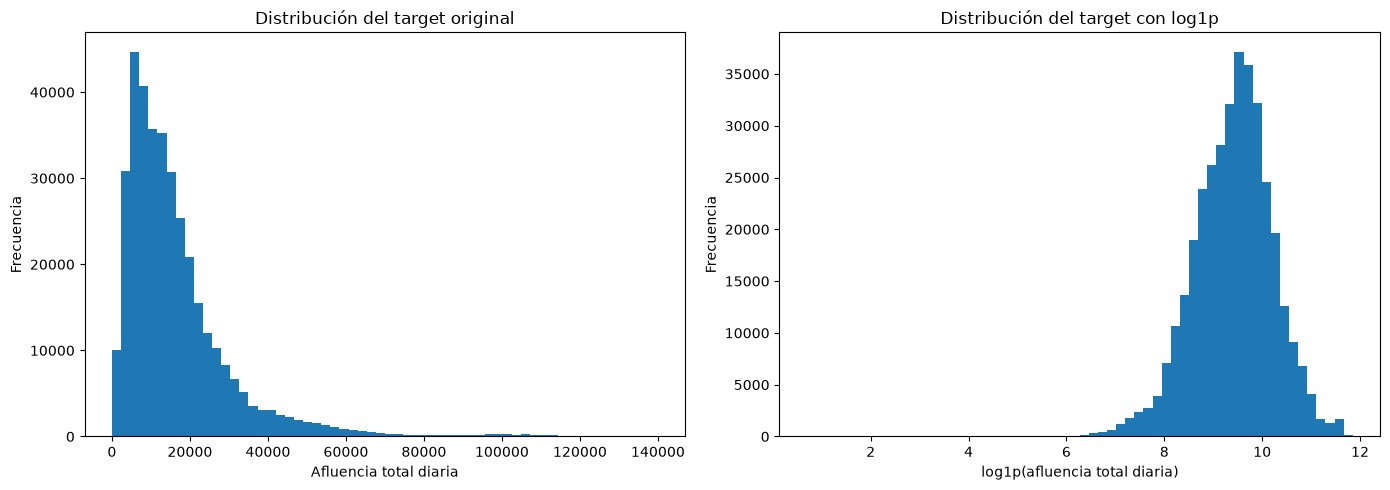

,target,skewness
0,original,2.676
1,log1p,-0.487


In [264]:
import numpy as np

df_modelado['target_log1p'] = np.log1p(df_modelado[target_modelo])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_modelado[target_modelo], bins=60)
axes[0].set_title('Distribución del target original')
axes[0].set_xlabel('Afluencia total diaria')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df_modelado['target_log1p'], bins=60)
axes[1].set_title('Distribución del target con log1p')
axes[1].set_xlabel('log1p(afluencia total diaria)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

pd.DataFrame({
    'target': ['original', 'log1p'],
    'skewness': [df_modelado[target_modelo].skew(), df_modelado['target_log1p'].skew()],
}).round(3)

**Decisión preliminar:** se conserva el target original para interpretación y también se prepara `log1p`. Si se entrena un modelo con `log1p`, las predicciones deben regresar a escala real con `expm1` antes de reportar MAE/RMSE en usuarios.

### 20.3 Split cronológico

Como es una serie de tiempo, el split no debe ser aleatorio para el modelo principal. Usamos un corte cronológico: train hasta `2025-06-30` y test desde `2025-07-01` hasta `2026-06-30`.

In [265]:
fecha_corte_test = pd.Timestamp('2025-07-01')

train_mask = df_modelado_lags['fecha'].lt(fecha_corte_test)
test_mask = df_modelado_lags['fecha'].ge(fecha_corte_test)

df_train = df_modelado_lags[train_mask].copy()
df_test = df_modelado_lags[test_mask].copy()

resumen_split_cronologico = pd.DataFrame({
    'split': ['train', 'test'],
    'fecha_min': [df_train['fecha'].min(), df_test['fecha'].min()],
    'fecha_max': [df_train['fecha'].max(), df_test['fecha'].max()],
    'filas': [len(df_train), len(df_test)],
    'estaciones': [df_train[['linea', 'estacion']].drop_duplicates().shape[0], df_test[['linea', 'estacion']].drop_duplicates().shape[0]],
})

resumen_split_cronologico

,split,fecha_min,fecha_max,filas,estaciones
0,train,2021-01-29,2025-06-30,285838,195
1,test,2025-07-01,2026-06-30,70327,195


### 20.4 Columnas predictoras candidatas

Separamos variables categóricas y numéricas. No usamos columnas como `afluencia_boleto`, `afluencia_prepago` o `afluencia_gratuidad` como features porque son partes del target total y causarían fuga de información.

In [266]:
features_categoricas = [
    'linea',
    'estacion',
    'dia_semana',
    'festivo',
    'evento_estructural',
]

features_numericas = [
    'time_idx',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_mean_7',
    'rolling_mean_28',
    'dia_semana_num',
    'numero_mes',
    'es_fin_semana',
    'es_festivo',
    'structural_break_metro',
    'temperature_2m_mean',
    'temperature_2m_max',
    'temperature_2m_min',
    'precipitation_sum',
    'rain_sum',
    'precipitation_hours',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'llovio',
    'lluvia_fuerte',
]

features_categoricas = [col for col in features_categoricas if col in df_modelado.columns]
features_numericas = [col for col in features_numericas if col in df_modelado.columns]

pd.DataFrame({
    'tipo_feature': ['categoricas', 'numericas'],
    'columnas': [features_categoricas, features_numericas],
    'n_columnas': [len(features_categoricas), len(features_numericas)],
})

,tipo_feature,columnas,n_columnas
0,categoricas,"[linea, estacion, dia_semana, festivo, evento_...",5
1,numericas,"[time_idx, lag_7, lag_14, lag_28, rolling_mean...",21


### 20.5 Comparación de encoding

Comparamos dos estrategias:

- **One-hot encoding:** más interpretable, pero crea muchas columnas, especialmente por `estacion`.
- **Frequency encoding:** usa poca memoria porque reemplaza cada categoría por su frecuencia en train, pero pierde detalle categórico.

Ambas se ajustan usando solo train.

In [267]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse=True)

X_train_onehot = onehot_encoder.fit_transform(df_train[features_categoricas])
X_test_onehot = onehot_encoder.transform(df_test[features_categoricas])

onehot_feature_names = onehot_encoder.get_feature_names_out(features_categoricas)

memoria_onehot_train_mb = (
    X_train_onehot.data.nbytes
    + X_train_onehot.indptr.nbytes
    + X_train_onehot.indices.nbytes
) / (1024 ** 2)

resumen_onehot = pd.DataFrame({
    'encoding': ['one_hot'],
    'filas_train': [X_train_onehot.shape[0]],
    'columnas_generadas': [X_train_onehot.shape[1]],
    'memoria_train_mb_aprox': [round(memoria_onehot_train_mb, 2)],
    'categorias_aprendidas_solo_train': [len(onehot_feature_names)],
})

resumen_onehot

,encoding,filas_train,columnas_generadas,memoria_train_mb_aprox,categorias_aprendidas_solo_train
0,one_hot,285838,197,17.45,197


In [268]:
def ajustar_frequency_encoding(train, columnas):
    mapas = {}
    for columna in columnas:
        mapas[columna] = train[columna].value_counts(normalize=True, dropna=False)
    return mapas

def aplicar_frequency_encoding(df_base, mapas):
    df_encoded = pd.DataFrame(index=df_base.index)
    for columna, mapa in mapas.items():
        df_encoded[f'{columna}_freq'] = df_base[columna].map(mapa).fillna(0)
    return df_encoded

mapas_frequency_encoding = ajustar_frequency_encoding(df_train, features_categoricas)
X_train_freq = aplicar_frequency_encoding(df_train, mapas_frequency_encoding)
X_test_freq = aplicar_frequency_encoding(df_test, mapas_frequency_encoding)

memoria_freq_train_mb = X_train_freq.memory_usage(deep=True).sum() / (1024 ** 2)

resumen_frequency = pd.DataFrame({
    'encoding': ['frequency'],
    'filas_train': [X_train_freq.shape[0]],
    'columnas_generadas': [X_train_freq.shape[1]],
    'memoria_train_mb_aprox': [round(memoria_freq_train_mb, 2)],
    'categorias_aprendidas_solo_train': [sum(len(mapa) for mapa in mapas_frequency_encoding.values())],
})

pd.concat([resumen_onehot, resumen_frequency], ignore_index=True)

,encoding,filas_train,columnas_generadas,memoria_train_mb_aprox,categorias_aprendidas_solo_train
0,one_hot,285838,197,17.45,197
1,frequency,285838,5,13.08,197


**Decisión preliminar de encoding:** para un modelo lineal conviene `one-hot` porque permite efectos separados por estación y línea. Para modelos simples o con restricciones de memoria, `frequency encoding` es más liviano, pero pierde interpretabilidad y puede subrepresentar estaciones importantes.

### 20.6 Scaling de variables numéricas

El escalamiento se ajusta solo con train. Esto evita que información del futuro entre al preprocesamiento. Los modelos lineales suelen beneficiarse de scaling; los modelos de árboles no lo necesitan tanto.

In [269]:
scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(df_train[features_numericas]),
    columns=features_numericas,
    index=df_train.index,
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(df_test[features_numericas]),
    columns=features_numericas,
    index=df_test.index,
)

revision_scaling = pd.DataFrame({
    'feature': features_numericas,
    'media_train_original': df_train[features_numericas].mean(numeric_only=True).values,
    'std_train_original': df_train[features_numericas].std(numeric_only=True).values,
    'media_train_escalada': X_train_num_scaled.mean().values,
    'std_train_escalada': X_train_num_scaled.std().values,
})

revision_scaling.round(3)

,feature,media_train_original,std_train_original,media_train_escalada,std_train_escalada
0,time_idx,847.948,470.497,-0.0,1.0
1,lag_7,16259.652,14149.081,0.0,1.0
2,lag_14,16223.610,14130.264,-0.0,1.0
3,lag_28,16137.411,14089.401,0.0,1.0
4,rolling_mean_7,16278.465,13314.384,-0.0,1.0
5,rolling_mean_28,16222.021,13201.355,0.0,1.0
6,dia_semana_num,3.000,2.001,-0.0,1.0
7,numero_mes,6.264,3.386,-0.0,1.0
8,es_fin_semana,0.286,0.452,0.0,1.0
9,es_festivo,0.019,0.137,-0.0,1.0


Con esto queda preparado el preprocesamiento. El siguiente paso ya sería entrenar modelos usando el split cronológico: primero baseline, luego un modelo lineal y después un ensamble basado en árboles.

## 21. Separación de unidad de predicción, target y variables predictoras

Antes de entrenar, dejamos explícito qué representa cada predicción.

**Unidad de predicción:** `fecha + linea + estacion`.

Eso significa que cada fila del dataset de modelado representa una pregunta como:

`Cuánta afluencia total tuvo la estación Balderas de la Línea 1 en una fecha específica?`

**Target:** `afluencia_total_modelo`.

El modelo no recibe la unidad de predicción como una instrucción aparte. La unidad queda definida por la forma de la tabla: cada fila es una combinación única de `fecha`, `linea` y `estacion`, y el target corresponde a esa fila.

In [270]:
unidad_prediccion = ['fecha', 'linea', 'estacion']
target_modelo = 'afluencia_total_modelo'

duplicados_unidad_prediccion = df_modelado_lags.duplicated(subset=unidad_prediccion).sum()

resumen_unidad_prediccion = pd.DataFrame({
    'unidad_prediccion': [' + '.join(unidad_prediccion)],
    'target': [target_modelo],
    'filas': [len(df_modelado_lags)],
    'unidades_unicas': [df_modelado_lags[unidad_prediccion].drop_duplicates().shape[0]],
    'duplicados_unidad': [duplicados_unidad_prediccion],
})

resumen_unidad_prediccion

,unidad_prediccion,target,filas,unidades_unicas,duplicados_unidad
0,fecha + linea + estacion,afluencia_total_modelo,356165,356165,0


Ahora separamos la base en dos partes:

- `y`: el target que queremos predecir.
- `X`: las variables que el modelo puede usar para predecir.

Quitamos columnas que identifican la fila o que causarían fuga de información. Por ejemplo, `afluencia_boleto`, `afluencia_prepago` y `afluencia_gratuidad` no se usan como predictores porque son partes del target total.

In [271]:
columnas_no_predictoras = [
    # Identificadores de la unidad de predicción
    'fecha',

    # Target y variantes del target
    'afluencia_total_modelo',
    'target_log1p',

    # Componentes del target agregado: usarlas sería data leakage
    'afluencia_boleto',
    'afluencia_prepago',
    'afluencia_gratuidad',
]

columnas_predictoras = [
    col for col in features_categoricas + features_numericas
    if col in df_modelado_lags.columns and col not in columnas_no_predictoras
]

X = df_modelado_lags[columnas_predictoras].copy()
y = df_modelado_lags[target_modelo].copy()
y_log = np.log1p(y)

resumen_X_y = pd.DataFrame({
    'objeto': ['X', 'y', 'y_log'],
    'descripcion': [
        'Variables predictoras',
        'Target en escala original',
        'Target transformado con log1p',
    ],
    'filas': [X.shape[0], y.shape[0], y_log.shape[0]],
    'columnas': [X.shape[1], 1, 1],
})

resumen_X_y

,objeto,descripcion,filas,columnas
0,X,Variables predictoras,356165,26
1,y,Target en escala original,356165,1
2,y_log,Target transformado con log1p,356165,1


La separación train/test se hace por fecha, no de forma aleatoria. El train contiene el pasado y el test contiene el periodo futuro que queremos simular.

In [272]:
fecha_corte_test = pd.Timestamp('2025-07-01')

train_mask = df_modelado_lags['fecha'].lt(fecha_corte_test)
test_mask = df_modelado_lags['fecha'].ge(fecha_corte_test)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

y_train_log = y_log.loc[train_mask].copy()
y_test_log = y_log.loc[test_mask].copy()

resumen_X_y_split = pd.DataFrame({
    'objeto': ['X_train', 'X_test', 'y_train', 'y_test', 'y_train_log', 'y_test_log'],
    'filas': [len(X_train), len(X_test), len(y_train), len(y_test), len(y_train_log), len(y_test_log)],
    'columnas': [X_train.shape[1], X_test.shape[1], 1, 1, 1, 1],
    'fecha_min': [
        df_modelado_lags.loc[train_mask, 'fecha'].min(),
        df_modelado_lags.loc[test_mask, 'fecha'].min(),
        df_modelado_lags.loc[train_mask, 'fecha'].min(),
        df_modelado_lags.loc[test_mask, 'fecha'].min(),
        df_modelado_lags.loc[train_mask, 'fecha'].min(),
        df_modelado_lags.loc[test_mask, 'fecha'].min(),
    ],
    'fecha_max': [
        df_modelado_lags.loc[train_mask, 'fecha'].max(),
        df_modelado_lags.loc[test_mask, 'fecha'].max(),
        df_modelado_lags.loc[train_mask, 'fecha'].max(),
        df_modelado_lags.loc[test_mask, 'fecha'].max(),
        df_modelado_lags.loc[train_mask, 'fecha'].max(),
        df_modelado_lags.loc[test_mask, 'fecha'].max(),
    ],
})

resumen_X_y_split

,objeto,filas,columnas,fecha_min,fecha_max
0,X_train,285838,26,2021-01-29,2025-06-30
1,X_test,70327,26,2025-07-01,2026-06-30
2,y_train,285838,1,2021-01-29,2025-06-30
3,y_test,70327,1,2025-07-01,2026-06-30
4,y_train_log,285838,1,2021-01-29,2025-06-30
5,y_test_log,70327,1,2025-07-01,2026-06-30


A partir de aquí, cualquier transformación que aprenda parámetros debe hacer `fit` solo con `X_train` y luego `transform` sobre `X_train` y `X_test`. Eso aplica para encoders, scalers, imputadores y modelos.

## 22. Baseline obligatorio

El PDF pide iniciar con un baseline. El baseline es una regla simple que sirve como punto de comparación: si un modelo complejo no mejora esta regla, entonces no está agregando valor.

Baseline propuesto:

`promedio histórico por linea + estacion + dia_semana`

Para cada fila de test, buscamos el promedio observado en train para esa misma combinación. Si alguna combinación no existe, usamos respaldos en cascada:

1. promedio por `linea + estacion + dia_semana`,
2. promedio por `linea + estacion`,
3. promedio por `linea`,
4. promedio global de train.

Todo se calcula solo con train.

In [273]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

def calcular_metricas_regresion(y_real, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        'modelo': nombre_modelo,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
    }

def baseline_promedios_historicos(train, test, target):
    inicio = time.perf_counter()

    promedio_estacion_dia = train.groupby(['linea', 'estacion', 'dia_semana'])[target].mean()
    promedio_estacion = train.groupby(['linea', 'estacion'])[target].mean()
    promedio_linea = train.groupby('linea')[target].mean()
    promedio_global = train[target].mean()

    predicciones = []
    nivel_usado = []

    for _, fila in test.iterrows():
        llave_estacion_dia = (fila['linea'], fila['estacion'], fila['dia_semana'])
        llave_estacion = (fila['linea'], fila['estacion'])

        if llave_estacion_dia in promedio_estacion_dia.index:
            predicciones.append(promedio_estacion_dia.loc[llave_estacion_dia])
            nivel_usado.append('linea_estacion_dia_semana')
        elif llave_estacion in promedio_estacion.index:
            predicciones.append(promedio_estacion.loc[llave_estacion])
            nivel_usado.append('linea_estacion')
        elif fila['linea'] in promedio_linea.index:
            predicciones.append(promedio_linea.loc[fila['linea']])
            nivel_usado.append('linea')
        else:
            predicciones.append(promedio_global)
            nivel_usado.append('global')

    tiempo = time.perf_counter() - inicio

    return np.array(predicciones), pd.Series(nivel_usado, name='nivel_baseline'), tiempo

y_pred_baseline, nivel_baseline, tiempo_baseline = baseline_promedios_historicos(
    df_train,
    df_test,
    target_modelo,
)

metricas_baseline = calcular_metricas_regresion(
    y_test,
    y_pred_baseline,
    'Baseline promedio historico estacion-dia_semana',
)
metricas_baseline['tiempo_entrenamiento_seg'] = tiempo_baseline
metricas_baseline['memoria_mb_aprox'] = 0

metricas_modelos = pd.DataFrame([metricas_baseline])
metricas_modelos[['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox']] = metricas_modelos[[
    'MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox'
]].round(3)

metricas_modelos

,modelo,MAE,MSE,RMSE,R2,tiempo_entrenamiento_seg,memoria_mb_aprox
0,Baseline promedio historico estacion-dia_semana,3267.504,3.070623e+07,5541.32,0.871,2.631,0


In [274]:
uso_nivel_baseline = (
    nivel_baseline.value_counts(normalize=False)
    .rename_axis('nivel_usado')
    .reset_index(name='filas_test')
)
uso_nivel_baseline['pct_test'] = (uso_nivel_baseline['filas_test'] / len(nivel_baseline) * 100).round(2)

uso_nivel_baseline

,nivel_usado,filas_test,pct_test
0,linea_estacion_dia_semana,70327,100.0


In [275]:
resultados_baseline_test = df_test[unidad_prediccion + ['dia_semana', target_modelo]].copy()
resultados_baseline_test['pred_baseline'] = y_pred_baseline
resultados_baseline_test['error_abs'] = (
    resultados_baseline_test[target_modelo] - resultados_baseline_test['pred_baseline']
).abs()
resultados_baseline_test['nivel_baseline'] = nivel_baseline.values

resultados_baseline_test.sort_values('error_abs', ascending=False).head(20)

,fecha,linea,estacion,dia_semana,afluencia_total_modelo,pred_baseline,error_abs,nivel_baseline
326893,2026-01-01,Línea 8,Constitución de 1917,Jueves,29439.0,94445.591304,65006.591304,linea_estacion_dia_semana
325533,2025-12-25,Línea 8,Constitución de 1917,Jueves,32459.0,94445.591304,61986.591304,linea_estacion_dia_semana
317449,2025-11-14,Línea 2,Cuatro Caminos,Viernes,133127.0,73901.132743,59225.867257,linea_estacion_dia_semana
320174,2025-11-28,Línea 2,Cuatro Caminos,Viernes,131327.0,73901.132743,57425.867257,linea_estacion_dia_semana
326830,2026-01-01,Línea 3,Indios Verdes,Jueves,32495.0,88951.735683,56456.735683,linea_estacion_dia_semana
317256,2025-11-13,Línea 2,Cuatro Caminos,Jueves,127415.0,71506.814159,55908.185841,linea_estacion_dia_semana
320369,2025-11-29,Línea 2,Cuatro Caminos,Sábado,117003.0,61115.557522,55887.442478,linea_estacion_dia_semana
318809,2025-11-21,Línea 2,Cuatro Caminos,Viernes,129439.0,73901.132743,55537.867257,linea_estacion_dia_semana
316101,2025-11-07,Línea 2,Cuatro Caminos,Viernes,129012.0,73901.132743,55110.867257,linea_estacion_dia_semana
317063,2025-11-12,Línea 2,Cuatro Caminos,Miércoles,126145.0,71525.853982,54619.146018,linea_estacion_dia_semana


**Lectura del baseline:** esta tabla de métricas es el mínimo que deben superar los modelos. También revisamos los errores más grandes para entender en qué estaciones o fechas falla una regla basada solo en promedio histórico.

## 23. Modelo lineal: Ridge Regression

El primer modelo requerido por el PDF debe venir de la familia lineal. Usamos `Ridge Regression` porque funciona bien con muchas variables one-hot y agrega regularizaci?n para reducir sobreajuste.

Preprocesamiento:

- Categ?ricas: `OneHotEncoder`, ajustado solo con train.
- Num?ricas: `StandardScaler`, ajustado solo con train.

El target se mantiene en escala original para que MAE/RMSE se interpreten directamente en usuarios.

In [276]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import pickle

try:
    encoder_ridge = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    encoder_ridge = OneHotEncoder(handle_unknown='ignore', sparse=True)

preprocesador_ridge = ColumnTransformer(
    transformers=[
        ('categoricas', encoder_ridge, features_categoricas),
        ('numericas', StandardScaler(), features_numericas),
    ],
    remainder='drop',
)

modelo_ridge = Pipeline(
    steps=[
        ('preprocesamiento', preprocesador_ridge),
        ('modelo', Ridge(alpha=10.0)),
    ]
)

inicio = time.perf_counter()
modelo_ridge.fit(X_train, y_train)
tiempo_ridge = time.perf_counter() - inicio

y_pred_ridge = modelo_ridge.predict(X_test)
y_pred_ridge = np.clip(y_pred_ridge, 0, None)

metricas_ridge = calcular_metricas_regresion(
    y_test,
    y_pred_ridge,
    'Ridge Regression',
)
metricas_ridge['tiempo_entrenamiento_seg'] = tiempo_ridge
metricas_ridge['memoria_mb_aprox'] = len(pickle.dumps(modelo_ridge)) / (1024 ** 2)

metricas_ridge_df = pd.DataFrame([metricas_ridge])
metricas_ridge_df[['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox']] = metricas_ridge_df[[
    'MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox'
]].round(3)

metricas_ridge_df

,modelo,MAE,MSE,RMSE,R2,tiempo_entrenamiento_seg,memoria_mb_aprox
0,Ridge Regression,1720.915,1.099573e+07,3315.981,0.954,1.25,0.008


## 24. Modelo ensemble basado en ?rboles

El segundo modelo requerido por el PDF debe ser un ensemble basado en ?rboles. Usamos `HistGradientBoostingRegressor` porque suele ser m?s eficiente que Random Forest en bases medianas/grandes.

Para este modelo usamos `frequency encoding` en las variables categ?ricas. Esto evita una matriz one-hot grande y mantiene el entrenamiento ligero. Los ?rboles no necesitan scaling de variables num?ricas.

In [277]:
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits
import os

os.environ['LOKY_MAX_CPU_COUNT'] = '1'

mapas_frequency_modelo = ajustar_frequency_encoding(X_train, features_categoricas)

X_train_tree = pd.concat(
    [
        aplicar_frequency_encoding(X_train, mapas_frequency_modelo).reset_index(drop=True),
        X_train[features_numericas].reset_index(drop=True),
    ],
    axis=1,
)

X_test_tree = pd.concat(
    [
        aplicar_frequency_encoding(X_test, mapas_frequency_modelo).reset_index(drop=True),
        X_test[features_numericas].reset_index(drop=True),
    ],
    axis=1,
)

y_train_tree = y_train.reset_index(drop=True)
y_test_tree = y_test.reset_index(drop=True)

print('Filas X_train_tree:', len(X_train_tree), '| Filas y_train_tree:', len(y_train_tree))
print('Filas X_test_tree:', len(X_test_tree), '| Filas y_test_tree:', len(y_test_tree))

modelo_hgb = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42,
)

inicio = time.perf_counter()
with threadpool_limits(limits=1):
    modelo_hgb.fit(X_train_tree, y_train_tree)
tiempo_hgb = time.perf_counter() - inicio

y_pred_hgb = modelo_hgb.predict(X_test_tree)
y_pred_hgb = np.clip(y_pred_hgb, 0, None)

metricas_hgb = calcular_metricas_regresion(
    y_test_tree,
    y_pred_hgb,
    'HistGradientBoostingRegressor',
)
metricas_hgb['tiempo_entrenamiento_seg'] = tiempo_hgb
metricas_hgb['memoria_mb_aprox'] = len(pickle.dumps(modelo_hgb)) / (1024 ** 2)

metricas_hgb_df = pd.DataFrame([metricas_hgb])
metricas_hgb_df[['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox']] = metricas_hgb_df[[
    'MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox'
]].round(3)

metricas_hgb_df

Filas X_train_tree: 285838 | Filas y_train_tree: 285838
Filas X_test_tree: 70327 | Filas y_test_tree: 70327


,modelo,MAE,MSE,RMSE,R2,tiempo_entrenamiento_seg,memoria_mb_aprox
0,HistGradientBoostingRegressor,1527.069,8648153.184,2940.774,0.964,4.681,0.706


## 25. Comparacion de modelos

Comparamos baseline, modelo lineal y modelo ensemble usando las m?tricas pedidas por el PDF. El mejor modelo debe mejorar al baseline, pero tambi?n debe justificarse por interpretabilidad, costo computacional y robustez.

In [278]:
metricas_modelos = pd.concat(
    [metricas_modelos, metricas_ridge_df, metricas_hgb_df],
    ignore_index=True,
)

metricas_modelos.sort_values('RMSE')

,modelo,MAE,MSE,RMSE,R2,tiempo_entrenamiento_seg,memoria_mb_aprox
2,HistGradientBoostingRegressor,1527.069,8.648153e+06,2940.774,0.964,4.681,0.706
1,Ridge Regression,1720.915,1.099573e+07,3315.981,0.954,1.250,0.008
0,Baseline promedio historico estacion-dia_semana,3267.504,3.070623e+07,5541.320,0.871,2.631,0.000


In [279]:
comparacion_predicciones_test = df_test[unidad_prediccion + ['dia_semana', target_modelo]].copy()
comparacion_predicciones_test['pred_baseline'] = y_pred_baseline
comparacion_predicciones_test['pred_ridge'] = y_pred_ridge
comparacion_predicciones_test['pred_hgb'] = y_pred_hgb

for columna_pred in ['pred_baseline', 'pred_ridge', 'pred_hgb']:
    comparacion_predicciones_test[f'error_abs_{columna_pred}'] = (
        comparacion_predicciones_test[target_modelo] - comparacion_predicciones_test[columna_pred]
    ).abs()

comparacion_predicciones_test.sort_values('error_abs_pred_hgb', ascending=False).head(20)

,fecha,linea,estacion,dia_semana,afluencia_total_modelo,pred_baseline,pred_ridge,pred_hgb,error_abs_pred_baseline,error_abs_pred_ridge,error_abs_pred_hgb
344588,2026-04-03,Línea 2,Cuatro Caminos,Viernes,42120.0,73901.132743,101026.832701,110460.666336,31781.132743,58906.832701,68340.666336
345781,2026-04-09,Línea 3,Universidad,Jueves,3490.0,52355.753304,50037.878378,60015.488860,48865.753304,46547.878378,56525.488860
344618,2026-04-03,Línea 3,Indios Verdes,Viernes,39333.0,91023.035242,86188.517596,91611.881478,51690.035242,46855.517596,52278.881478
317275,2025-11-13,Línea 2,Zócalo/Tenochtitlan,Jueves,9.0,41020.504854,45509.934299,51528.914902,41011.504854,45500.934299,51519.914902
296157,2025-07-26,Línea 2,Zócalo/Tenochtitlan,Sábado,2854.0,46473.233503,47383.650935,52769.439247,43619.233503,44529.650935,49915.439247
321557,2025-12-05,Línea 2,Zócalo/Tenochtitlan,Viernes,1.0,42668.846535,50544.928174,46531.185836,42667.846535,50543.928174,46530.185836
317637,2025-11-15,Línea 2,Allende,Sábado,111.0,25417.340708,49422.545916,46333.613131,25306.340708,49311.545916,46222.613131
306049,2025-09-15,Línea A,La Paz,Lunes,1481.0,39103.709957,45769.158067,46839.046250,37622.709957,44288.158067,45358.046250
344681,2026-04-03,Línea 8,Constitución de 1917,Viernes,63980.0,94908.887446,104944.972481,108162.886785,30928.887446,40964.972481,44182.886785
302685,2025-08-29,Línea 2,Zócalo/Tenochtitlan,Viernes,13902.0,42668.846535,51912.990525,57894.026017,28766.846535,38010.990525,43992.026017


**Lectura inicial:** si el modelo ensemble mejora al baseline y al modelo lineal, eso sugiere que hay relaciones no lineales ?tiles entre calendario, historial reciente, estaci?n, eventos y clima. Si Ridge queda cerca del baseline, puede seguir siendo valioso por interpretabilidad, pero el PDF pide comparar su desempe?o contra el baseline.

## 26. Auditor?a de overfitting y fuga de informaci?n

Como el R2 del modelo ensemble es alto, revisamos si el modelo est? generalizando o si podr?a estar aprovechando informaci?n que no deber?a tener.

La comparaci?n train vs test ayuda a detectar overfitting: si train es casi perfecto y test baja mucho, el modelo memoriz?. Si ambos son parecidos, el desempe?o parece m?s estable.

Tambi?n auditamos tres puntos:

- Que el corte train/test sea cronol?gico.
- Que no entren al modelo columnas que sean parte directa del target.
- Que los encoders y scalers se ajusten solo con train.

Nota importante sobre lags: como `lag_7`, `lag_14`, `lag_28` y medias m?viles se calculan con valores pasados, son v?lidos si el escenario es predecir d?a a d?a usando informaci?n hist?rica ya observada. Si el escenario fuera predecir todo un a?o futuro sin conocer ning?n d?a dentro de ese a?o, habr?a que recalcular la evaluaci?n con una estrategia m?s estricta.


In [ ]:
# M?tricas en train y test para revisar posible overfitting

def agregar_split_a_metricas(metricas, split):
    metricas = metricas.copy()
    metricas['split'] = split
    return metricas

# Baseline en train: es una referencia optimista porque calcula promedios usando el mismo train.
y_pred_baseline_train, _, tiempo_baseline_train = baseline_promedios_historicos(
    df_train,
    df_train,
    target_modelo,
)

metricas_baseline_train = calcular_metricas_regresion(
    y_train,
    y_pred_baseline_train,
    'Baseline promedio historico estacion-dia_semana',
)
metricas_baseline_train['tiempo_entrenamiento_seg'] = tiempo_baseline_train
metricas_baseline_train['memoria_mb_aprox'] = 0

# Ridge en train
y_pred_ridge_train = modelo_ridge.predict(X_train)
y_pred_ridge_train = np.clip(y_pred_ridge_train, 0, None)

metricas_ridge_train = calcular_metricas_regresion(
    y_train,
    y_pred_ridge_train,
    'Ridge Regression',
)
metricas_ridge_train['tiempo_entrenamiento_seg'] = tiempo_ridge
metricas_ridge_train['memoria_mb_aprox'] = len(pickle.dumps(modelo_ridge)) / (1024 ** 2)

# HistGradientBoosting en train
y_pred_hgb_train = modelo_hgb.predict(X_train_tree)
y_pred_hgb_train = np.clip(y_pred_hgb_train, 0, None)

metricas_hgb_train = calcular_metricas_regresion(
    y_train_tree,
    y_pred_hgb_train,
    'HistGradientBoostingRegressor',
)
metricas_hgb_train['tiempo_entrenamiento_seg'] = tiempo_hgb
metricas_hgb_train['memoria_mb_aprox'] = len(pickle.dumps(modelo_hgb)) / (1024 ** 2)

metricas_train_test = pd.DataFrame([
    agregar_split_a_metricas(metricas_baseline_train, 'train'),
    agregar_split_a_metricas(metricas_baseline, 'test'),
    agregar_split_a_metricas(metricas_ridge_train, 'train'),
    agregar_split_a_metricas(metricas_ridge, 'test'),
    agregar_split_a_metricas(metricas_hgb_train, 'train'),
    agregar_split_a_metricas(metricas_hgb, 'test'),
])

metricas_train_test[['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox']] = metricas_train_test[[
    'MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'memoria_mb_aprox'
]].round(3)

metricas_train_test.sort_values(['modelo', 'split'])


In [ ]:
# Diferencia entre train y test por modelo
comparacion_overfitting = (
    metricas_train_test
    .pivot(index='modelo', columns='split', values=['MAE', 'RMSE', 'R2'])
)

comparacion_overfitting.columns = [f'{metrica}_{split}' for metrica, split in comparacion_overfitting.columns]
comparacion_overfitting = comparacion_overfitting.reset_index()

comparacion_overfitting['gap_RMSE_test_menos_train'] = (
    comparacion_overfitting['RMSE_test'] - comparacion_overfitting['RMSE_train']
)
comparacion_overfitting['gap_R2_train_menos_test'] = (
    comparacion_overfitting['R2_train'] - comparacion_overfitting['R2_test']
)

comparacion_overfitting.round(3).sort_values('RMSE_test')


In [ ]:
# Auditor?a r?pida de separaci?n y posibles fugas de informaci?n
fechas_train = set(df_train['fecha'].unique())
fechas_test = set(df_test['fecha'].unique())
fechas_compartidas = fechas_train.intersection(fechas_test)

unidades_train = df_train[unidad_prediccion].astype(str).agg('|'.join, axis=1)
unidades_test = df_test[unidad_prediccion].astype(str).agg('|'.join, axis=1)
unidades_compartidas = set(unidades_train).intersection(set(unidades_test))

columnas_fuga_presentes = sorted(set(columnas_no_predictoras).intersection(X.columns))
columnas_componentes_target_en_X = sorted(
    set(['afluencia_boleto', 'afluencia_prepago', 'afluencia_gratuidad']).intersection(X.columns)
)

resumen_auditoria_modelado = pd.DataFrame({
    'revision': [
        'train termina antes de test',
        'fechas compartidas entre train y test',
        'unidades fecha-linea-estacion repetidas entre train y test',
        'columnas no predictoras presentes en X',
        'componentes directos del target presentes en X',
        'one-hot ajustado solo con train',
        'scaler ajustado solo con train',
        'frequency encoding ajustado solo con train',
    ],
    'resultado': [
        df_train['fecha'].max() < df_test['fecha'].min(),
        len(fechas_compartidas),
        len(unidades_compartidas),
        columnas_fuga_presentes,
        columnas_componentes_target_en_X,
        'fit en X_train dentro del Pipeline de Ridge',
        'fit_transform en train y transform en test',
        'mapas creados con X_train y aplicados a X_test',
    ],
})

resumen_auditoria_modelado


In [ ]:
# Auditor?a de lags: revisar si los lags del periodo test usan valores observados dentro del mismo periodo test
# Esto no es fuga si el supuesto es predecir d?a a d?a con historial ya observado.
# S? ser?a demasiado optimista si quisi?ramos pronosticar todo el a?o futuro de una sola vez.

df_lag_auditoria = df_modelado.sort_values(['linea', 'estacion', 'fecha']).copy()
grupo_lag = df_lag_auditoria.groupby(['linea', 'estacion'])

for n in [7, 14, 28]:
    df_lag_auditoria[f'fecha_origen_lag_{n}'] = grupo_lag['fecha'].shift(n)

columnas_origen_lag = [f'fecha_origen_lag_{n}' for n in [7, 14, 28]]

df_lag_auditoria = df_lag_auditoria.loc[df_modelado_lags.index].copy()
df_lag_auditoria_test = df_lag_auditoria[df_lag_auditoria['fecha'].ge(fecha_corte_test)].copy()

resumen_lags_test = []
for columna in columnas_origen_lag:
    resumen_lags_test.append({
        'lag': columna.replace('fecha_origen_', ''),
        'filas_test': len(df_lag_auditoria_test),
        'lag_viene_de_train': df_lag_auditoria_test[columna].lt(fecha_corte_test).sum(),
        'lag_viene_de_test_previo': df_lag_auditoria_test[columna].ge(fecha_corte_test).sum(),
        'pct_lag_viene_de_test_previo': (
            df_lag_auditoria_test[columna].ge(fecha_corte_test).mean() * 100
        ).round(2),
    })

pd.DataFrame(resumen_lags_test)


**C?mo leer esta auditor?a:**

- Si `RMSE_train` y `RMSE_test` son cercanos, no hay se?al fuerte de overfitting.
- Si `RMSE_test` es mucho mayor que `RMSE_train`, el modelo est? aprendiendo demasiado el train.
- Si las columnas `afluencia_boleto`, `afluencia_prepago` o `afluencia_gratuidad` aparecen en `X`, habr?a fuga directa del target. Deben salir como lista vac?a.
- Si muchos lags del test vienen de d?as previos del propio test, el resultado corresponde a un escenario de predicci?n secuencial d?a a d?a, no a un pron?stico cerrado de todo el a?o.


## 27. Correcciones metodológicas aplicadas

Esta sección corrige puntos metodológicos sin borrar las partes anteriores que ya funcionaban. Desde aquí, el modelado corregido usa como fuente el archivo guardado en Loading, no objetos intermedios en memoria.

Cambios aplicados:

- Structural breaks del Metro por estación realmente cerrada, no por línea completa.
- No se marcan como structural break los periodos posteriores a reapertura.
- Se agrega structural break de mezcla/productos de pago con evidencia desde los datos.
- Se clasifican los ceros en varias causas con decisión ETL.
- Se guarda de nuevo el transformado y se vuelve a leer para modelar.
- Los lags 7/14/28 se recalculan por días calendario reales.
- Se audita memoria separando tamaño serializado del modelo y memoria pico aproximada durante `fit`.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

if 'ruta_csv' in globals():
    ruta_tareas = ruta_csv.parent
else:
    ruta_tareas = Path.cwd() / 'P1 Module 1. Python Libraries & Statistics' / 'Tareas'

ruta_transformado = ruta_tareas / 'metro_cdmx_transformado.csv'
ruta_modelo_desglosado = ruta_tareas / 'metro_cdmx_modelo_desglosado.csv'
ruta_modelo_agregado = ruta_tareas / 'metro_cdmx_modelo_agregado_estacion.csv'

# Loading: desde este punto se vuelve a leer el archivo transformado como fuente única.
df_transformado_corregido = pd.read_csv(ruta_transformado, parse_dates=['fecha'], low_memory=False)
df_transformado_corregido['structural_break_metro'] = False
df_transformado_corregido['evento_estructural'] = 'Sin evento'

eventos_metro_estacion = [
    {'evento': 'Cierre total Línea 12 por colapso', 'linea': 'Línea 12', 'fecha_inicio': '2021-05-04', 'fecha_fin': '2023-01-14', 'estaciones': 'todas'},
    {'evento': 'L12 tramo elevado cerrado tras reapertura subterránea', 'linea': 'Línea 12', 'fecha_inicio': '2023-01-15', 'fecha_fin': '2023-07-14', 'estaciones': ['Culhuacán', 'San Andrés Tomatlán', 'Lomas Estrella', 'Calle 11', 'Periférico Oriente', 'Tezonco', 'Olivos', 'Nopalera', 'Zapotitlán', 'Tlaltenco', 'Tláhuac']},
    {'evento': 'L12 último tramo elevado cerrado antes de reapertura total', 'linea': 'Línea 12', 'fecha_inicio': '2023-07-15', 'fecha_fin': '2024-01-29', 'estaciones': ['Tezonco', 'Olivos', 'Nopalera', 'Zapotitlán', 'Tlaltenco', 'Tláhuac']},
    {'evento': 'Modernización Línea 1 etapa 1', 'linea': 'Línea 1', 'fecha_inicio': '2022-07-11', 'fecha_fin': '2023-10-28', 'estaciones': ['Pantitlán', 'Zaragoza', 'Gómez Farías', 'Boulevard Puerto Aéreo', 'Balbuena', 'Moctezuma', 'San Lázaro', 'Candelaria', 'Merced', 'Pino Suárez', 'Isabel la Católica', 'Salto del Agua']},
    {'evento': 'Modernización Línea 1 etapa 2', 'linea': 'Línea 1', 'fecha_inicio': '2023-11-10', 'fecha_fin': '2026-06-30', 'estaciones': ['Balderas', 'Cuauhtémoc', 'Insurgentes', 'Sevilla', 'Chapultepec', 'Juanacatlán', 'Tacubaya', 'Observatorio']},
    {'evento': 'Renivelación Línea 9 tramo Pantitlán-Ciudad Deportiva', 'linea': 'Línea 9', 'fecha_inicio': '2023-12-17', 'fecha_fin': '2024-09-09', 'estaciones': ['Pantitlán', 'Puebla', 'Ciudad Deportiva']},
]

for evento in eventos_metro_estacion:
    linea = evento['linea']
    estaciones_linea = sorted(df_transformado_corregido.loc[df_transformado_corregido['linea'].eq(linea), 'estacion'].unique())
    estaciones = estaciones_linea if evento['estaciones'] == 'todas' else [e for e in evento['estaciones'] if e in estaciones_linea]
    mascara = (
        df_transformado_corregido['linea'].eq(linea)
        & df_transformado_corregido['estacion'].isin(estaciones)
        & df_transformado_corregido['fecha'].between(pd.Timestamp(evento['fecha_inicio']), pd.Timestamp(evento['fecha_fin']))
    )
    df_transformado_corregido.loc[mascara, 'structural_break_metro'] = True
    df_transformado_corregido.loc[mascara, 'evento_estructural'] = evento['evento']

# Structural break de productos de pago, detectado con la participación diaria de Boleto.
pago_diario = df_transformado_corregido.groupby(['fecha', 'tipo_pago'], as_index=False)['afluencia'].sum()
pago_pivot = pago_diario.pivot(index='fecha', columns='tipo_pago', values='afluencia').fillna(0)
pago_pivot['total'] = pago_pivot.sum(axis=1)
pago_pivot['share_boleto'] = np.where(pago_pivot['total'].gt(0), pago_pivot.get('Boleto', 0) / pago_pivot['total'], np.nan)
pago_pivot['share_prepago'] = np.where(pago_pivot['total'].gt(0), pago_pivot.get('Prepago', 0) / pago_pivot['total'], np.nan)
pago_pivot['share_boleto_rolling_30'] = pago_pivot['share_boleto'].rolling(30, min_periods=15).mean()

candidatos_pago = pago_pivot[(pago_pivot.index >= pd.Timestamp('2023-01-01')) & (pago_pivot['share_boleto_rolling_30'] <= 0.02)]
fecha_quiebre_pago = candidatos_pago.index.min() if len(candidatos_pago) else pago_pivot['share_boleto_rolling_30'].idxmin()

df_transformado_corregido['structural_break_pago'] = df_transformado_corregido['fecha'].ge(fecha_quiebre_pago)
df_transformado_corregido['evento_pago'] = np.where(
    df_transformado_corregido['structural_break_pago'],
    'Cambio en mezcla/productos de pago',
    'Sin cambio estructural de pago',
)

df_transformado_corregido['cero_total_sin_evento'] = (
    df_transformado_corregido['cero_total_estacion_dia'].astype(bool)
    & ~df_transformado_corregido['structural_break_metro'].astype(bool)
)
df_transformado_corregido['afluencia_modelo'] = df_transformado_corregido['afluencia'].mask(
    df_transformado_corregido['cero_total_estacion_dia'].astype(bool),
    np.nan,
)

df_transformado_corregido['causa_cero'] = 'No es cero'
mask_cero = df_transformado_corregido['afluencia'].eq(0)
mask_cierre = mask_cero & df_transformado_corregido['cero_total_estacion_dia'].astype(bool) & df_transformado_corregido['structural_break_metro'].astype(bool)
mask_total_sin_evento = mask_cero & df_transformado_corregido['cero_total_estacion_dia'].astype(bool) & ~df_transformado_corregido['structural_break_metro'].astype(bool)
mask_pago = mask_cero & df_transformado_corregido['cero_parcial_tipo_pago'].astype(bool) & df_transformado_corregido['structural_break_pago'].astype(bool)
mask_parcial_operativo = mask_cero & df_transformado_corregido['cero_parcial_tipo_pago'].astype(bool) & ~df_transformado_corregido['structural_break_pago'].astype(bool)

df_transformado_corregido.loc[mask_cierre, 'causa_cero'] = 'Cierre confirmado de estación/tramo'
df_transformado_corregido.loc[mask_total_sin_evento, 'causa_cero'] = 'Cero total sin evento confirmado: posible dato faltante/error'
df_transformado_corregido.loc[mask_pago, 'causa_cero'] = 'Cero parcial asociado a cambio de producto de pago'
df_transformado_corregido.loc[mask_parcial_operativo, 'causa_cero'] = 'Cero parcial operativo por tipo de pago'

resumen_causas_cero = (
    df_transformado_corregido[df_transformado_corregido['afluencia'].eq(0)]
    .groupby('causa_cero')
    .agg(registros=('afluencia', 'size'), lineas=('linea', 'nunique'), estaciones=('estacion', 'nunique'), fecha_min=('fecha', 'min'), fecha_max=('fecha', 'max'))
    .reset_index()
    .sort_values('registros', ascending=False)
)

resumen_break_pago = pd.DataFrame({
    'revision': ['fecha_quiebre_pago_detectada', 'share_boleto_promedio_30d_en_quiebre', 'share_prepago_en_quiebre'],
    'valor': [fecha_quiebre_pago, pago_pivot.loc[fecha_quiebre_pago, 'share_boleto_rolling_30'], pago_pivot.loc[fecha_quiebre_pago, 'share_prepago']],
})

display(resumen_causas_cero)
display(resumen_break_pago)


In [ ]:
resumen_structural_metro = (
    df_transformado_corregido[df_transformado_corregido['structural_break_metro']]
    .groupby(['evento_estructural', 'linea'])
    .agg(estaciones_afectadas=('estacion', 'nunique'), registros=('afluencia', 'size'), ceros=('afluencia', lambda s: s.eq(0).sum()), fecha_min=('fecha', 'min'), fecha_max=('fecha', 'max'))
    .reset_index()
)

tabla_decisiones_etl = pd.DataFrame([
    {'problema_detectado': 'Ceros totales por cierres confirmados del Metro', 'evidencia': f'{int(mask_cierre.sum()):,} registros en estaciones-fechas marcadas como cierre confirmado.', 'decision': 'Conservar en transformado con bandera; excluir del target de modelado mediante afluencia_modelo = NaN.'},
    {'problema_detectado': 'Ceros totales sin evento confirmado', 'evidencia': f'{int(mask_total_sin_evento.sum()):,} registros con estación-día completo en cero fuera de cierres conocidos.', 'decision': 'Documentar como posible faltante/error; excluir del target de modelado, pero no borrar del transformado.'},
    {'problema_detectado': 'Ceros parciales por tipo de pago', 'evidencia': f'{int((mask_pago | mask_parcial_operativo).sum()):,} registros donde un tipo de pago vale 0 pero la estación sí tuvo afluencia.', 'decision': 'Conservar; pueden representar mezcla real de productos o cambios en forma de pago.'},
    {'problema_detectado': 'Structural break en productos de pago', 'evidencia': f"Desde {fecha_quiebre_pago.date()} el promedio móvil 30d de Boleto cae a {pago_pivot.loc[fecha_quiebre_pago, 'share_boleto_rolling_30']:.2%}.", 'decision': 'Agregar structural_break_pago/evento_pago; no excluir por sí mismo porque la demanda total sigue siendo comparable.'},
    {'problema_detectado': 'Structural breaks del Metro marcados por línea completa', 'evidencia': f"La lógica corregida marca {resumen_structural_metro['estaciones_afectadas'].sum():,} estaciones-evento específicas, no líneas completas después de reaperturas parciales.", 'decision': 'Usar estación + fecha para cierres; periodos posteriores a reapertura vuelven a ser comparables.'},
])

display(resumen_structural_metro.sort_values(['linea', 'fecha_min']))
tabla_decisiones_etl


In [ ]:
# Guardar transformado corregido y volverlo a leer para modelado.
df_transformado_corregido.to_csv(ruta_transformado, index=False)
df_transformado_modeling = pd.read_csv(ruta_transformado, parse_dates=['fecha'], low_memory=False)
df_modelo_desglosado_corr = df_transformado_modeling.dropna(subset=['afluencia_modelo']).copy()

columnas_agregacion_corr = [
    'fecha', 'linea', 'estacion', 'dia_semana_num', 'dia_semana', 'es_fin_semana', 'numero_mes', 'nombre_mes', 'anio_mes',
    'es_festivo', 'festivo', 'structural_break_metro', 'evento_estructural', 'structural_break_pago', 'evento_pago',
    'cero_total_estacion_dia', 'cero_total_sin_evento', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'rain_sum', 'precipitation_hours', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'weather_code', 'llovio', 'lluvia_fuerte',
]
columnas_agregacion_corr = [c for c in columnas_agregacion_corr if c in df_modelo_desglosado_corr.columns]

base_agregar_corr = df_modelo_desglosado_corr.copy()
for c in ['evento_estructural', 'evento_pago', 'festivo']:
    if c in base_agregar_corr.columns:
        base_agregar_corr[c] = base_agregar_corr[c].fillna('Sin evento')

df_modelo_agregado_corr = (
    base_agregar_corr[columnas_agregacion_corr + ['tipo_pago', 'afluencia_modelo']]
    .pivot_table(index=columnas_agregacion_corr, columns='tipo_pago', values='afluencia_modelo', aggfunc='sum', fill_value=0)
    .reset_index()
)
df_modelo_agregado_corr.columns.name = None
df_modelo_agregado_corr = df_modelo_agregado_corr.rename(columns={'Boleto': 'afluencia_boleto', 'Gratuidad': 'afluencia_gratuidad', 'Prepago': 'afluencia_prepago'})
for c in ['afluencia_boleto', 'afluencia_prepago', 'afluencia_gratuidad']:
    if c not in df_modelo_agregado_corr.columns:
        df_modelo_agregado_corr[c] = 0
df_modelo_agregado_corr['afluencia_total_modelo'] = df_modelo_agregado_corr[['afluencia_boleto', 'afluencia_prepago', 'afluencia_gratuidad']].sum(axis=1)

df_modelo_desglosado_corr.to_csv(ruta_modelo_desglosado, index=False)
df_modelo_agregado_corr.to_csv(ruta_modelo_agregado, index=False)

pd.DataFrame({
    'dataset': ['transformado_releido', 'modelo_desglosado_corr', 'modelo_agregado_corr'],
    'filas': [len(df_transformado_modeling), len(df_modelo_desglosado_corr), len(df_modelo_agregado_corr)],
    'columnas': [df_transformado_modeling.shape[1], df_modelo_desglosado_corr.shape[1], df_modelo_agregado_corr.shape[1]],
    'fecha_min': [df_transformado_modeling['fecha'].min(), df_modelo_desglosado_corr['fecha'].min(), df_modelo_agregado_corr['fecha'].min()],
    'fecha_max': [df_transformado_modeling['fecha'].max(), df_modelo_desglosado_corr['fecha'].max(), df_modelo_agregado_corr['fecha'].max()],
})


### 27.1 Lags por días calendario reales

La versión anterior calculaba `lag_7`, `lag_14` y `lag_28` como observaciones anteriores. Ahora cada lag busca exactamente la misma estación en `fecha - 7`, `fecha - 14` y `fecha - 28`.


In [ ]:
df_modelado_corr = df_modelo_agregado_corr.sort_values(['linea', 'estacion', 'fecha']).copy()
target_modelo = 'afluencia_total_modelo'
df_modelado_corr['time_idx'] = (df_modelado_corr['fecha'] - df_modelado_corr['fecha'].min()).dt.days

base_lags = df_modelado_corr[['linea', 'estacion', 'fecha', target_modelo]].copy()
for dias in [7, 14, 28]:
    fuente = base_lags.rename(columns={target_modelo: f'lag_{dias}'})
    fuente['fecha'] = fuente['fecha'] + pd.to_timedelta(dias, unit='D')
    df_modelado_corr = df_modelado_corr.merge(fuente[['linea', 'estacion', 'fecha', f'lag_{dias}']], on=['linea', 'estacion', 'fecha'], how='left')

def rolling_calendario_por_estacion(grupo):
    linea, estacion = grupo.name
    grupo = grupo.sort_values('fecha')
    idx = pd.date_range(grupo['fecha'].min(), grupo['fecha'].max(), freq='D')
    serie = grupo.set_index('fecha')[target_modelo].reindex(idx)
    salida = pd.DataFrame({
        'fecha': idx,
        'rolling_mean_7': serie.shift(1).rolling(window=7, min_periods=3).mean().values,
        'rolling_mean_28': serie.shift(1).rolling(window=28, min_periods=7).mean().values,
    })
    salida['linea'] = linea
    salida['estacion'] = estacion
    return salida

rolling_corr = df_modelado_corr.groupby(['linea', 'estacion'], group_keys=False).apply(rolling_calendario_por_estacion, include_groups=False).reset_index(drop=True)
df_modelado_corr = df_modelado_corr.merge(rolling_corr, on=['linea', 'estacion', 'fecha'], how='left')

features_temporales_corr = ['time_idx', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']
resumen_lags_calendario = pd.DataFrame({
    'feature': features_temporales_corr,
    'nulos': [df_modelado_corr[c].isna().sum() for c in features_temporales_corr],
    'pct_nulos': [(df_modelado_corr[c].isna().mean() * 100).round(2) for c in features_temporales_corr],
})
df_modelado_lags_corr = df_modelado_corr.dropna(subset=['lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']).copy()

display(resumen_lags_calendario)
pd.DataFrame({
    'dataset': ['antes_lags_calendario', 'despues_lags_calendario'],
    'filas': [len(df_modelado_corr), len(df_modelado_lags_corr)],
    'fecha_min': [df_modelado_corr['fecha'].min(), df_modelado_lags_corr['fecha'].min()],
    'fecha_max': [df_modelado_corr['fecha'].max(), df_modelado_lags_corr['fecha'].max()],
})


### 27.2 Modelado corregido y auditorías

Se conserva baseline, split cronológico, Ridge y HistGradientBoosting. La diferencia es que ahora usan la fuente recargada desde Loading, structural breaks corregidos y lags por días calendario reales.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from threadpoolctl import threadpool_limits
import pickle, time, tracemalloc, os
os.environ['LOKY_MAX_CPU_COUNT'] = '1'

fecha_corte_test = pd.Timestamp('2025-07-01')
features_categoricas_corr = ['linea', 'estacion', 'dia_semana', 'festivo', 'evento_estructural', 'evento_pago']
features_numericas_corr = [
    'time_idx', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28',
    'dia_semana_num', 'numero_mes', 'es_fin_semana', 'es_festivo',
    'structural_break_metro', 'structural_break_pago',
    'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
    'precipitation_sum', 'rain_sum', 'precipitation_hours',
    'wind_speed_10m_max', 'wind_gusts_10m_max', 'llovio', 'lluvia_fuerte',
]
features_categoricas_corr = [c for c in features_categoricas_corr if c in df_modelado_lags_corr.columns]
features_numericas_corr = [c for c in features_numericas_corr if c in df_modelado_lags_corr.columns]

for c in features_numericas_corr:
    if df_modelado_lags_corr[c].dtype == bool:
        df_modelado_lags_corr[c] = df_modelado_lags_corr[c].astype(int)
df_modelado_lags_corr[features_categoricas_corr] = df_modelado_lags_corr[features_categoricas_corr].fillna('Sin dato')
df_modelado_lags_corr[features_numericas_corr] = df_modelado_lags_corr[features_numericas_corr].fillna(0)

train_mask_corr = df_modelado_lags_corr['fecha'].lt(fecha_corte_test)
test_mask_corr = df_modelado_lags_corr['fecha'].ge(fecha_corte_test)
df_train_corr = df_modelado_lags_corr[train_mask_corr].copy()
df_test_corr = df_modelado_lags_corr[test_mask_corr].copy()

X_corr = df_modelado_lags_corr[features_categoricas_corr + features_numericas_corr].copy()
y_corr = df_modelado_lags_corr[target_modelo].copy()
X_train_corr, X_test_corr = X_corr.loc[train_mask_corr].copy(), X_corr.loc[test_mask_corr].copy()
y_train_corr, y_test_corr = y_corr.loc[train_mask_corr].copy(), y_corr.loc[test_mask_corr].copy()

pd.DataFrame({
    'split': ['train', 'test'],
    'fecha_min': [df_train_corr['fecha'].min(), df_test_corr['fecha'].min()],
    'fecha_max': [df_train_corr['fecha'].max(), df_test_corr['fecha'].max()],
    'filas': [len(df_train_corr), len(df_test_corr)],
    'estaciones': [df_train_corr[['linea', 'estacion']].drop_duplicates().shape[0], df_test_corr[['linea', 'estacion']].drop_duplicates().shape[0]],
})


In [ ]:
def metricas_reg(y_real, y_pred, modelo):
    return {'modelo': modelo, 'MAE': mean_absolute_error(y_real, y_pred), 'MSE': mean_squared_error(y_real, y_pred), 'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)), 'R2': r2_score(y_real, y_pred)}

def fit_medido(modelo, Xtr, ytr):
    tracemalloc.start()
    inicio = time.perf_counter()
    modelo.fit(Xtr, ytr)
    tiempo = time.perf_counter() - inicio
    _, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return tiempo, pico / (1024 ** 2)

def baseline_hist(train, test, target):
    inicio = time.perf_counter()
    prom_ed = train.groupby(['linea', 'estacion', 'dia_semana'])[target].mean()
    prom_e = train.groupby(['linea', 'estacion'])[target].mean()
    prom_l = train.groupby('linea')[target].mean()
    prom_g = train[target].mean()
    preds = []
    for _, f in test.iterrows():
        k1 = (f['linea'], f['estacion'], f['dia_semana'])
        k2 = (f['linea'], f['estacion'])
        preds.append(prom_ed.loc[k1] if k1 in prom_ed.index else prom_e.loc[k2] if k2 in prom_e.index else prom_l.loc[f['linea']] if f['linea'] in prom_l.index else prom_g)
    return np.array(preds), time.perf_counter() - inicio

def ajustar_freq(train, columnas):
    return {c: train[c].value_counts(normalize=True, dropna=False) for c in columnas}

def aplicar_freq(df_base, mapas):
    out = pd.DataFrame(index=df_base.index)
    for c, mapa in mapas.items():
        out[f'{c}_freq'] = df_base[c].map(mapa).fillna(0)
    return out

pred_base, t_base = baseline_hist(df_train_corr, df_test_corr, target_modelo)
m_base = metricas_reg(y_test_corr, pred_base, 'Baseline corregido')
m_base.update({'tiempo_entrenamiento_seg': t_base, 'modelo_serializado_mb': 0, 'pico_memoria_fit_mb_tracemalloc': np.nan})

try:
    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
except TypeError:
    enc = OneHotEncoder(handle_unknown='ignore', sparse=True)
ridge_oh = Pipeline([('prep', ColumnTransformer([('cat', enc, features_categoricas_corr), ('num', StandardScaler(), features_numericas_corr)])), ('modelo', Ridge(alpha=10.0))])
t_ridge_oh, mem_ridge_oh = fit_medido(ridge_oh, X_train_corr, y_train_corr)
pred_ridge_oh = np.clip(ridge_oh.predict(X_test_corr), 0, None)
m_ridge_oh = metricas_reg(y_test_corr, pred_ridge_oh, 'Ridge One-Hot corregido')
m_ridge_oh.update({'tiempo_entrenamiento_seg': t_ridge_oh, 'modelo_serializado_mb': len(pickle.dumps(ridge_oh)) / (1024 ** 2), 'pico_memoria_fit_mb_tracemalloc': mem_ridge_oh})

mapas_freq = ajustar_freq(X_train_corr, features_categoricas_corr)
X_train_freq_corr = pd.concat([aplicar_freq(X_train_corr, mapas_freq).reset_index(drop=True), X_train_corr[features_numericas_corr].reset_index(drop=True)], axis=1)
X_test_freq_corr = pd.concat([aplicar_freq(X_test_corr, mapas_freq).reset_index(drop=True), X_test_corr[features_numericas_corr].reset_index(drop=True)], axis=1)
y_train_freq_corr, y_test_freq_corr = y_train_corr.reset_index(drop=True), y_test_corr.reset_index(drop=True)

ridge_freq = Pipeline([('scaler', StandardScaler()), ('modelo', Ridge(alpha=10.0))])
t_ridge_freq, mem_ridge_freq = fit_medido(ridge_freq, X_train_freq_corr, y_train_freq_corr)
pred_ridge_freq = np.clip(ridge_freq.predict(X_test_freq_corr), 0, None)
m_ridge_freq = metricas_reg(y_test_freq_corr, pred_ridge_freq, 'Ridge Frequency corregido')
m_ridge_freq.update({'tiempo_entrenamiento_seg': t_ridge_freq, 'modelo_serializado_mb': len(pickle.dumps(ridge_freq)) / (1024 ** 2), 'pico_memoria_fit_mb_tracemalloc': mem_ridge_freq})

hgb_corr = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_leaf_nodes=31, l2_regularization=0.1, random_state=42)
tracemalloc.start()
inicio = time.perf_counter()
with threadpool_limits(limits=1):
    hgb_corr.fit(X_train_freq_corr, y_train_freq_corr)
t_hgb = time.perf_counter() - inicio
_, mem_hgb = tracemalloc.get_traced_memory()
tracemalloc.stop()
pred_hgb = np.clip(hgb_corr.predict(X_test_freq_corr), 0, None)
m_hgb = metricas_reg(y_test_freq_corr, pred_hgb, 'HistGradientBoosting Frequency corregido')
m_hgb.update({'tiempo_entrenamiento_seg': t_hgb, 'modelo_serializado_mb': len(pickle.dumps(hgb_corr)) / (1024 ** 2), 'pico_memoria_fit_mb_tracemalloc': mem_hgb / (1024 ** 2)})

metricas_modelos_corr = pd.DataFrame([m_base, m_ridge_oh, m_ridge_freq, m_hgb])
cols = ['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'modelo_serializado_mb', 'pico_memoria_fit_mb_tracemalloc']
metricas_modelos_corr[cols] = metricas_modelos_corr[cols].round(3)
metricas_modelos_corr.sort_values('RMSE')


In [ ]:
X_train_onehot_corr = ridge_oh.named_steps['prep'].named_transformers_['cat'].transform(X_train_corr[features_categoricas_corr])
mem_num = X_train_corr[features_numericas_corr].memory_usage(deep=True).sum() / (1024 ** 2)
mem_onehot = (X_train_onehot_corr.data.nbytes + X_train_onehot_corr.indptr.nbytes + X_train_onehot_corr.indices.nbytes) / (1024 ** 2) + mem_num
mem_freq = X_train_freq_corr.memory_usage(deep=True).sum() / (1024 ** 2)

freq_estacion = mapas_freq['estacion'].reset_index()
freq_estacion.columns = ['estacion', 'frecuencia']
resumen_distincion_frequency = pd.DataFrame({
    'revision': ['estaciones en train', 'frecuencias únicas para estacion', 'máximo de estaciones compartiendo misma frecuencia'],
    'valor': [freq_estacion['estacion'].nunique(), freq_estacion['frecuencia'].nunique(), freq_estacion.groupby('frecuencia')['estacion'].nunique().max()],
})

comparacion_encoding_corr = pd.DataFrame([
    {'encoding': 'One-Hot', 'modelo_comparable': 'Ridge', 'MAE': m_ridge_oh['MAE'], 'RMSE': m_ridge_oh['RMSE'], 'R2': m_ridge_oh['R2'], 'columnas_generadas': X_train_onehot_corr.shape[1] + len(features_numericas_corr), 'memoria_train_mb_aprox': mem_onehot, 'lectura': 'Distingue explícitamente cada estación/categoría.'},
    {'encoding': 'Frequency', 'modelo_comparable': 'Ridge', 'MAE': m_ridge_freq['MAE'], 'RMSE': m_ridge_freq['RMSE'], 'R2': m_ridge_freq['R2'], 'columnas_generadas': X_train_freq_corr.shape[1], 'memoria_train_mb_aprox': mem_freq, 'lectura': 'Más compacto, pero estaciones con la misma frecuencia quedan indistinguibles por esa variable.'},
])
comparacion_encoding_corr[['MAE', 'RMSE', 'R2', 'memoria_train_mb_aprox']] = comparacion_encoding_corr[['MAE', 'RMSE', 'R2', 'memoria_train_mb_aprox']].round(3)
display(comparacion_encoding_corr)
resumen_distincion_frequency


In [ ]:
# Auditoría cuantitativa de clima y festivos sin crear todavía E1/E2/E3.
features_clima = [c for c in ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'rain_sum', 'precipitation_hours', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'llovio', 'lluvia_fuerte'] if c in X_train_corr.columns]
features_festivos_num = [c for c in ['es_festivo'] if c in X_train_corr.columns]
features_festivos_cat = [c for c in ['festivo'] if c in X_train_corr.columns]

cats_sin = [c for c in features_categoricas_corr if c not in features_festivos_cat]
nums_sin = [c for c in features_numericas_corr if c not in features_clima + features_festivos_num]
mapas_sin = ajustar_freq(X_train_corr, cats_sin)
Xtr_sin = pd.concat([aplicar_freq(X_train_corr, mapas_sin).reset_index(drop=True), X_train_corr[nums_sin].reset_index(drop=True)], axis=1)
Xte_sin = pd.concat([aplicar_freq(X_test_corr, mapas_sin).reset_index(drop=True), X_test_corr[nums_sin].reset_index(drop=True)], axis=1)

hgb_sin = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.08, max_leaf_nodes=31, l2_regularization=0.1, random_state=42)
inicio = time.perf_counter()
with threadpool_limits(limits=1):
    hgb_sin.fit(Xtr_sin, y_train_freq_corr)
t_sin = time.perf_counter() - inicio
pred_sin = np.clip(hgb_sin.predict(Xte_sin), 0, None)
m_sin = metricas_reg(y_test_freq_corr, pred_sin, 'HGB sin clima ni festivos')
m_sin.update({'tiempo_entrenamiento_seg': t_sin, 'modelo_serializado_mb': len(pickle.dumps(hgb_sin)) / (1024 ** 2)})

comparacion_aporte_clima_festivos = pd.DataFrame([m_hgb, m_sin])
comparacion_aporte_clima_festivos[['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'modelo_serializado_mb']] = comparacion_aporte_clima_festivos[['MAE', 'MSE', 'RMSE', 'R2', 'tiempo_entrenamiento_seg', 'modelo_serializado_mb']].round(3)
comparacion_aporte_clima_festivos['delta_RMSE_vs_modelo_completo'] = (comparacion_aporte_clima_festivos['RMSE'] - m_hgb['RMSE']).round(3)
comparacion_aporte_clima_festivos.sort_values('RMSE')


**Lectura de las correcciones:**

- El transformado conserva los problemas documentados, pero el dataset de modelado excluye los ceros totales no comparables.
- Los structural breaks del Metro ya se aplican por estación y fecha, no por línea completa.
- El cambio en productos de pago queda documentado con `structural_break_pago` y `evento_pago`, pero no elimina demanda total.
- Los lags corregidos representan días calendario reales. Si una estación no tiene dato exactamente 7/14/28 días antes, el lag queda ausente y esa fila no entra al modelo con lags.
- La memoria reportada ahora separa tamaño serializado del modelo y memoria pico aproximada durante el entrenamiento.
